# immgenT-CD8 dataset — analysis notebook


This notebook documents data processing, annotation, and figure generation for the immgenT-CD8 T-cell CITE-seq atlas.

**CITE-seq** (cellular indexing of transcriptomes and epitopes by sequencing) jointly profiles transcriptome-wide gene expression and surface protein (ADT) abundance in single cells ([Stoeckius et al., 2017](https://www.nature.com/articles/nmeth.4380)).

**Dataset:** immgenT-CD8 T cells (multi-organ, multi-condition CITE-seq).

**Notebook structure (paper figure numbering):**
- **Figure 1** — immgenT resolves CD8+ T cell heterogeneity into 21 discrete clusters and a reference
embedding.
- **Figure 2** — Shared CD8+ T cell states across immune conditions.
- **Figure 3** — Effector CD8+ T cells comprise three distinct recurrent states.
- **Figure 4** — Circulating memory CD8+ T cells map to three main clusters that are present broadly beyond
acute infections.
- **Figure 5** — Tissue-resident memory CD8+ T cells converge on a single dominant transcriptional state while
maintaining tissue-specific differences.
- **Figure 6** — Exhaustion and residency-associated states form a continuum.
- **Extended Data Figure 1** — Comprehensive integration of the CD8αβ immgenT framework.
- **Extended Data Figure 2** — Acute effector states (clusters CD8.I, .J, and .K).
- **Extended Data Figure 3** — Phenotypic and transcriptional signatures of circulating memory states
(clusters CD8.E, .F, .G, and .H).
- **Extended Data Figure 4** — Surface-marker and transcriptional heterogeneity of tissue-resident memory
CD8+ T cells in cluster CD8.Q.
- **Extended Data Figure 5** — Detailed mapping of the exhaustion/residency continuum and
progenitor-exhausted cells.
- **Extended Data Figure 7** — immgenT-CD8 flow cytometry panel and validation.
- **Extended Data Table 2** — Summary of endogenous and antigen-specific cell counts across samples, conditions and tissues (only samples with at least 10 total CD8+ T cells recovered in at least one cluster are shown).

For figures and tables not covered by this notebook, including T-RBI analyses, refer to immgenT-Cosmology (Magill et al., bioRxiv 2026).

Paths and intermediate filenames reflect the analysis environment used to generate the paper figures; adjust them as needed when re-running.

# How to use this object

This MuData contains the curated immgenT-CD8 CITE-seq dataset with sparse raw counts, full metadata, and the main embedding (MDE_INCREMENTAL).

After loading the object, a typical workflow is:

- Start from the raw counts (layers["counts"] or .X)
- Normalize, log-transform and scale the modalities (sc.pp.normalize_total → sc.pp.log1p → sc.pp.scale)
- Optionally apply CLR normalization to the ADT modality (muon.prot.pp.clr)
- Use the pre-computed embedding available in obsm["MDE_INCREMENTAL"] for visualization and downstream analysis

All key metadata columns are already present in both modalities.
- Ag_spe_v1: prioritize CITE-Seq congenic markers for annotation of P14 CD8+ T cells
- Ag_spe_v2: prioritize TCR-Seq for annotation of P14 CD8+ T cells

# Libraries and environment


Import required libraries and configure plotting defaults.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import gseapy as gp
import matplotlib.pyplot as plt
import scanpy as sc
import muon as mu
from muon import prot as pt
import random

random.seed(0)
np.random.seed(0)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
sc.set_figure_params(frameon=True, figsize=(4, 4), dpi_save=300, transparent=True, format='eps',)
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'


Create color dictionary.


In [76]:

custom_colors = {
    'CD8.A': '#00008B',      # blue2 (darkblue)
    'CD8.B': '#FF7F00',      # darkorange2
    'CD8.C': '#EE0000',      # red2
    'CD8.D': '#556B2F',      # darkolivegreen
    'CD8.E': '#6B8E23',      # darkolivegreen2 (olive drab)
    'CD8.F': '#9400D3',      # darkorchid2
    'CD8.G': '#CD3333',      # brown2
    'CD8.H': '#7AC5CD',      # cadetblue2
    'CD8.I': '#9BCD9B',      # darkseagreen2
    'CD8.J': '#D02090',      # violetred2
    'CD8.K': '#9932CC',      # darkorchid
    'CD8.P': '#000000',      # black
    'CD8.Q': '#76EE00',      # chartreuse2
    'CD8.R': '#FF69B4',      # pink2 (hotpink)
    'CD8.S': '#CD950C',      # darkgoldenrod2
    'CD8.T': '#FF8C00',      # darkorange
    'CD8.wM': '#808080',     # grey
    'CD8.wU': '#00EEEE',     # cyan2
    'CD8.wV': '#0000FF',     # blue
    'CD8.wX': '#EEC591',     # burlywood2
    'CD8.wY': '#00B7EB'      # deepskyblue2
}

Setup object.

In [3]:
# ------------------------------------------------------------
# Load the public object
# ------------------------------------------------------------
mdata = mu.read_h5mu("data/immgenT-CD8.h5mu")  # ← update path if needed
rna = mdata["RNA"]
adt = mdata["ADT"]
print(mdata)

# ------------------------------------------------------------
# Standard normalization + scaling (RNA)
# ------------------------------------------------------------
# Keep raw counts in a layer
rna.layers["counts"] = rna.X.copy()

# Normalize → log1p
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
rna.layers["log_norm"] = rna.X.copy()

# Scale
sc.pp.scale(rna, max_value=10)
rna.layers["scaled"] = rna.X.copy()

# ------------------------------------------------------------
# Standard normalization + scaling (ADT)
# ------------------------------------------------------------
adt.layers["counts"] = adt.X.copy()

# Option A: total-count normalization + log1p
sc.pp.normalize_total(adt, target_sum=1e4)
sc.pp.log1p(adt)
adt.layers["log_norm"] = adt.X.copy()

# Reset again to raw counts
adt.X = adt.layers["counts"].copy()

# Option B: Centered Log-Ratio (CLR) – often better for protein data
from muon import prot as pt
pt.pp.clr(adt)
adt.layers["clr"] = adt.X.copy()

# Scale (applied on the current .X, which is CLR at this point)
sc.pp.scale(adt, max_value=10)
adt.layers["scaled"] = adt.X.copy()

print("\nPreprocessing done.")
print(mdata)

MuData object with n_obs × n_vars = 206160 × 55674
  2 modalities
    RNA:	206160 x 55494
      obs:	'Ag_spe_v1', 'Ag_spe_v2', 'G2M.Score', 'HT', 'IGT', 'IGTHT', 'IGT_cellID', 'MAIT', 'S.Score', 'age_weeks', 'cite_seq', 'cluster_annotation', 'comments', 'condition_broad', 'condition_detailed', 'condition_detailed_organ', 'condition_detailed_simplified', 'exp_id', 'exp_name', 'exp_number', 'gating_strategy', 'genetics', 'ht_number', 'iNKT', 'ident', 'igt_number', 'infection_agent', 'infection_dose', 'infection_mode', 'jax', 'lab', 'nCount_ADT', 'nCount_RNA', 'nFeature_ADT', 'nFeature_RNA', 'organ', 'organ_simplified', 'organ_uberon_id', 'organism_name', 'pool_of_mice', 'prep_description', 'sample_code', 'sample_name', 'sample_type', 'sex', 'strain', 'target_cells', 'target_cells_simplified', 'timepoint', 'transgenic_byTCR', 'transgenic_tet_byCITEseq', 'transgenic_tet_bySorting', 'treat_agent', 'treat_dose', 'tumor'
      uns:	'X_name'
      obsm:	'MDE_INCREMENTAL'
      layers:	'counts'

# Extended Data Fig. 1

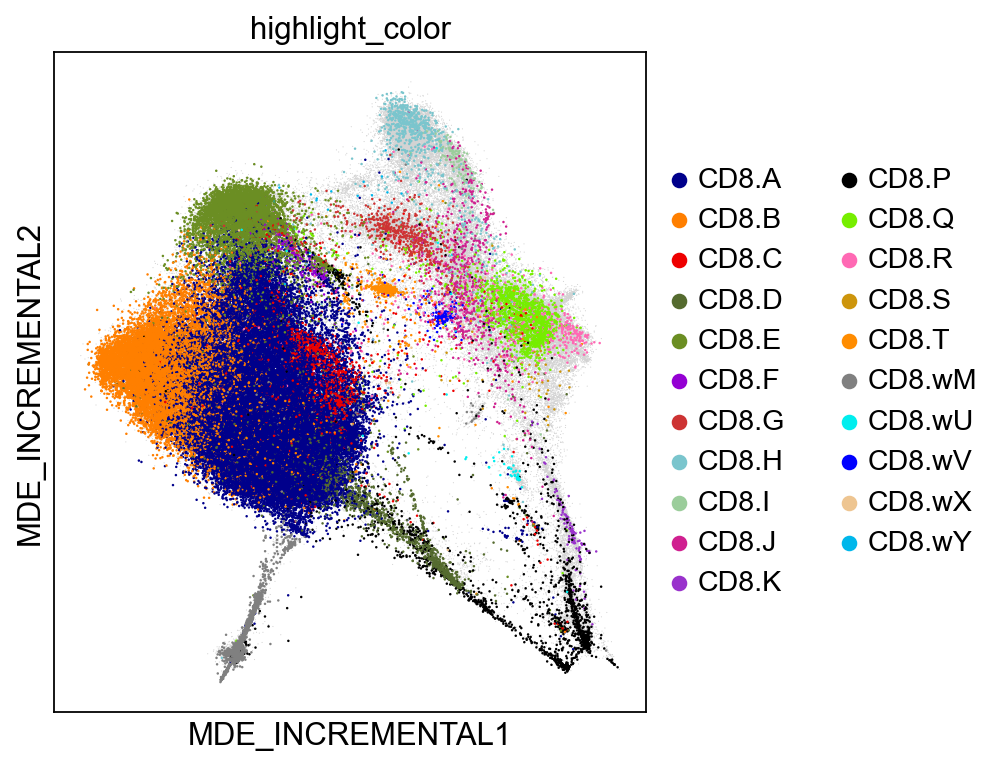

Plot saved: Extended_Data_Fig_1e.pdf


In [46]:
# Extended Data Fig. 1e — baseline organ composition
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# Gray background for non-highlighted cells
default_color = '#BAB0AC'

# ──────────────────────────────────────────────────────────────
# 1. Create mask for your new condition
# ──────────────────────────────────────────────────────────────
empty_detailed = (
    rna.obs['condition_detailed'].isna() |
    (rna.obs['condition_detailed'].astype(str).str.strip() == '')
)

highlight_mask = (
    (rna.obs['condition_detailed_simplified'].str.lower() == 'baseline') &
    empty_detailed
)

# ──────────────────────────────────────────────────────────────
# 2. Exactly like your original code: use real annotation or None
# ──────────────────────────────────────────────────────────────
rna.obs['highlight_color'] = np.where(
    highlight_mask,
    rna.obs['cluster_annotation'],   # colored by cell type
    None                            # will become gray via na_color
)

# ──────────────────────────────────────────────────────────────
# 3. Same dot size logic as your original
#    but we make highlighted ones just a tiny bit bigger for visibility
# ──────────────────────────────────────────────────────────────
sizes = np.where(rna.obs['highlight_color'].notnull(), 5, 1)
# (80 and 40 give the same visual emphasis as your original "1 vs 1" but actually visible)

# ──────────────────────────────────────────────────────────────
# 4. Plot — 100% identical style to your working version
# ──────────────────────────────────────────────────────────────
plt.figure(figsize=(6.5, 5))
ax = plt.gca()

sc.pl.embedding(
    rna,
    basis="MDE_INCREMENTAL",
    color="highlight_color",
    palette=custom_colors,
    na_in_legend=False,           # no "NaN" in legend (same as before)
    legend_loc="right margin",
    ax=ax,
    size=sizes,                   # variable size (highlighted = bigger)
    show=False,
)

plt.tight_layout()
plt.savefig("Extended_Data_Fig_1e.pdf", bbox_inches="tight")
plt.show()
plt.close()

print("Plot saved: Extended_Data_Fig_1e.pdf")


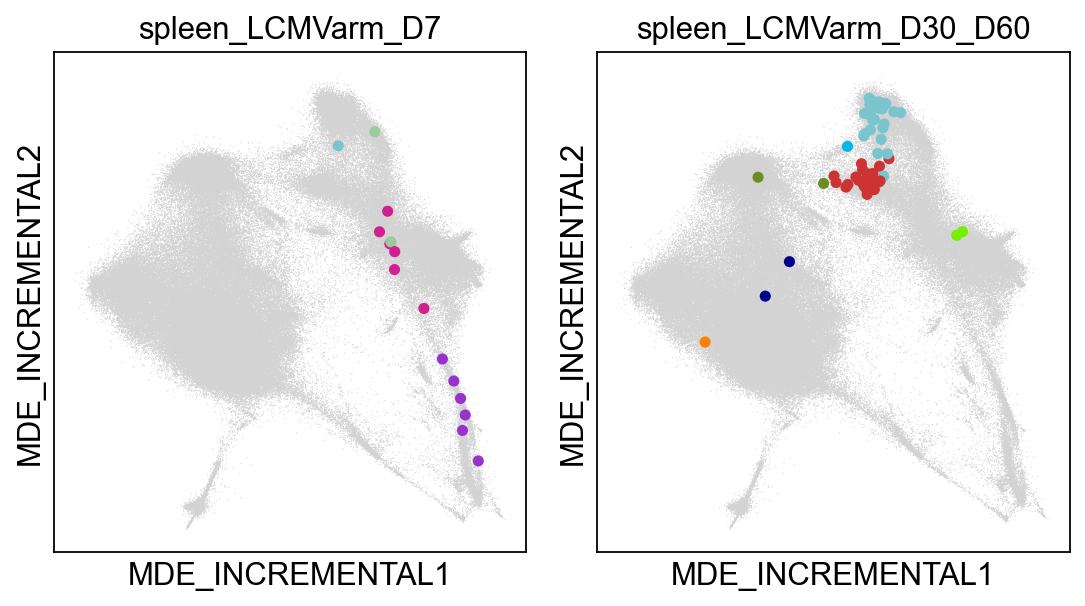

Combined plot saved: Extended_Data_Fig_1h.pdf


In [47]:
## Extended Data Fig. 1h — spleen LCMV Armstrong P14 on MDE
# Conditions to highlight (D30 and D60 merged)
conditions = ['spleen_LCMVarm_D7', 'spleen_LCMVarm_D30_D60']
# Gray background for non-highlighted cells
default_color = '#BAB0AC' # Gray for cells not meeting the condition
# Two panels: D7 and merged D30/D60
fig, axes = plt.subplots(1, 2, figsize=(7, 4))  # 2 subplots horizontally, adjusted size

# Iterate over conditions and corresponding axes
for idx, (condition, ax) in enumerate(zip(conditions, axes)):
    # Create a new column for coloring based on conditions
    if condition == 'spleen_LCMVarm_D30_D60':
        # Merged D30 + D60 condition
        rna.obs['highlight_color'] = np.where(
            (rna.obs['condition_detailed_organ'].isin(['spleen_LCMVarm_D30', 'spleen_LCMVarm_D60'])) & 
            (rna.obs['Ag_spe_v2'].str.lower() == 'p14'),
            rna.obs['cluster_annotation'],   # Use cluster_annotation for highlighted cells
            None                            # None for cells that don't meet the condition
        )
        plot_title = 'spleen_LCMVarm_D30_D60'
    else:
        # Original D7 condition
        rna.obs['highlight_color'] = np.where(
            (rna.obs['condition_detailed_organ'] == condition) & 
            (rna.obs['Ag_spe_v2'].str.lower() == 'p14'),
            rna.obs['cluster_annotation'],   # Use cluster_annotation for highlighted cells
            None                            # None for cells that don't meet the condition
        )
        plot_title = condition

    # Set dot sizes: larger for highlighted cells
    sizes = np.where(rna.obs['highlight_color'].notnull(), 100, 1)

    # Plot MDE
    sc.pl.embedding(
        rna,
        basis="MDE_INCREMENTAL",
        color="highlight_color",
        palette=custom_colors,
        legend_loc=None,      # No legend
        ax=ax,
        size=sizes,
        show=False,
        title=plot_title      # Add condition as subplot title
    )

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show the combined plot
plt.savefig("Extended_Data_Fig_1h.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Combined plot saved: Extended_Data_Fig_1h.pdf")


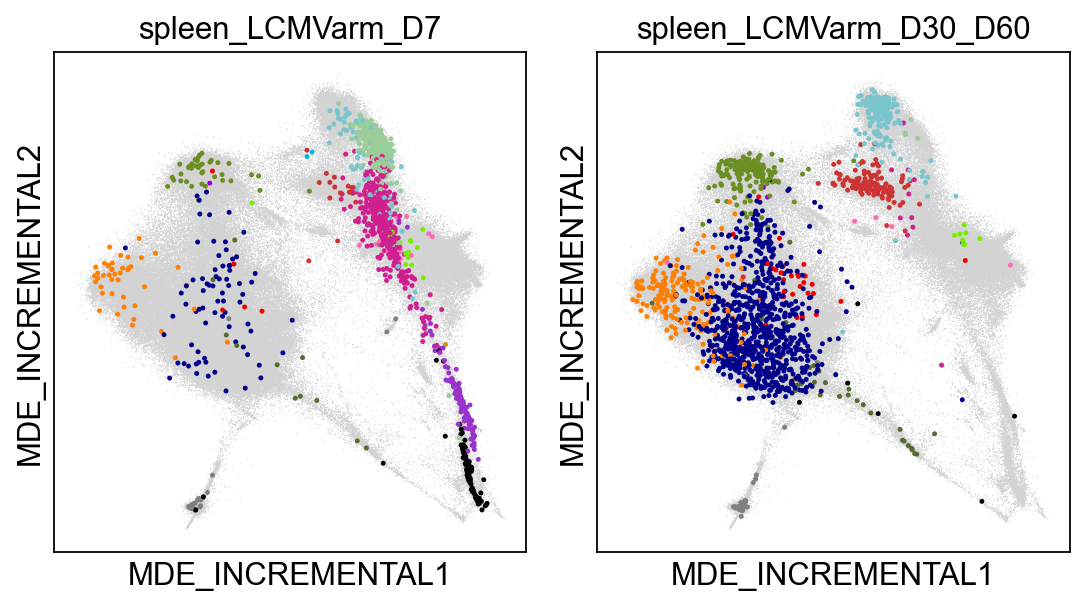

Combined plot saved: Extended_Data_Fig_1h_v2.pdf


In [48]:
# Extended Data Fig. 1h — spleen LCMV Armstrong Endogenous on MDE
# Conditions to highlight (D30 and D60 merged)
conditions = ['spleen_LCMVarm_D7', 'spleen_LCMVarm_D30_D60']
# Gray background for non-highlighted cells
default_color = '#BAB0AC' # Gray for cells not meeting the condition
# Two panels: D7 and merged D30/D60
fig, axes = plt.subplots(1, 2, figsize=(7, 4))  # 2 subplots horizontally, adjusted size

# Iterate over conditions and corresponding axes
for idx, (condition, ax) in enumerate(zip(conditions, axes)):
    # Create a new column for coloring based on conditions
    if condition == 'spleen_LCMVarm_D30_D60':
        # Merged D30 + D60 condition
        rna.obs['highlight_color'] = np.where(
            (rna.obs['condition_detailed_organ'].isin(['spleen_LCMVarm_D30', 'spleen_LCMVarm_D60'])) & 
            (rna.obs['Ag_spe_v2'].str.lower() == 'endogenous'),
            rna.obs['cluster_annotation'],   # Use cluster_annotation for highlighted cells
            None                            # None for cells that don't meet the condition
        )
        plot_title = 'spleen_LCMVarm_D30_D60'
    else:
        # Original D7 condition
        rna.obs['highlight_color'] = np.where(
            (rna.obs['condition_detailed_organ'] == condition) & 
            (rna.obs['Ag_spe_v2'].str.lower() == 'endogenous'),
            rna.obs['cluster_annotation'],   # Use cluster_annotation for highlighted cells
            None                            # None for cells that don't meet the condition
        )
        plot_title = condition

    # Set dot sizes: larger for highlighted cells
    sizes = np.where(rna.obs['highlight_color'].notnull(), 20, 1)

    # Plot MDE
    sc.pl.embedding(
        rna,
        basis="MDE_INCREMENTAL",
        color="highlight_color",
        palette=custom_colors,
        legend_loc=None,      # No legend
        ax=ax,
        size=sizes,
        show=False,
        title=plot_title      # Add condition as subplot title
    )

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show the combined plot
plt.savefig("Extended_Data_Fig_1h_v2.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Combined plot saved: Extended_Data_Fig_1h_v2.pdf")


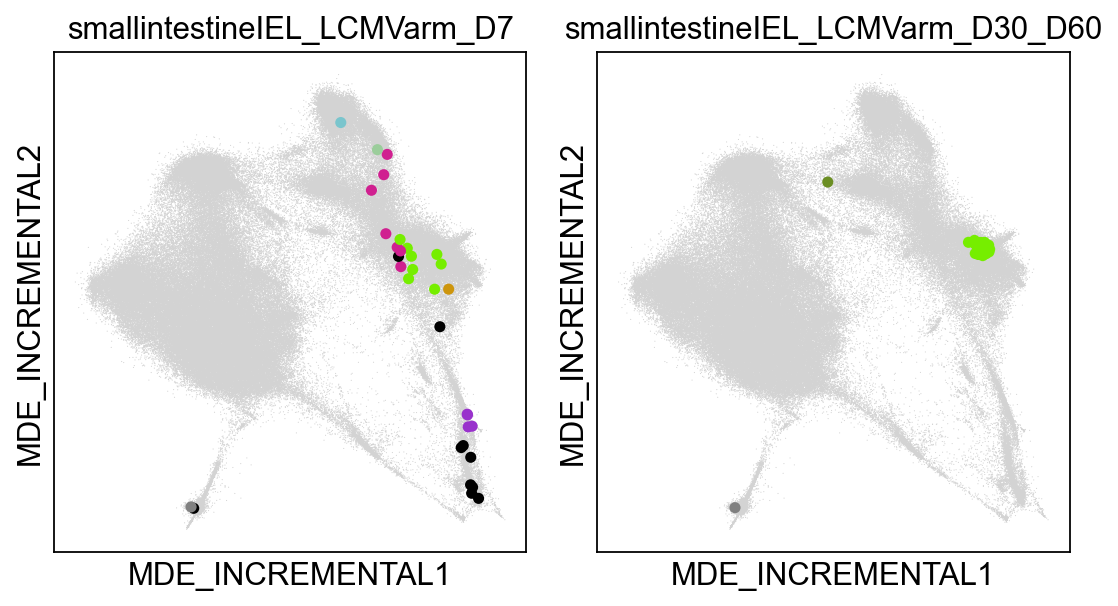

Combined plot saved: Extended_Data_Fig_1h_v3.pdf


In [49]:
# Extended Data Fig. 1h — small intestine LCMV Armstrong P14 on MDE
# Conditions to highlight (D30 and D60 merged)
conditions = ['smallintestineIEL_LCMVarm_D7', 'smallintestineIEL_LCMVarm_D30_D60']
# Gray background for non-highlighted cells
default_color = '#BAB0AC' # Gray for cells not meeting the condition
# Two panels: D7 and merged D30/D60
fig, axes = plt.subplots(1, 2, figsize=(7, 4))  # 2 subplots horizontally, adjusted size

# Iterate over conditions and corresponding axes
for idx, (condition, ax) in enumerate(zip(conditions, axes)):
    # Create a new column for coloring based on conditions
    if condition == 'smallintestineIEL_LCMVarm_D30_D60':
        # Merged D30 + D60 condition
        rna.obs['highlight_color'] = np.where(
            (rna.obs['condition_detailed_organ'].isin(['smallintestineIEL_LCMVarm_D30', 'smallintestineIEL_LCMVarm_D60'])) & 
            (rna.obs['Ag_spe_v2'].str.lower() == 'p14'),
            rna.obs['cluster_annotation'],   # Use cluster_annotation for highlighted cells
            None                            # None for cells that don't meet the condition
        )
        plot_title = 'smallintestineIEL_LCMVarm_D30_D60'
    else:
        # Original D7 condition
        rna.obs['highlight_color'] = np.where(
            (rna.obs['condition_detailed_organ'] == condition) & 
            (rna.obs['Ag_spe_v2'].str.lower() == 'p14'),
            rna.obs['cluster_annotation'],   # Use cluster_annotation for highlighted cells
            None                            # None for cells that don't meet the condition
        )
        plot_title = condition

    # Set dot sizes: larger for highlighted cells
    sizes = np.where(rna.obs['highlight_color'].notnull(), 100, 1)

    # Plot MDE
    sc.pl.embedding(
        rna,
        basis="MDE_INCREMENTAL",
        color="highlight_color",
        palette=custom_colors,
        legend_loc=None,      # No legend
        ax=ax,
        size=sizes,
        show=False,
        title=plot_title      # Add condition as subplot title
    )

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show the combined plot
plt.savefig("Extended_Data_Fig_1h_v3.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Combined plot saved: Extended_Data_Fig_1h_v3.pdf")


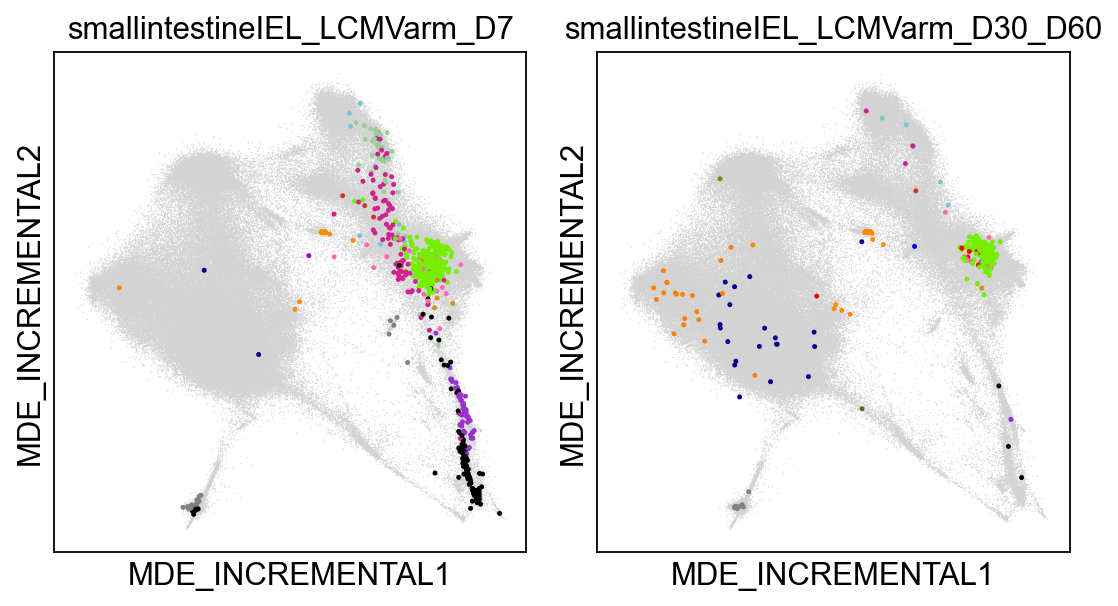

Combined plot saved: Extended_Data_Fig_1h_v4.pdf


In [50]:
# Extended Data Fig. 1h — small intestine LCMV Armstrong Endogenous on MDE
# Conditions to highlight (D30 and D60 merged)
conditions = ['smallintestineIEL_LCMVarm_D7', 'smallintestineIEL_LCMVarm_D30_D60']
# Gray background for non-highlighted cells
default_color = '#BAB0AC' # Gray for cells not meeting the condition
# Two panels: D7 and merged D30/D60
fig, axes = plt.subplots(1, 2, figsize=(7, 4))  # 2 subplots horizontally, adjusted size

# Iterate over conditions and corresponding axes
for idx, (condition, ax) in enumerate(zip(conditions, axes)):
    # Create a new column for coloring based on conditions
    if condition == 'smallintestineIEL_LCMVarm_D30_D60':
        # Merged D30 + D60 condition
        rna.obs['highlight_color'] = np.where(
            (rna.obs['condition_detailed_organ'].isin(['smallintestineIEL_LCMVarm_D30', 'smallintestineIEL_LCMVarm_D60'])) & 
            (rna.obs['Ag_spe_v2'].str.lower() == 'endogenous'),
            rna.obs['cluster_annotation'],   # Use cluster_annotation for highlighted cells
            None                            # None for cells that don't meet the condition
        )
        plot_title = 'smallintestineIEL_LCMVarm_D30_D60'
    else:
        # Original D7 condition
        rna.obs['highlight_color'] = np.where(
            (rna.obs['condition_detailed_organ'] == condition) & 
            (rna.obs['Ag_spe_v2'].str.lower() == 'endogenous'),
            rna.obs['cluster_annotation'],   # Use cluster_annotation for highlighted cells
            None                            # None for cells that don't meet the condition
        )
        plot_title = condition

    # Set dot sizes: larger for highlighted cells
    sizes = np.where(rna.obs['highlight_color'].notnull(), 20, 1)

    # Plot MDE
    sc.pl.embedding(
        rna,
        basis="MDE_INCREMENTAL",
        color="highlight_color",
        palette=custom_colors,
        legend_loc=None,      # No legend
        ax=ax,
        size=sizes,
        show=False,
        title=plot_title      # Add condition as subplot title
    )

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show the combined plot
plt.savefig("Extended_Data_Fig_1h_v4.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Combined plot saved: Extended_Data_Fig_1h_v4.pdf")


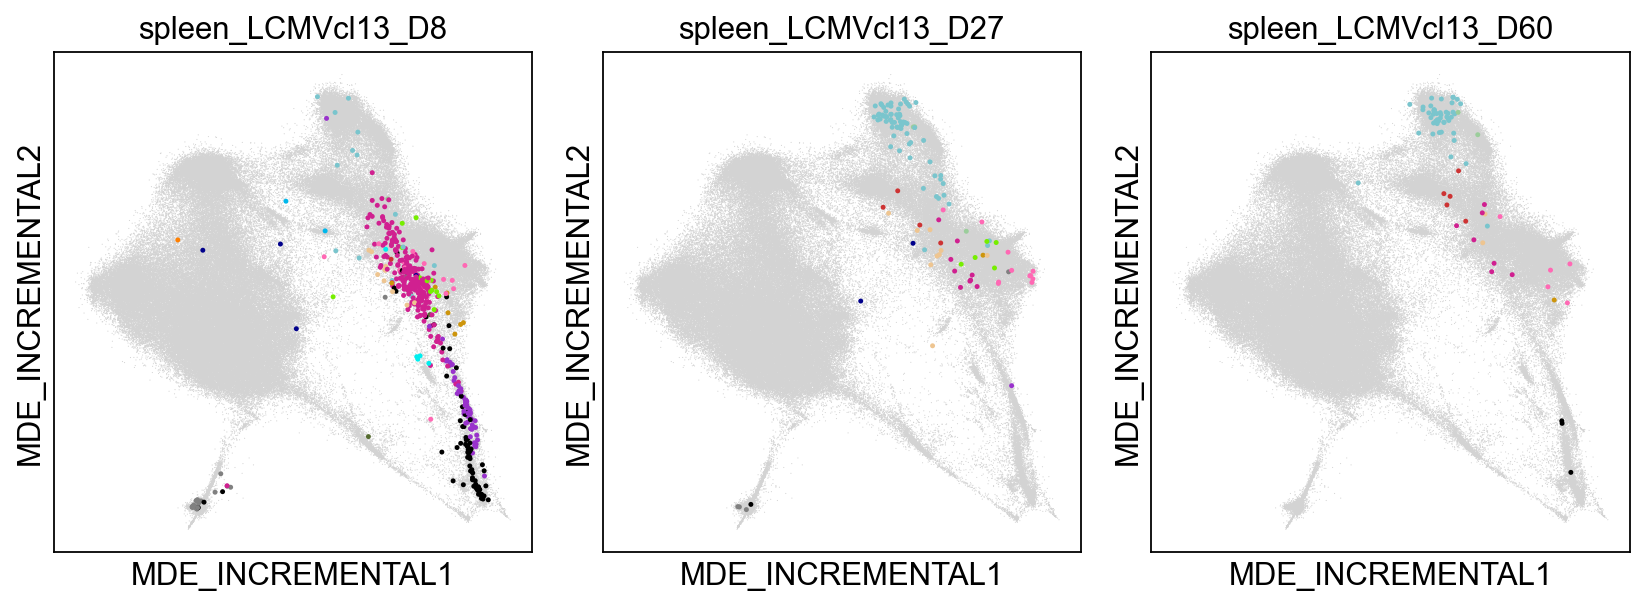

Combined plot saved: Extended_Data_Fig_1h_v5.pdf


In [51]:
# Extended Data Fig. 1h — spleen LCMV Clone 13 P14 on MDE
# Conditions to highlight
conditions = ['spleen_LCMVcl13_D8', 'spleen_LCMVcl13_D27', 'spleen_LCMVcl13_D60']

# Gray background for non-highlighted cells
default_color = '#BAB0AC'  # Gray for cells not meeting the condition

# Three-panel layout
fig, axes = plt.subplots(1, 3, figsize=(10.5, 4))  # 3 subplots horizontally, adjusted size

# Iterate over conditions and corresponding axes
for idx, (condition, ax) in enumerate(zip(conditions, axes)):
    # Create a new column for coloring based on conditions
    rna.obs['highlight_color'] = np.where(
        (rna.obs['condition_detailed_organ'] == condition) & (rna.obs['Ag_spe_v2'].str.lower() == 'p14'),
        rna.obs['cluster_annotation'],  # Use cluster_annotation for highlighted cells
        None  # None for cells that don't meet the condition
    )
    
    # Set dot sizes: larger for highlighted cells
    sizes = np.where(rna.obs['highlight_color'].notnull(), 20, 1)
    
    # Plot MDE
    sc.pl.embedding(
        rna,
        basis="MDE_INCREMENTAL",
        color="highlight_color",
        palette=custom_colors,
        legend_loc=None,  # No legend
        ax=ax,
        size=sizes,
        show=False,
        title=condition  # Add condition as subplot title
    )

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show the combined plot
plt.savefig("Extended_Data_Fig_1h_v5.pdf", bbox_inches="tight")
plt.show()
plt.close()

print("Combined plot saved: Extended_Data_Fig_1h_v5.pdf")


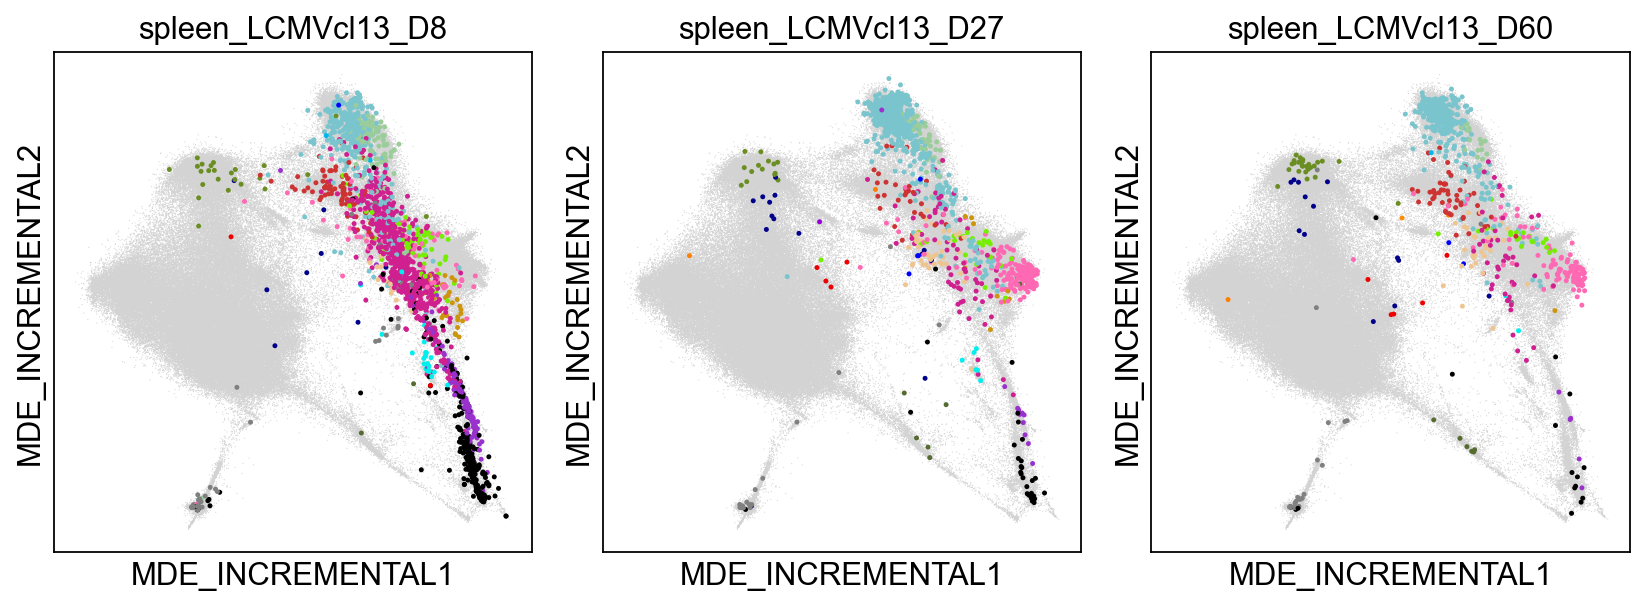

Combined plot saved: Extended_Data_Fig_1h_v6.pdf


In [52]:
# Extended Data Fig. 1h — spleen LCMV Clone 13 Endogenous on MDE
# Work on a view/copy of the RNA modality
rna = mdata.mod['RNA']

# Conditions to highlight
conditions = ['spleen_LCMVcl13_D8', 'spleen_LCMVcl13_D27', 'spleen_LCMVcl13_D60']

# Gray background for non-highlighted cells
default_color = '#BAB0AC'  # Gray for cells not meeting the condition

# Three-panel layout
fig, axes = plt.subplots(1, 3, figsize=(10.5, 4))  # 3 subplots horizontally, adjusted size

# Iterate over conditions and corresponding axes
for idx, (condition, ax) in enumerate(zip(conditions, axes)):
    # Create a new column for coloring based on conditions
    rna.obs['highlight_color'] = np.where(
        (rna.obs['condition_detailed_organ'] == condition) & (rna.obs['Ag_spe_v2'].str.lower() == 'endogenous'),
        rna.obs['cluster_annotation'],  # Use cluster_annotation for highlighted cells
        None  # None for cells that don't meet the condition
    )
    
    # Set dot sizes: larger for highlighted cells
    sizes = np.where(rna.obs['highlight_color'].notnull(), 20, 1)
    
    # Plot MDE
    sc.pl.embedding(
        rna,
        basis="MDE_INCREMENTAL",
        color="highlight_color",
        palette=custom_colors,
        legend_loc=None,  # No legend
        ax=ax,
        size=sizes,
        show=False,
        title=condition  # Add condition as subplot title
    )

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show the combined plot
plt.savefig("Extended_Data_Fig_1h_v6.pdf", bbox_inches="tight")
plt.show()
plt.close()

print("Combined plot saved: Extended_Data_Fig_1h_v6.pdf")


In [53]:
# Extended Data Fig. 1i — Naive-associated signature enrichment (module scores)
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# ── Assuming your MuData object is already loaded ──
adata = mdata['RNA']

# Your signature files
signatures = {
    'CD5hi': 'data/CD5hi_Fulton.txt',   # From Fulton et al., Nat Immunol 2014
    'CD5lo': 'data/CD5lo_Fulton.txt',    # From Fulton et al., Nat Immunol 2014
}

# ── Define CD8 subset ───────────────────────────────────────────────────
cluster_key = 'cluster_annotation'
cd8_clusters = ['CD8.A', 'CD8.B']

mask_cd8 = adata.obs[cluster_key].isin(cd8_clusters)

if mask_cd8.sum() == 0:
    raise ValueError("No cells found in the specified CD8 clusters!")

print(f"Computing signatures using {mask_cd8.sum()} cells (CD8.A + CD8.B)")

# Initialize score columns with NaN
for sig_name in signatures:
    if sig_name not in adata.obs.columns:
        adata.obs[sig_name] = np.nan

# ── Compute signature scores ONLY on CD8 cells ──────────────────────────
for sig_name, sig_path in signatures.items():
    with open(sig_path, 'r') as f:
        gene_list = [line.strip() for line in f if line.strip()]
    
    gene_list = [g for g in gene_list if g in adata.var_names]
    
    if len(gene_list) == 0:
        print(f"No genes found for signature '{sig_name}'. Skipping.")
        continue
    
    adata_cd8 = adata[mask_cd8]
    
    sc.tl.score_genes(
        adata_cd8,
        gene_list,
        score_name=sig_name,
        random_state=42,
        copy=False
    )
    
    adata.obs.loc[mask_cd8, sig_name] = adata_cd8.obs[sig_name].values
    
    print(f"Computed score for '{sig_name}' using {len(gene_list)} genes.")


Computing signatures using 90729 cells (CD8.A + CD8.B)
Computed score for 'CD5hi' using 108 genes.
Computed score for 'CD5lo' using 101 genes.


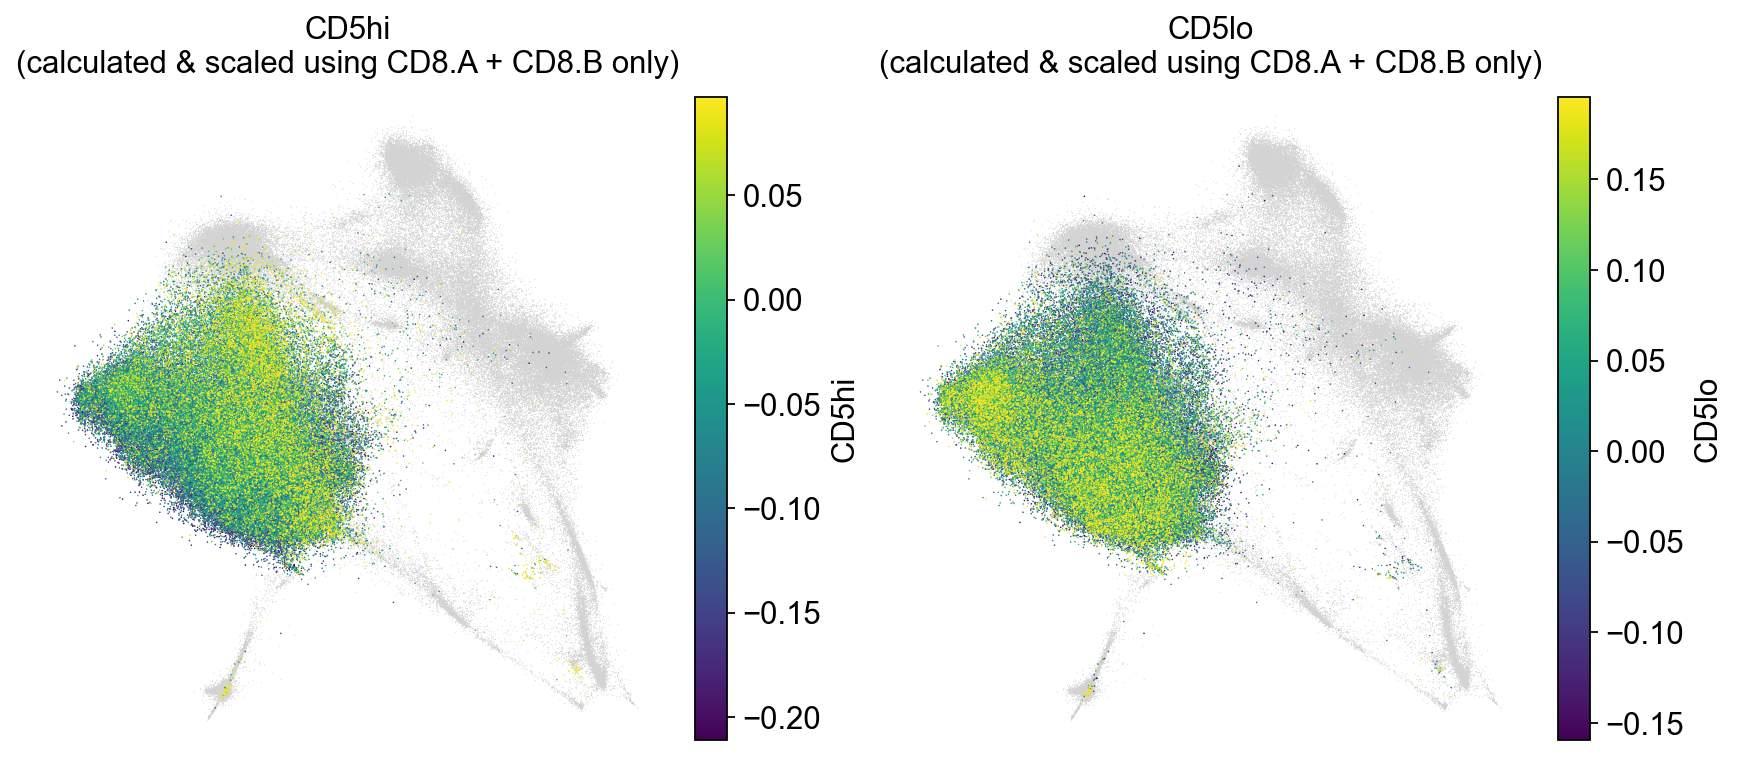

In [54]:
# Extended Data Fig. 1i — Naive-associated signature enrichment (module scores)
# ── MDE colored by naive-associated signature scores ──
basis = 'MDE_INCREMENTAL'
if basis not in adata.obsm:
    raise ValueError(f"Embedding '{basis}' not found in adata.obsm.")

# ── Point sizes for background vs highlighted cells ──
background_size = 0.1      # ← change this for gray (non-CD8) cells
cd8_size = 0.5             # ← change this for colored (CD8) cells
# higher value = bigger dots

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs = axs.flatten()

for i, sig_name in enumerate(signatures.keys()):
    if sig_name not in adata.obs.columns:
        print(f"Warning: '{sig_name}' not found in adata.obs – skipping plot")
        continue
    
    # Color limits based only on CD8 cells
    scores_cd8 = adata.obs[sig_name][mask_cd8]
    if len(scores_cd8) < 5:
        vmin, vmax = None, None
    else:
        vmin = np.percentile(scores_cd8, 5)
        vmax = np.percentile(scores_cd8, 95)
    
    # Create colors array (object dtype)
    colors = np.full(len(adata), '#d3d3d3', dtype=object)  # light gray by default
    
    if vmin is not None and vmax is not None:
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.cm.viridis
        rgba_colors = cmap(norm(scores_cd8.values))
        cd8_indices = np.where(mask_cd8)[0]
        colors[cd8_indices] = [tuple(rgba) for rgba in rgba_colors]

    # ── Plot base layer: background gray points ─────────────────────────
    sc.pl.embedding(
        adata,
        basis=basis,
        color=None,
        ax=axs[i],
        show=False,
        frameon=False,
        title=f"{sig_name}\n(calculated & scaled using CD8.A + CD8.B only)",
    )
    
    emb = adata.obsm[basis]
    
    # Background (gray) points
    bg_mask = ~mask_cd8
    axs[i].scatter(
        emb[bg_mask, 0],
        emb[bg_mask, 1],
        c='#d3d3d3',
        s=background_size,
        rasterized=True,
        edgecolor='none',
        linewidth=0,
        zorder=1
    )
    
    # ── Overlay CD8 cells, sorted by score (highest on top) ─────────────
    if vmin is not None and vmax is not None:
        # Sort CD8 cells by score (highest last → plotted on top)
        sort_idx = np.argsort(scores_cd8.values)
        cd8_sorted_indices = cd8_indices[sort_idx]
        
        axs[i].scatter(
            emb[cd8_sorted_indices, 0],
            emb[cd8_sorted_indices, 1],
            c=colors[cd8_sorted_indices],
            s=cd8_size,
            rasterized=True,
            edgecolor='none',
            linewidth=0,
            zorder=2
        )
        
        # Colorbar
        sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        plt.colorbar(sm, ax=axs[i], fraction=0.046, pad=0.04, label=sig_name)

plt.tight_layout()
plt.show()

fig.savefig('Extended_Data_Fig_1i.pdf', dpi=350, bbox_inches='tight')


# Extended Data Fig. 2

In [57]:
# Extended Data Fig. 2h-i — Heatmaps of expression for genes driving top factors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load matrices (adjust paths as needed)
F_df = pd.read_csv("data/gene_factor_matrix.txt", sep="\t", index_col=0)
L_df = pd.read_csv("data/cell_factor_matrix.txt.gz", sep="\t", index_col=0, compression="gzip")

# Convert to NumPy arrays for positional matrix multiplication
F_np = F_df.to_numpy()
L_np = L_df.to_numpy()

# Preserve column names for factor labels
factor_names = L_df.columns  # Use F1–F200 from L_df
gene_names = F_df.index

# Verify shapes
print("F_np shape:", F_np.shape)  # Expected: (19805, 200)
print("L_np shape:", L_np.shape)  # Expected: (682953, 200)

# Assuming mdata is your MuData object
# Replace 'mdata' with your actual MuData variable
mdata_obs = mdata['RNA'].obs

# Check if cellID matches IGT_cellID
if 'cellID' in mdata_obs.columns:
    print("Using 'cellID' from mdata_obs")
    cell_id_col = 'cellID'
else:
    print("Using 'IGT_cellID' from mdata_obs")
    cell_id_col = 'IGT_cellID'

# Get unique clusters
unique_clusters = mdata_obs['cluster_annotation'].unique()
print(f"Found {len(unique_clusters)} clusters in cluster_annotation")

# Sort clusters alphabetically
unique_clusters = sorted(unique_clusters)
print("Sorted clusters:", unique_clusters)

# Function to compute log2FC for a cluster vs others
def compute_factor_log2fc(L_np, group1, group2, factor_names):
    group1 = [g for g in group1 if g in L_df.index]
    group2 = [g for g in group2 if g in L_df.index]
    if not group1 or not group2:
        return None
    group1_idx = [L_df.index.get_loc(g) for g in group1]
    group2_idx = [L_df.index.get_loc(g) for g in group2]
    loadings_group1 = L_np[group1_idx].mean(axis=0)
    loadings_group2 = L_np[group2_idx].mean(axis=0)
    fc_loadings = loadings_group1 - loadings_group2
    return pd.DataFrame({
        'SYMBOL': factor_names,
        'log2FC': fc_loadings / np.log(2)
    })

# Identify top factor for CD8.I, CD8.J, CD8.K
target_clusters = ['CD8.I', 'CD8.J', 'CD8.K']
top_factors = []
n_top = 1  # Top 1 factor per cluster

for cluster in target_clusters:
    group1 = mdata_obs[
        mdata_obs['cluster_annotation'] == cluster
    ][cell_id_col].tolist()
    group2 = mdata_obs[
        mdata_obs['cluster_annotation'] != cluster
    ][cell_id_col].tolist()
    
    if group1 and group2:
        log2fc_df = compute_factor_log2fc(L_np, group1, group2, factor_names)
        if log2fc_df is not None:
            top = log2fc_df.sort_values(by='log2FC', ascending=False).head(n_top)
            top_factors.extend(top['SYMBOL'].tolist())
            print(f"Top factor for {cluster}: {top['SYMBOL'].tolist()}")
    else:
        print(f"Skipping {cluster}: group1 has {len(group1)} cells, group2 has {len(group2)} cells")

# Remove duplicates while preserving order
top_factors = list(dict.fromkeys(top_factors))
print(f"Selected factors: {top_factors}")

# Compute mean loadings for each cluster and factor
cluster_loadings = []
for cluster in unique_clusters:
    group = mdata_obs[
        mdata_obs['cluster_annotation'] == cluster
    ][cell_id_col].tolist()
    
    if group:
        group_idx = [L_df.index.get_loc(g) for g in group]
        loadings = L_np[group_idx].mean(axis=0)
        for i, factor in enumerate(factor_names):
            if factor in top_factors:
                cluster_loadings.append({
                    'cluster': cluster,
                    'factor': factor,
                    'mean_loading': loadings[i],
                    'num_cells': len(group)
                })
    else:
        print(f"Skipping {cluster}: no valid cells")

# Convert to DataFrame
loadings_df = pd.DataFrame(cluster_loadings)

# Pivot data for plotting
pivot_df = loadings_df.pivot(index='cluster', columns='factor', values='mean_loading').fillna(0)
# Ensure clusters are in the desired order
pivot_df = pivot_df.reindex(unique_clusters)


F_np shape: (19805, 200)
L_np shape: (682953, 200)
Using 'IGT_cellID' from mdata_obs
Found 21 clusters in cluster_annotation
Sorted clusters: ['CD8.A', 'CD8.B', 'CD8.C', 'CD8.D', 'CD8.E', 'CD8.F', 'CD8.G', 'CD8.H', 'CD8.I', 'CD8.J', 'CD8.K', 'CD8.P', 'CD8.Q', 'CD8.R', 'CD8.S', 'CD8.T', 'CD8.wM', 'CD8.wU', 'CD8.wV', 'CD8.wX', 'CD8.wY']
Top factor for CD8.I: ['F10']
Top factor for CD8.J: ['F25']
Top factor for CD8.K: ['F25']
Selected factors: ['F10', 'F25']


Top factor for CD8.I: ['F10']
Top factor for CD8.J: ['F25']
Top factor for CD8.K: ['F25']
Selected factors: ['F10', 'F25']
Top 10 genes for F10: ['Ccl5', 'Gzma', 'Lgals1', 'Nkg7', 'Ly6c2', 'S100a6', 'Klf2', 'Cd8b1', 'S100a10', 'Klrg1']
Top 10 genes for F25: ['Lgals1', 'S100a6', 'Vim', 'Crip1', 'S100a10', 'Malat1', 'Anxa2', 'S100a11', 'Ly6a', 'Sh3bgrl3']


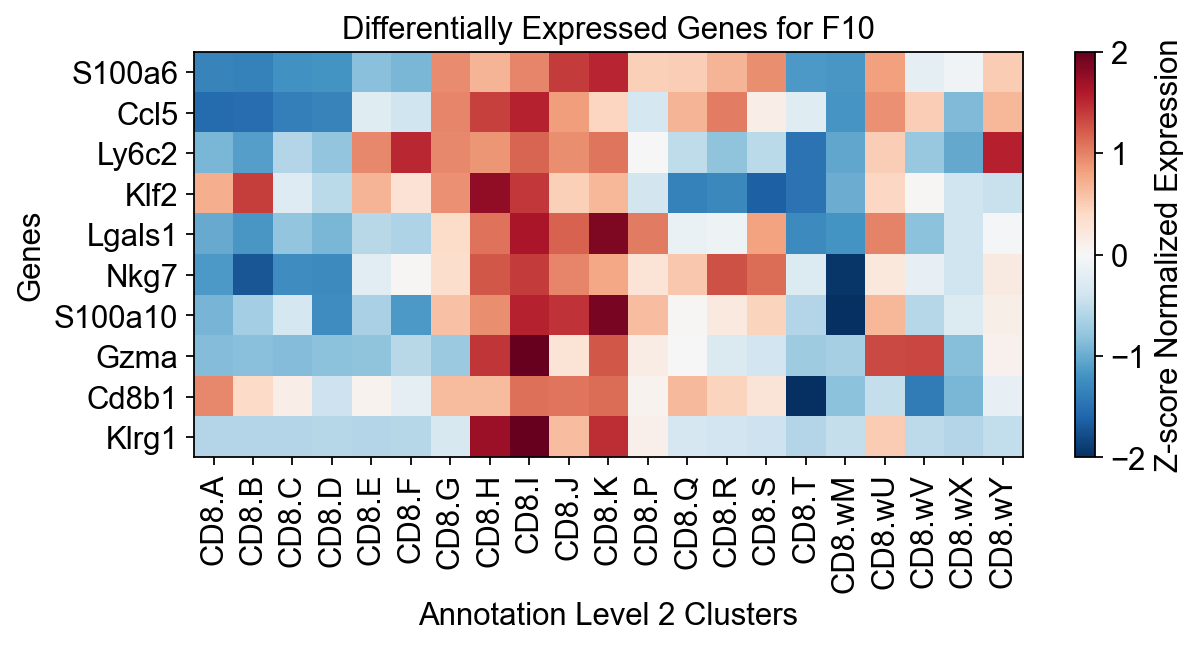

Plot saved: Extended_Data_Fig_2h-i_F10.pdf


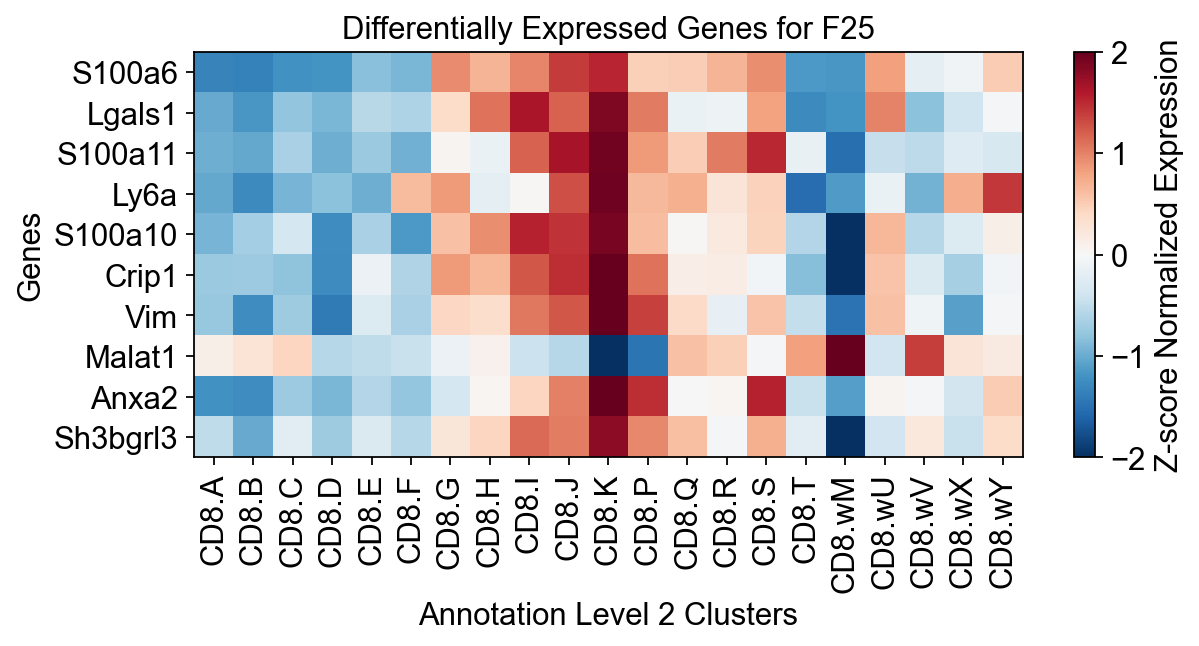

Plot saved: Extended_Data_Fig_2h-i_F25.pdf

Z-score normalized gene expression for all genes:
cluster      CD8.A     CD8.B     CD8.C     CD8.D     CD8.E     CD8.F  \
gene                                                                   
Anxa2    -1.217056 -1.249657 -0.721801 -0.907719 -0.588852 -0.770548   
Ccl5     -1.533058 -1.516226 -1.366186 -1.337671 -0.240661 -0.399883   
Cd8b1     0.958007  0.377022  0.138193 -0.413636  0.066851 -0.177897   
Crip1    -0.744824 -0.732095 -0.803500 -1.265592 -0.119358 -0.595644   
Gzma     -0.863114 -0.835592 -0.860313 -0.826440 -0.799438 -0.558223   
Klf2      0.720978  1.376216 -0.263267 -0.543682  0.682021  0.281269   
Klrg1    -0.591703 -0.591969 -0.591839 -0.574226 -0.578988 -0.570886   
Lgals1   -1.015123 -1.156549 -0.795852 -0.915725 -0.556729 -0.616595   
Ly6a     -1.016944 -1.271923 -0.926845 -0.827538 -0.978999  0.626481   
Ly6c2    -0.912405 -1.099617 -0.588227 -0.787628  0.967816  1.500765   
Malat1    0.122375  0.266050  0.422295 -0.

In [58]:
# Extended Data Fig. 2h-i — Heatmaps of expression for genes driving top factors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scipy.sparse as sparse

# Ensure we use your preferred normalized data
mdata['RNA'].X = mdata['RNA'].layers['scaled']

# Recompute top factors (self-contained block)
def compute_factor_log2fc(L_np, group1, group2, factor_names):
    group1 = [g for g in group1 if g in L_df.index]
    group2 = [g for g in group2 if g in L_df.index]
    if not group1 or not group2:
        return None
    group1_idx = [L_df.index.get_loc(g) for g in group1]
    group2_idx = [L_df.index.get_loc(g) for g in group2]
    loadings_group1 = L_np[group1_idx].mean(axis=0)
    loadings_group2 = L_np[group2_idx].mean(axis=0)
    fc_loadings = loadings_group1 - loadings_group2
    return pd.DataFrame({
        'SYMBOL': factor_names,
        'log2FC': fc_loadings / np.log(2)
    })

# Identify top factor for CD8.I, CD8.J, CD8.K
target_clusters = ['CD8.I', 'CD8.J', 'CD8.K']
top_factors = []
n_top = 1  # Top 1 factor per cluster
for cluster in target_clusters:
    group1 = mdata_obs[
        mdata_obs['cluster_annotation'] == cluster
    ][cell_id_col].tolist()
    group2 = mdata_obs[
        mdata_obs['cluster_annotation'] != cluster
    ][cell_id_col].tolist()
    if group1 and group2:
        log2fc_df = compute_factor_log2fc(L_np, group1, group2, factor_names)
        if log2fc_df is not None:
            top = log2fc_df.sort_values(by='log2FC', ascending=False).head(n_top)
            top_factors.extend(top['SYMBOL'].tolist())
            print(f"Top factor for {cluster}: {top['SYMBOL'].tolist()}")
    else:
        print(f"Skipping {cluster}: group1 has {len(group1)} cells, group2 has {len(group2)} cells")

# Remove duplicates
top_factors = list(dict.fromkeys(top_factors))
print(f"Selected factors: {top_factors}")

# Extract top genes for each selected factor
n_top_genes = 10  # Number of top genes per factor
factor_genes = {factor: [] for factor in top_factors}  # Store genes per factor
for factor in top_factors:
    factor_idx = list(factor_names).index(factor)
    gene_loadings = pd.Series(F_np[:, factor_idx], index=gene_names)
    top = gene_loadings.abs().sort_values(ascending=False).head(n_top_genes)
    factor_genes[factor] = top.index.tolist()
    print(f"Top {n_top_genes} genes for {factor}: {top.index.tolist()}")

# Compute mean expression across all clusters that will be plotted (unique_clusters must be defined)
# Assuming unique_clusters is already defined earlier in your notebook as all clusters you want to show
# If not defined, fallback to all CD8 clusters
if 'unique_clusters' not in globals():
    unique_clusters = sorted([c for c in mdata_obs['cluster_annotation'].unique() if c.startswith('CD8_')],
                             key=lambda x: int(x.split('_cl')[-1]) if '_cl' in x else 0)

cluster_mask = mdata_obs['cluster_annotation'].isin(unique_clusters)
subset_obs = mdata_obs[cluster_mask]
subset_X = mdata['RNA'].X[cluster_mask]
cluster_labels = subset_obs['cluster_annotation'].values

unique_labels, inverse = np.unique(cluster_labels, return_inverse=True)
n_genes = subset_X.shape[1]

mean_expr_matrix = np.empty((len(unique_labels), n_genes))
for i, label in enumerate(unique_labels):
    mask_i = (inverse == i)
    if sparse.issparse(subset_X):
        mean_expr_matrix[i] = np.ravel(subset_X[mask_i].mean(axis=0))
    else:
        mean_expr_matrix[i] = subset_X[mask_i].mean(axis=0)

mean_expr_pivot = pd.DataFrame(
    mean_expr_matrix,
    index=unique_labels,
    columns=mdata['RNA'].var_names
).T  # genes x clusters
mean_expr_pivot = mean_expr_pivot[unique_clusters]  # Order correctly

# === Build expression DataFrame using expression ===
gene_expression = []
for cluster in unique_clusters:
    for factor in top_factors:
        for gene in factor_genes[factor]:
            if gene in mean_expr_pivot.index:
                gene_expression.append({
                    'cluster': cluster,
                    'gene': gene,
                    'mean_expr': mean_expr_pivot.loc[gene, cluster],
                    'factor': factor
                })

# Convert to DataFrame
expr_df = pd.DataFrame(gene_expression)

# Use a classic diverging red-blue colormap (negative: blue, zero: white, positive: red)
cmap = 'RdBu_r'  # Built-in matplotlib colormap: red-blue reversed (high=red, low=blue)

# Set z-score range for expression scale
zscore_min = -2.0
zscore_max = 2.0

# Create heatmaps for each factor
for i, factor in enumerate(top_factors):
    # Filter expression data for genes of this factor
    factor_expr_df = expr_df[expr_df['factor'] == factor]
    pivot_df = factor_expr_df.pivot(index='gene', columns='cluster', values='mean_expr').fillna(0)
    pivot_df = pivot_df[unique_clusters]  # Order clusters

    # Z-score normalization: (x - mean) / std
    pivot_df = pivot_df.apply(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else x, axis=1)

    # Order genes by max absolute z-score
    pivot_df = pivot_df.loc[pivot_df.abs().max(axis=1).sort_values(ascending=False).index]

    # Use red-blue colormap for real expression
    cmap = 'RdBu_r'

    # Create heatmap
    fig, ax = plt.subplots(figsize=(8, 4.25))
    # Plot heatmap with fixed z-score range for colormap
    heatmap = ax.imshow(pivot_df.values, cmap=cmap, aspect='auto',
                        vmin=zscore_min, vmax=zscore_max, interpolation='nearest')
    # Reverse y-axis to match DataFrame order (highest z-score at top)
    ax.invert_yaxis()
    # Customize plot
    ax.set_xticks(np.arange(len(unique_clusters)))
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_xticklabels(unique_clusters, rotation=45, ha='right')
    ax.set_yticklabels(pivot_df.index)
    ax.set_xlabel('Annotation Level 2 Clusters')
    ax.set_ylabel('Genes')
    ax.set_title(f'Differentially Expressed Genes for {factor}')
    ax.set_xticklabels([cluster.replace('CD8_', '') for cluster in unique_clusters], rotation=90, ha='center')
    ax.grid(False)
    # Add colorbar
    plt.colorbar(heatmap, label='Z-score Normalized Expression')
    plt.tight_layout()
    # Save as PDF
    plt.savefig(f'Extended_Data_Fig_2h-i_{factor}.pdf', format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    print(f'Plot saved: Extended_Data_Fig_2h-i_{factor}.pdf')

# Print results
print("\nZ-score normalized gene expression for all genes:")
pivot_df = expr_df.groupby(['gene', 'cluster'])['mean_expr'].first().unstack().fillna(0)[unique_clusters]
pivot_df = pivot_df.apply(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else x, axis=1)
print(pivot_df)


# Extended Data Fig. 3

In [61]:
# Extended Data Fig. 3c - Heatmaps of gene-program gene expression (z-scored mean expression)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load matrices (adjust paths as needed)
F_df = pd.read_csv("data/gene_factor_matrix.txt", sep="\t", index_col=0)
L_df = pd.read_csv("data/cell_factor_matrix.txt.gz", sep="\t", index_col=0, compression="gzip")

# Convert to NumPy arrays for positional matrix multiplication
F_np = F_df.to_numpy()
L_np = L_df.to_numpy()

# Preserve column names for factor labels
factor_names = L_df.columns  # Use F1–F200 from L_df
gene_names = F_df.index

# Verify shapes
print("F_np shape:", F_np.shape)  # Expected: (19805, 200)
print("L_np shape:", L_np.shape)  # Expected: (682953, 200)

# Assuming mdata is your MuData object
# Replace 'mdata' with your actual MuData variable
mdata_obs = mdata['RNA'].obs

# Check if cellID matches IGT_cellID
if 'cellID' in mdata_obs.columns:
    print("Using 'cellID' from mdata_obs")
    cell_id_col = 'cellID'
else:
    print("Using 'IGT_cellID' from mdata_obs")
    cell_id_col = 'IGT_cellID'

# Get unique clusters
unique_clusters = mdata_obs['cluster_annotation'].unique()
print(f"Found {len(unique_clusters)} clusters in cluster_annotation")

# Function to compute log2FC for a cluster vs others
def compute_factor_log2fc(L_np, group1, group2, factor_names):
    group1 = [g for g in group1 if g in L_df.index]
    group2 = [g for g in group2 if g in L_df.index]
    if not group1 or not group2:
        return None
    group1_idx = [L_df.index.get_loc(g) for g in group1]
    group2_idx = [L_df.index.get_loc(g) for g in group2]
    loadings_group1 = L_np[group1_idx].mean(axis=0)
    loadings_group2 = L_np[group2_idx].mean(axis=0)
    fc_loadings = loadings_group1 - loadings_group2
    return pd.DataFrame({
        'SYMBOL': factor_names,
        'log2FC': fc_loadings / np.log(2)
    })

# Identify top factor for CD8.E, CD8.F, CD8.G, CD8.H
target_clusters = ['CD8.E', 'CD8.F', 'CD8.G', 'CD8.H']
top_factors = []
n_top = 1  # Top 1 factor per cluster

for cluster in target_clusters:
    group1 = mdata_obs[
        mdata_obs['cluster_annotation'] == cluster
    ][cell_id_col].tolist()
    group2 = mdata_obs[
        mdata_obs['cluster_annotation'] != cluster
    ][cell_id_col].tolist()
    
    if group1 and group2:
        log2fc_df = compute_factor_log2fc(L_np, group1, group2, factor_names)
        if log2fc_df is not None:
            top = log2fc_df.sort_values(by='log2FC', ascending=False).head(n_top)
            top_factors.extend(top['SYMBOL'].tolist())
            print(f"Top factor for {cluster}: {top['SYMBOL'].tolist()}")
    else:
        print(f"Skipping {cluster}: group1 has {len(group1)} cells, group2 has {len(group2)} cells")

# Remove duplicates while preserving order
top_factors = list(dict.fromkeys(top_factors))
print(f"Selected factors: {top_factors}")

# Compute mean loadings for each cluster and factor
cluster_loadings = []
for cluster in unique_clusters:
    group = mdata_obs[
        mdata_obs['cluster_annotation'] == cluster
    ][cell_id_col].tolist()
    
    if group:
        group_idx = [L_df.index.get_loc(g) for g in group]
        loadings = L_np[group_idx].mean(axis=0)
        for i, factor in enumerate(factor_names):
            if factor in top_factors:
                cluster_loadings.append({
                    'cluster': cluster,
                    'factor': factor,
                    'mean_loading': loadings[i],
                    'num_cells': len(group)
                })
    else:
        print(f"Skipping {cluster}: no valid cells")

# Convert to DataFrame
loadings_df = pd.DataFrame(cluster_loadings)

# Pivot data for plotting
pivot_df = loadings_df.pivot(index='cluster', columns='factor', values='mean_loading').fillna(0)
# Ensure clusters are in the desired order
pivot_df = pivot_df.reindex(unique_clusters)


F_np shape: (19805, 200)
L_np shape: (682953, 200)
Using 'IGT_cellID' from mdata_obs
Found 21 clusters in cluster_annotation
Top factor for CD8.E: ['F80']
Top factor for CD8.F: ['F16']
Top factor for CD8.G: ['F80']
Top factor for CD8.H: ['F10']
Selected factors: ['F80', 'F16', 'F10']


Top factor for CD8.E: ['F80']
Top factor for CD8.F: ['F16']
Top factor for CD8.H: ['F10']
Top factor for CD8.G: ['F80']
Selected factors: ['F80', 'F16', 'F10']
Top 10 genes for F80: ['Ccl5', 'Klf2', 'Crip1', 'Itgb1', 'Ly6c2', 'Ahnak', 'S100a6', 'S100a10', 'Lgals1', 'Inpp4b']
Top 10 genes for F16: ['Ifi27l2a', 'Isg15', 'Ly6a', 'Bst2', 'Stat1', 'Irf7', 'Ifit3', 'Ifit1', 'Zbp1', 'Ifi47']
Top 10 genes for F10: ['Ccl5', 'Gzma', 'Lgals1', 'Nkg7', 'Ly6c2', 'S100a6', 'Klf2', 'Cd8b1', 'S100a10', 'Klrg1']


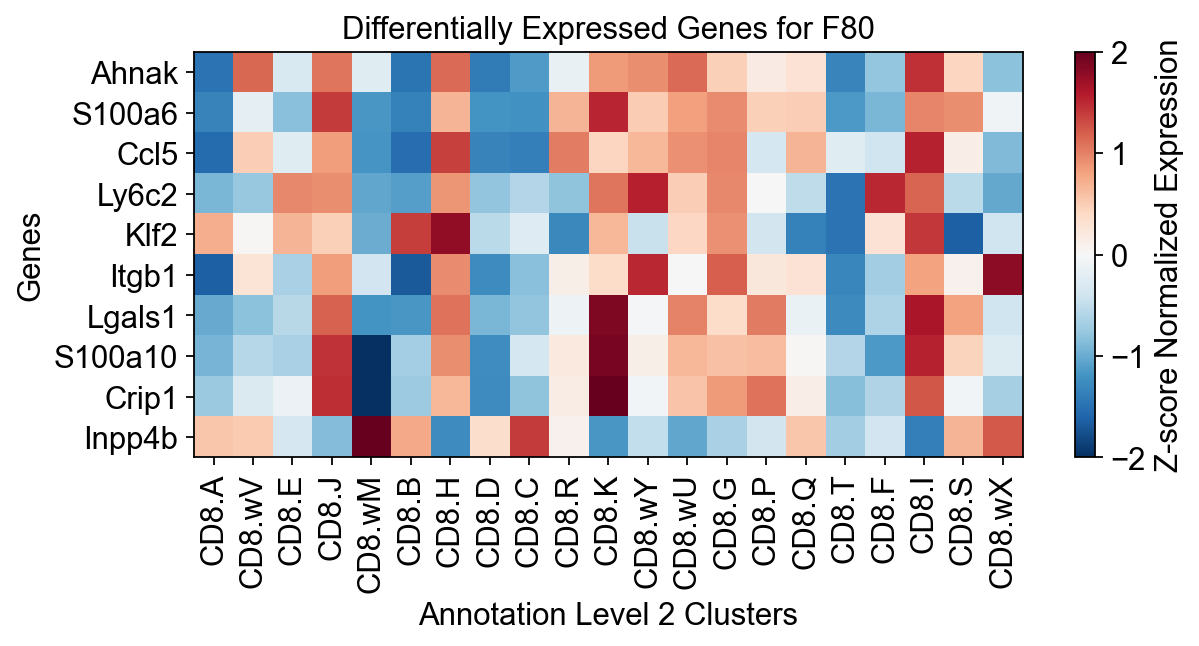

Plot saved: Extended_Data_Fig_3c_F80.pdf


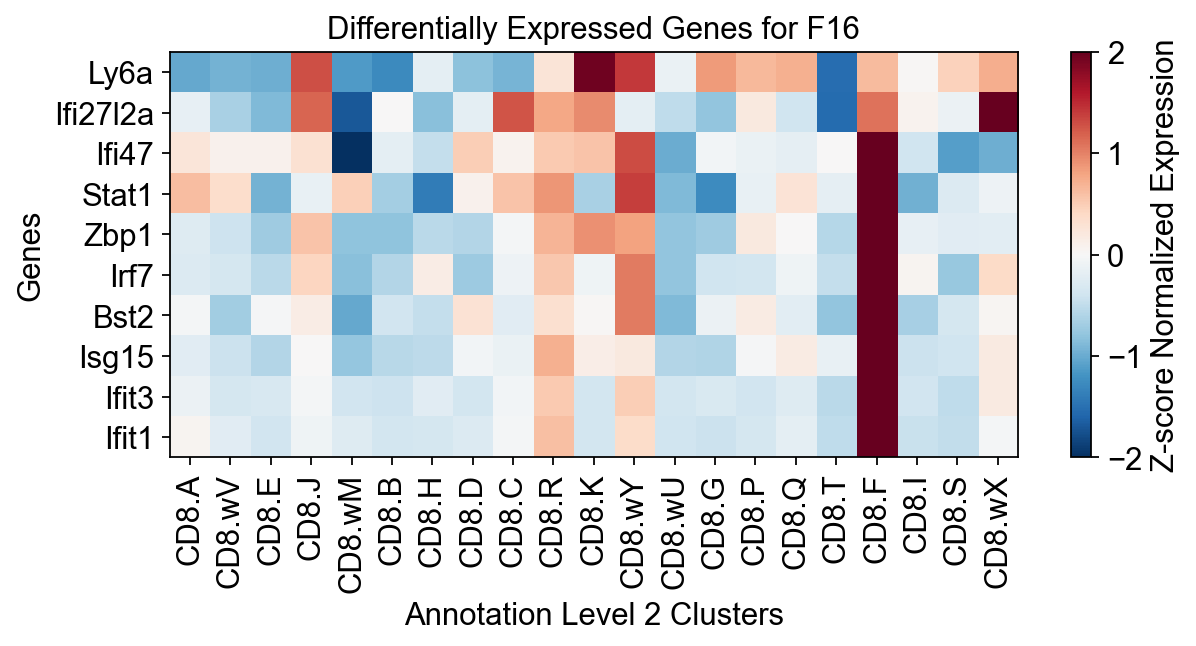

Plot saved: Extended_Data_Fig_3c_F16.pdf


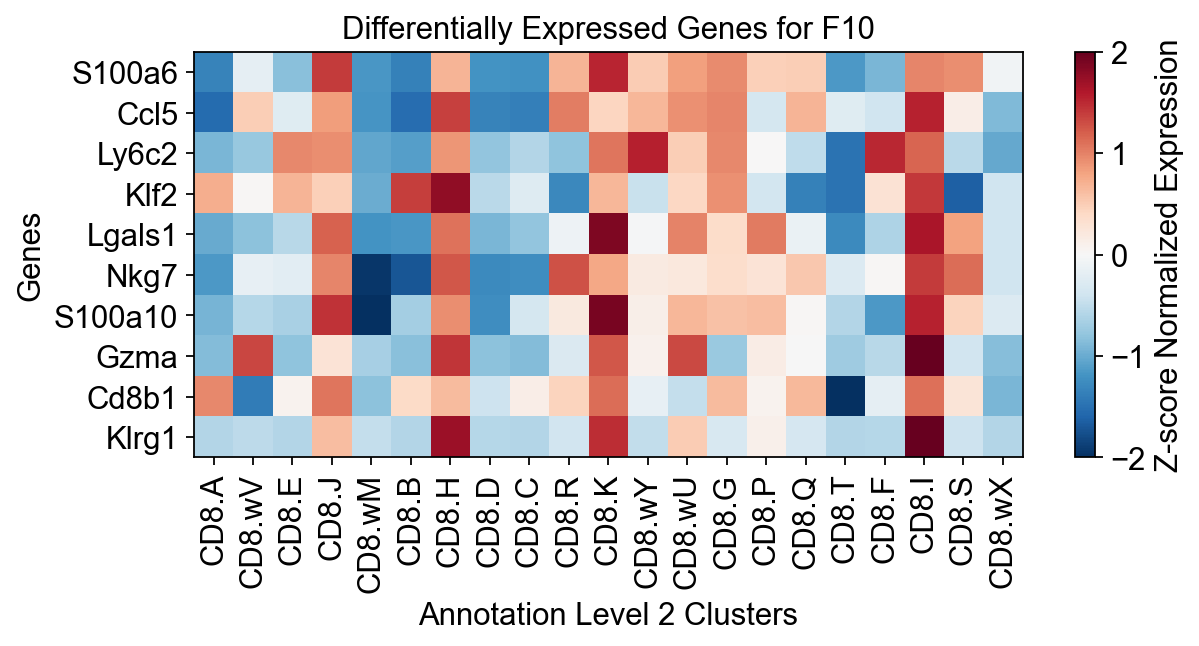

Plot saved: Extended_Data_Fig_3c_F10.pdf

Z-score normalized gene expression for all genes:
cluster      CD8.A    CD8.wV     CD8.E     CD8.J    CD8.wM     CD8.B  \
gene                                                                   
Ahnak    -1.478761  1.145007 -0.307368  1.071632 -0.238040 -1.462218   
Bst2     -0.032016 -0.701622 -0.022481  0.145447 -1.015740 -0.378398   
Ccl5     -1.533058  0.488762 -0.240661  0.828661 -1.179534 -1.516226   
Cd8b1     0.958007 -1.405831  0.066851  1.062967 -0.818086  0.377022   
Crip1    -0.744824 -0.296008 -0.119358  1.472337 -2.075367 -0.732095   
Gzma     -0.863114  1.340363 -0.799438  0.280986 -0.670253 -0.835592   
Ifi27l2a -0.160848 -0.649950 -0.884559  1.167616 -1.693946  0.013399   
Ifi47     0.248488  0.078581  0.081597  0.299217 -2.163220 -0.200723   
Ifit1     0.049795 -0.230741 -0.389160 -0.088496 -0.257091 -0.364741   
Ifit3    -0.118890 -0.344062 -0.312661 -0.041314 -0.377899 -0.412237   
Inpp4b    0.555230  0.518707 -0.339409 -0.86

In [62]:
# Extended Data Fig. 3c - Heatmaps of gene-program gene expression (z-scored mean expression)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scipy.sparse as sparse
# Ensure we use your preferred normalized data
mdata['RNA'].X = mdata['RNA'].layers['scaled']
# Recompute top factors (self-contained block)
def compute_factor_log2fc(L_np, group1, group2, factor_names):
    group1 = [g for g in group1 if g in L_df.index]
    group2 = [g for g in group2 if g in L_df.index]
    if not group1 or not group2:
        return None
    group1_idx = [L_df.index.get_loc(g) for g in group1]
    group2_idx = [L_df.index.get_loc(g) for g in group2]
    loadings_group1 = L_np[group1_idx].mean(axis=0)
    loadings_group2 = L_np[group2_idx].mean(axis=0)
    fc_loadings = loadings_group1 - loadings_group2
    return pd.DataFrame({
        'SYMBOL': factor_names,
        'log2FC': fc_loadings / np.log(2)
    })
# Identify top factor for CD8.E, CD8.F, CD8.H, CD8.G
target_clusters = ['CD8.E', 'CD8.F', 'CD8.H', 'CD8.G']
top_factors = []
n_top = 1 # Top 1 factor per cluster
for cluster in target_clusters:
    group1 = mdata_obs[
        mdata_obs['cluster_annotation'] == cluster
    ][cell_id_col].tolist()
    group2 = mdata_obs[
        mdata_obs['cluster_annotation'] != cluster
    ][cell_id_col].tolist()
    if group1 and group2:
        log2fc_df = compute_factor_log2fc(L_np, group1, group2, factor_names)
        if log2fc_df is not None:
            top = log2fc_df.sort_values(by='log2FC', ascending=False).head(n_top)
            top_factors.extend(top['SYMBOL'].tolist())
            print(f"Top factor for {cluster}: {top['SYMBOL'].tolist()}")
        else:
            print(f"Skipping {cluster}: group1 has {len(group1)} cells, group2 has {len(group2)} cells")
# Remove duplicates
top_factors = list(dict.fromkeys(top_factors))
print(f"Selected factors: {top_factors}")
# Extract top genes for each selected factor
n_top_genes = 10 # Number of top genes per factor
factor_genes = {factor: [] for factor in top_factors}
for factor in top_factors:
    factor_idx = list(factor_names).index(factor)
    gene_loadings = pd.Series(F_np[:, factor_idx], index=gene_names)
    top = gene_loadings.abs().sort_values(ascending=False).head(n_top_genes)
    factor_genes[factor] = top.index.tolist()
    print(f"Top {n_top_genes} genes for {factor}: {top.index.tolist()}")
# Automatically use all CD8 clusters if unique_clusters not defined
if 'unique_clusters' not in globals():
    unique_clusters = sorted(
        [c for c in mdata_obs['cluster_annotation'].unique() if c.startswith('CD8_')]
    )
cluster_mask = mdata_obs['cluster_annotation'].isin(unique_clusters)
subset_obs = mdata_obs[cluster_mask]
subset_X = mdata['RNA'].X[cluster_mask]
cluster_labels = subset_obs['cluster_annotation'].values
unique_labels, inverse = np.unique(cluster_labels, return_inverse=True)
n_genes = subset_X.shape[1]
mean_expr_matrix = np.empty((len(unique_labels), n_genes))
for i, label in enumerate(unique_labels):
    mask_i = (inverse == i)
    if sparse.issparse(subset_X):
        mean_expr_matrix[i] = np.ravel(subset_X[mask_i].mean(axis=0))
    else:
        mean_expr_matrix[i] = subset_X[mask_i].mean(axis=0)
mean_expr_pivot = pd.DataFrame(
    mean_expr_matrix,
    index=unique_labels,
    columns=mdata['RNA'].var_names
).T # genes x clusters
mean_expr_pivot = mean_expr_pivot[unique_clusters] # Order correctly
# === Build expression DataFrame using REAL expression ===
gene_expression = []
for cluster in unique_clusters:
    for factor in top_factors:
        for gene in factor_genes[factor]:
            if gene in mean_expr_pivot.index:
                gene_expression.append({
                    'cluster': cluster,
                    'gene': gene,
                    'mean_expr': mean_expr_pivot.loc[gene, cluster],
                    'factor': factor
                })
expr_df = pd.DataFrame(gene_expression)
# Use a classic diverging red-blue colormap (negative: blue, zero: white, positive: red)
cmap = 'RdBu_r' # Built-in matplotlib colormap: red-blue reversed (high=red, low=blue)
# Set z-score range for expression scale
zscore_min = -2.0
zscore_max = 2.0
# Create heatmaps for each factor
for i, factor in enumerate(top_factors):
    factor_expr_df = expr_df[expr_df['factor'] == factor]
    pivot_df = factor_expr_df.pivot(index='gene', columns='cluster', values='mean_expr').fillna(0)
    pivot_df = pivot_df[unique_clusters]
    # Z-score normalization per gene
    pivot_df = pivot_df.apply(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else x, axis=1)
    # Order genes by max absolute z-score
    pivot_df = pivot_df.loc[pivot_df.abs().max(axis=1).sort_values(ascending=False).index]
    # Color map
    cmap = 'RdBu_r'
    # Create heatmap
    fig, ax = plt.subplots(figsize=(8, 4.25))
    heatmap = ax.imshow(pivot_df.values, cmap=cmap, aspect='auto',
    vmin=zscore_min, vmax=zscore_max, interpolation='nearest')
    ax.invert_yaxis()
    ax.set_xticks(np.arange(len(unique_clusters)))
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_xticklabels(unique_clusters, rotation=45, ha='right')
    ax.set_yticklabels(pivot_df.index)
    ax.set_xlabel('Annotation Level 2 Clusters')
    ax.set_ylabel('Genes')
    ax.set_title(f'Differentially Expressed Genes for {factor}')
    ax.set_xticklabels([cluster.replace('CD8_', '') for cluster in unique_clusters], rotation=90, ha='center')
    ax.grid(False)
    plt.colorbar(heatmap, label='Z-score Normalized Expression')
    plt.tight_layout()
    plt.savefig(f'Extended_Data_Fig_3c_{factor}.pdf', format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    print(f'Plot saved: Extended_Data_Fig_3c_{factor}.pdf')
# Print results
print("\nZ-score normalized gene expression for all genes:")
pivot_df = expr_df.groupby(['gene', 'cluster'])['mean_expr'].first().unstack().fillna(0)[unique_clusters]
pivot_df = pivot_df.apply(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else x, axis=1)
print(pivot_df)

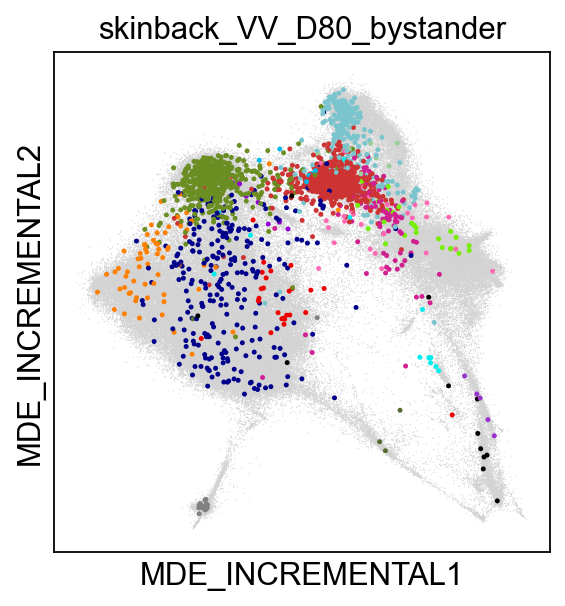

Plot saved: Extended_Data_Fig_3d.pdf


In [63]:
# Extended Data Fig. 3d — Representative condition enriched for memory clusters
condition = 'skinback_VV_D80_bystander'
default_color = '#BAB0AC'  # Gray for cells not meeting the condition

fig, ax = plt.subplots(figsize=(3.75, 4))

# Create a new column for coloring based on the condition
rna.obs['highlight_color'] = np.where(
    rna.obs['condition_detailed_organ'] == condition,
    rna.obs['cluster_annotation'],  # Use cluster_annotation for highlighted cells
    None                            # None for cells that don't meet the condition
)

# Set dot sizes: larger for highlighted cells
sizes = np.where(rna.obs['highlight_color'].notnull(), 20, 1)

# Plot MDE
sc.pl.embedding(
    rna,
    basis="MDE_INCREMENTAL",
    color="highlight_color",
    palette=custom_colors,
    legend_loc=None,
    ax=ax,
    size=sizes,
    show=False,
    title=condition
)

plt.tight_layout()
plt.savefig("Extended_Data_Fig_3d.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Plot saved: Extended_Data_Fig_3d.pdf")

In [64]:
# Extended Data Fig. 3e-h - Volcano plots and balloon plots (memory cluster DEGs)
import pandas as pd

# Set your MuData path here (replace with the actual path to your .h5mu file)
adata_all = mdata['RNA']  # Extract the RNA modality

conditions = ["healthy", "autoimmunity", "virus"]
clusters = ['CD8.E', 'CD8.F', 'CD8.H', 'CD8.G']

# Select best sample per condition for each cluster
selected_samples = {}
for cluster in clusters:
    selected_samples[cluster] = []
    for condition in conditions:
        # Use a boolean mask to filter obs without copying the AnnData
        subset_mask = adata_all.obs['condition_broad'] == condition
        
        # Work directly with the filtered obs DataFrame
        obs_subset = adata_all.obs[subset_mask][['sample_code', 'cluster_annotation']]
        
        # Compute cell counts per sample and cluster
        cell_counts = obs_subset.groupby(['sample_code', 'cluster_annotation']).size().reset_index(name='cell_count')
        
        if cluster not in obs_subset['cluster_annotation'].values:
            continue
        
        cluster_counts = cell_counts[cell_counts['cluster_annotation'] == cluster]
        if cluster_counts.empty:
            continue
        
        best_sample = cluster_counts.sort_values('cell_count', ascending=False).iloc[0]['sample_code']
        selected_samples[cluster].append((condition, best_sample))

# Print or return the selected samples
for cluster in clusters:
    if selected_samples[cluster]:
        print(f"Cluster {cluster}:")
        for condition, sample in selected_samples[cluster]:
            print(f"  Condition: {condition}, Selected Sample: {sample}")


Cluster CD8.E:
  Condition: healthy, Selected Sample: I29H8_spleen_18mo_allT_mouse0095
  Condition: autoimmunity, Selected Sample: I24H5_spleen_Foxp3mutant_D19_allT_mouse0057
  Condition: virus, Selected Sample: I46H10_skinback_VV_D80_bystander_CD8p_mouse_0185
Cluster CD8.F:
  Condition: healthy, Selected Sample: I7H4_LNaxillary_allT_mouse0018
  Condition: autoimmunity, Selected Sample: I49H7_pancreas_NOD_allT_mouse_0228
  Condition: virus, Selected Sample: I46H12_LN_VV_D80_CD8pCD44pCD103p_mouse_0185
Cluster CD8.H:
  Condition: healthy, Selected Sample: I39H3_decidua_E12.5_allT_mouse0135
  Condition: autoimmunity, Selected Sample: I74H15_lung_Foxp3mutant_D28_allT_mouse_0392
  Condition: virus, Selected Sample: I45H14_spleen_dirty_2m_LCMVarm_D30_CD8pCD44pGP33GP276NP396Tetp_mouse_0178
Cluster CD8.G:
  Condition: healthy, Selected Sample: I46H15_spleen_CD45p_mouse_0181
  Condition: autoimmunity, Selected Sample: I74H13_colonLP_Foxp3mutant_D28_allT_mouse_0392
  Condition: virus, Selected S

In [65]:
# Extended Data Fig. 3e-h - Volcano plots and balloon plots (memory cluster DEGs)
import pandas as pd
import numpy as np

def select_top_genes(signature_file, clusters, pval_threshold=0.05, log2fc_threshold=0.5, highlight_gene_column='SYMBOL'):
    """
    Select the top 10 up-regulated and top 10 down-regulated genes for each cluster from a signature file.
    Parameters:
    - signature_file (str): Path to the signature file with DE results.
    - clusters (list): List of cluster names (e.g., ['CD8.E', 'CD8.F', ...]).
    - pval_threshold (float): Adjusted p-value threshold for significance.
    - log2fc_threshold (float): |log2FC| threshold for significance.
    - highlight_gene_column (str): Column name for genes in signature_file.
    Returns:
    - dict: Dictionary with cluster names as keys and tuples of (top_10_up, top_10_down) gene lists as values.
    """
    # Load the signature DataFrame
    signature_df = pd.read_csv(signature_file, sep='\t', encoding='utf-8')
    
    top_genes = {}
    for cluster in clusters:
        # Prepare data for the cluster
        log2fc_col = f'log2FC_{cluster}_vs_All'
        pval_col = f'adj.P.Val_{cluster}_vs_All'
        plot_df = signature_df[[highlight_gene_column, log2fc_col, pval_col]].copy()
        plot_df['gene'] = plot_df[highlight_gene_column]
        plot_df['log2FC'] = plot_df[log2fc_col]
        plot_df['minus_log10_padj'] = -np.log10(plot_df[pval_col].clip(lower=1e-300))
        
        # Highlight significant genes
        significant = plot_df[
            (plot_df[pval_col] < pval_threshold) & 
            (abs(plot_df['log2FC']) > log2fc_threshold)
        ]
        
        # Select top 10 up-regulated (highest positive log2FC)
        top_10_up = significant[significant['log2FC'] > 0][['gene', 'log2FC']].sort_values(
            'log2FC', ascending=False
        ).head(10)['gene'].tolist()
        
        # Select top 10 down-regulated (lowest negative log2FC)
        top_10_down = significant[significant['log2FC'] < 0][['gene', 'log2FC']].sort_values(
            'log2FC', ascending=True
        ).head(10)['gene'].tolist()
        
        top_genes[cluster] = (top_10_up, top_10_down)
    
    return top_genes

# Define file path and clusters
main_signature_file = 'data/ttlist_OneVsAll.txt'
clusters = ['CD8.E', 'CD8.F', 'CD8.H', 'CD8.G']

# Select top genes
top_genes_dict = select_top_genes(
    signature_file=main_signature_file,
    clusters=clusters,
    pval_threshold=0.05,
    log2fc_threshold=0.5,
    highlight_gene_column='SYMBOL'
)

# Print results
for cluster in clusters:
    up_genes, down_genes = top_genes_dict[cluster]
    print(f"Cluster {cluster}:")
    print(f"  Top 10 Up-regulated Genes: {up_genes}")
    print(f"  Top 10 Down-regulated Genes: {down_genes}")


Cluster CD8.E:
  Top 10 Up-regulated Genes: ['Ly6c2', 'Il7r', 'Sell', 'Sidt1', 'Bcl2', 'Eef1b2', 'Npm1', 'Il2rb', 'Klf2', 'Lef1']
  Top 10 Down-regulated Genes: ['Itga4', 'Gzmb', 'S100a6', 'Gzma', 'Ifi27l2a', 'Gzmk', 'Id2', 'Ly6a', 'Lgals3', 'Rgs1']
Cluster CD8.F:
  Top 10 Up-regulated Genes: ['Isg15', 'Ly6c2', 'Bst2', 'Ifit3', 'Irf7', 'Rnf213', 'Zbp1', 'Rtp4', 'Usp18', 'Ifit1']
  Top 10 Down-regulated Genes: ['S100a10', 'Itga4', 'S100a6', 'Ypel3', 'S100a11', 'Hmgb2', 'Srgn', 'Adgre5', 'Lgals3', 'Id2']
Cluster CD8.H:
  Top 10 Up-regulated Genes: ['Ccl5', 'Gzma', 'Lgals1', 'Zeb2', 'Ahnak', 'Nkg7', 'Gzmb', 'S100a6', 'Cx3cr1', 'Klrg1']
  Top 10 Down-regulated Genes: ['Eef1b2', 'Ly6e', 'Ltb', 'Npm1', 'Ccr7', 'Rack1', 'Gas5', 'Naca', 'Limd2', 'Tcf7']
Cluster CD8.G:
  Top 10 Up-regulated Genes: ['Ccl5', 'S100a6', 'Il7r', 'Itgb1', 'Ly6c2', 'Ly6a', 'Klf2', 'Cxcr3', 'Itga4', 'Lgals1']
  Top 10 Down-regulated Genes: ['Gzma', 'Ccr7', 'Lef1', 'Prkch', 'Gzmb', 'Smc4', 'Cd8a', 'Satb1', 'Sell', 'Lars

In [66]:
# Extended Data Fig. 3e-h - Volcano plots and balloon plots (memory cluster DEGs)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from adjustText import adjust_text

# Define custom colors for clusters
custom_colors = {
    'CD8.E': '#6B8E23',  # darkolivegreen2 (olive drab)
    'CD8.F': '#9400D3',  # darkorchid2
    'CD8.H': '#7AC5CD',  # cadetblue2
    'CD8.G': '#CD3333',  # brown2
}

def plot_volcano(
    signature_file,
    cluster,
    pval_threshold=0.05,
    log2fc_threshold=0.5,
    non_highlight_size=1,
    highlight_size=5,
    label_top_n=10,
    figsize=(5, 5),
    save_path=None,
    highlight_gene_column='SYMBOL',
    xlim_min=-3,
    xlim_max=4
):
    """
    Generate a volcano plot from a signature DataFrame for a specific cluster with staggered gene labels.
    Labels the top 10 up-regulated and top 10 down-regulated significant genes.
    Parameters:
    - signature_file (str): Path to the signature file with DE results.
    - cluster (str): Cluster name (e.g., 'CD8.E', 'CD8.F', etc.).
    - pval_threshold (float): Adjusted p-value threshold for significance.
    - log2fc_threshold (float): |log2FC| threshold for significance.
    - non_highlight_size (float): Size of non-significant gene points.
    - highlight_size (float): Size of significant gene points.
    - label_top_n (int): Number of top up- and down-regulated genes to label.
    - figsize (tuple): Figure size (width, height).
    - save_path (str, optional): Path to save the plot. If None, plot is displayed.
    - highlight_gene_column (str): Column name for genes in signature_file.
    - xlim_min (float): Minimum x-axis limit (log2 fold change).
    - xlim_max (float): Maximum x-axis limit (log2 fold change).
    """
    # Load the signature DataFrame
    signature_df = pd.read_csv(signature_file, sep='\t', encoding='utf-8')
    # Prepare data for volcano plot
    log2fc_col = f'log2FC_{cluster}_vs_All'
    pval_col = f'adj.P.Val_{cluster}_vs_All'
    plot_df = signature_df[[highlight_gene_column, log2fc_col, pval_col]].copy()
    plot_df['gene'] = plot_df[highlight_gene_column]
    plot_df['log2FC'] = plot_df[log2fc_col]
    plot_df['minus_log10_padj'] = -np.log10(plot_df[pval_col].clip(lower=1e-300))
    # Highlight based on significance thresholds
    plot_df['highlight'] = (plot_df[pval_col] < pval_threshold) & (abs(plot_df['log2FC']) > log2fc_threshold)
    # Create the volcano plot
    fig, ax = plt.subplots(figsize=figsize)
    # Plot non-significant genes
    non_highlight = plot_df[~plot_df['highlight']]
    ax.scatter(
        non_highlight['log2FC'],
        non_highlight['minus_log10_padj'],
        color='grey',
        alpha=0.5,
        s=non_highlight_size,
        rasterized=True
    )
    # Plot significant genes with cluster-specific color
    highlight = plot_df[plot_df['highlight']]
    ax.scatter(
        highlight['log2FC'],
        highlight['minus_log10_padj'],
        color=custom_colors.get(cluster, '#FF0000'),  # Use cluster color, fallback to red
        alpha=1,
        s=highlight_size,
        rasterized=True
    )
    # Add labels for top 10 up-regulated and top 10 down-regulated significant genes
    significant = plot_df[plot_df['highlight']]
    top_up = significant[significant['log2FC'] > 0][['gene', 'log2FC', 'minus_log10_padj']].sort_values(
        'log2FC', ascending=False
    ).head(label_top_n)
    top_down = significant[significant['log2FC'] < 0][['gene', 'log2FC', 'minus_log10_padj']].sort_values(
        'log2FC', ascending=True
    ).head(label_top_n)
    top_highlight = pd.concat([top_up, top_down])
    texts = []
    for _, row in top_highlight.iterrows():
        text = ax.text(
            row['log2FC'],
            row['minus_log10_padj'],
            row['gene'],
            fontsize=6,
            ha='right' if row['log2FC'] < 0 else 'left'
        )
        texts.append(text)
    # Adjust text to avoid overlap
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
        expand_points=(1.2, 1.2),
        force_points=0.5,
        force_text=0.5
    )
    # Axes and title
    ax.set_xlabel(f'Log2 Fold Change ({cluster} vs Others)')
    ax.set_ylabel('-Log10 (Adjusted P-value)')
    ax.set_title(f'Volcano Plot: {cluster} vs All Others (Signature Genes)')
    # Set x-axis limits
    ax.set_xlim(xlim_min, xlim_max)
    # Add significance lines
    ax.axvline(x=log2fc_threshold, color='black', linestyle='--', linewidth=0.5)
    ax.axvline(x=-log2fc_threshold, color='black', linestyle='--', linewidth=0.5)
    ax.axhline(y=-np.log10(pval_threshold), color='black', linestyle='--', linewidth=0.5)
    # Adjust layout
    plt.tight_layout()
    # Save or display
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

# Define file path and clusters
main_signature_file = 'data/ttlist_OneVsAll.txt'
clusters = ['CD8.E', 'CD8.F', 'CD8.H', 'CD8.G']

# Generate volcano plots
for cluster in clusters:
    save_path = f'Extended_Data_Fig_3e-h_{cluster}.pdf'
    plot_volcano(
        signature_file=main_signature_file,
        cluster=cluster,
        pval_threshold=0.05,
        log2fc_threshold=0.5,
        non_highlight_size=1,
        highlight_size=5,
        label_top_n=10,
        figsize=(5, 5),
        save_path=save_path,
        highlight_gene_column='SYMBOL',
        xlim_min=-3,
        xlim_max=4
    )


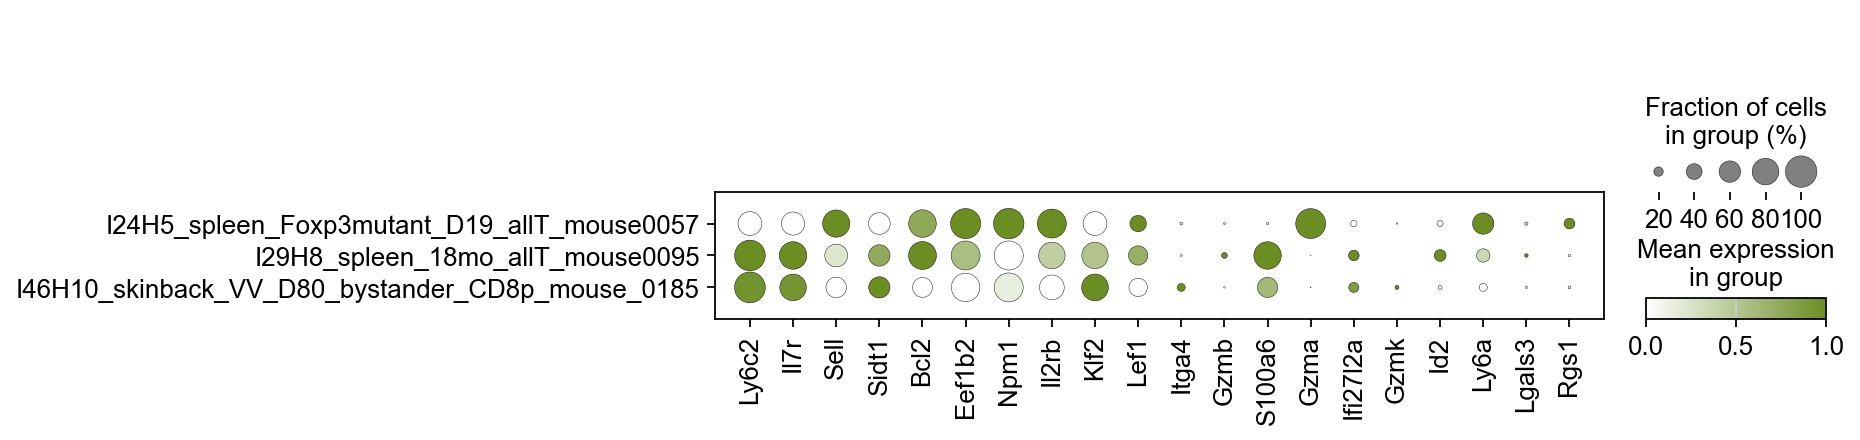

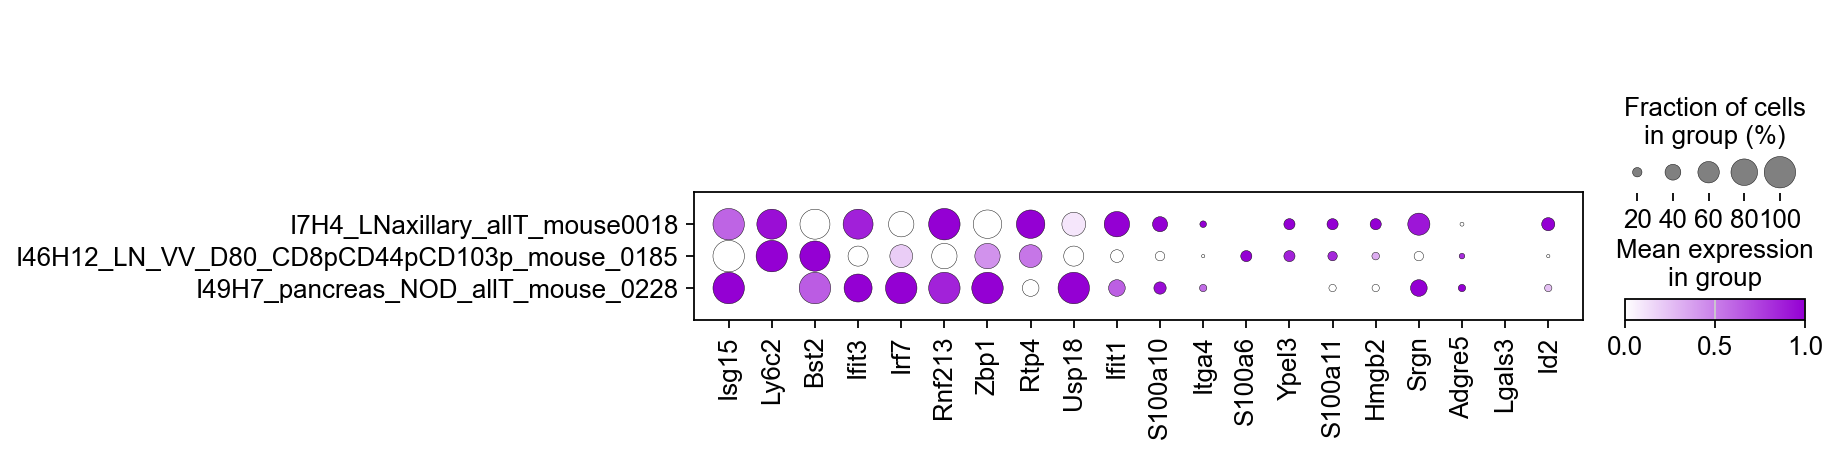

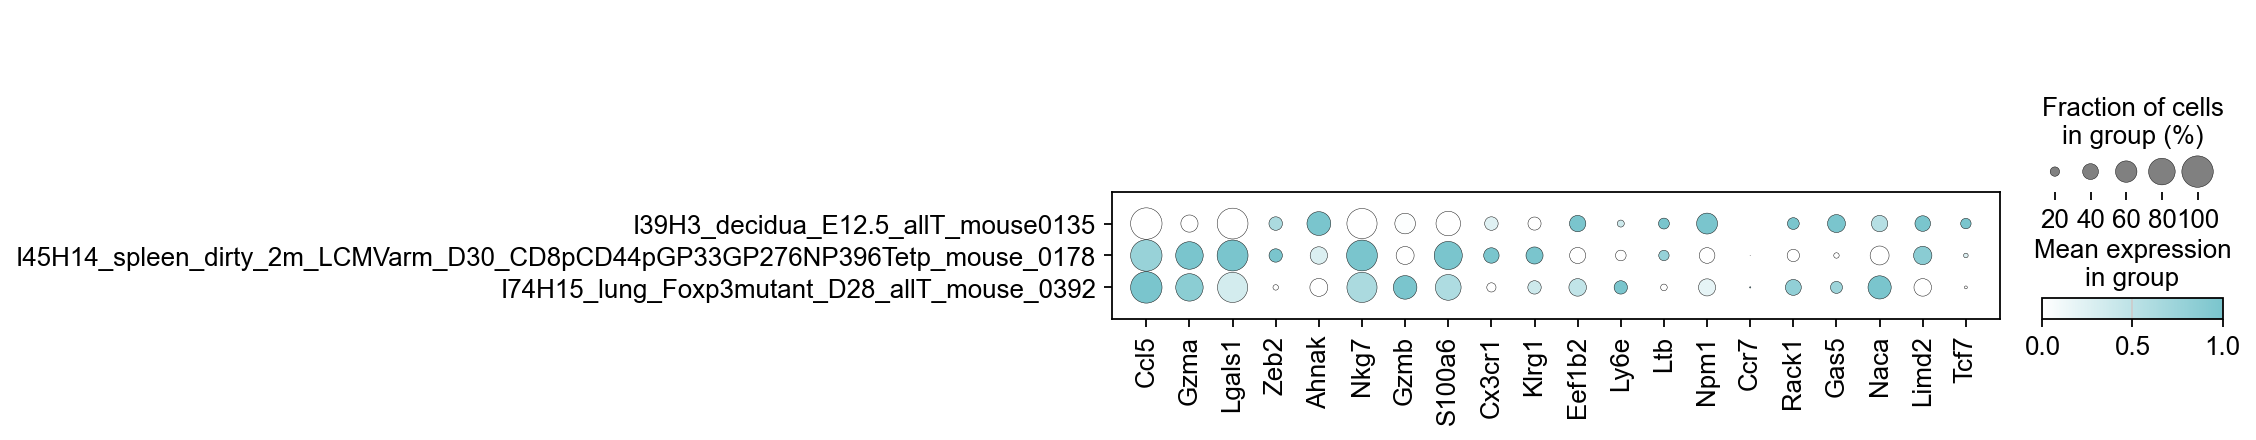

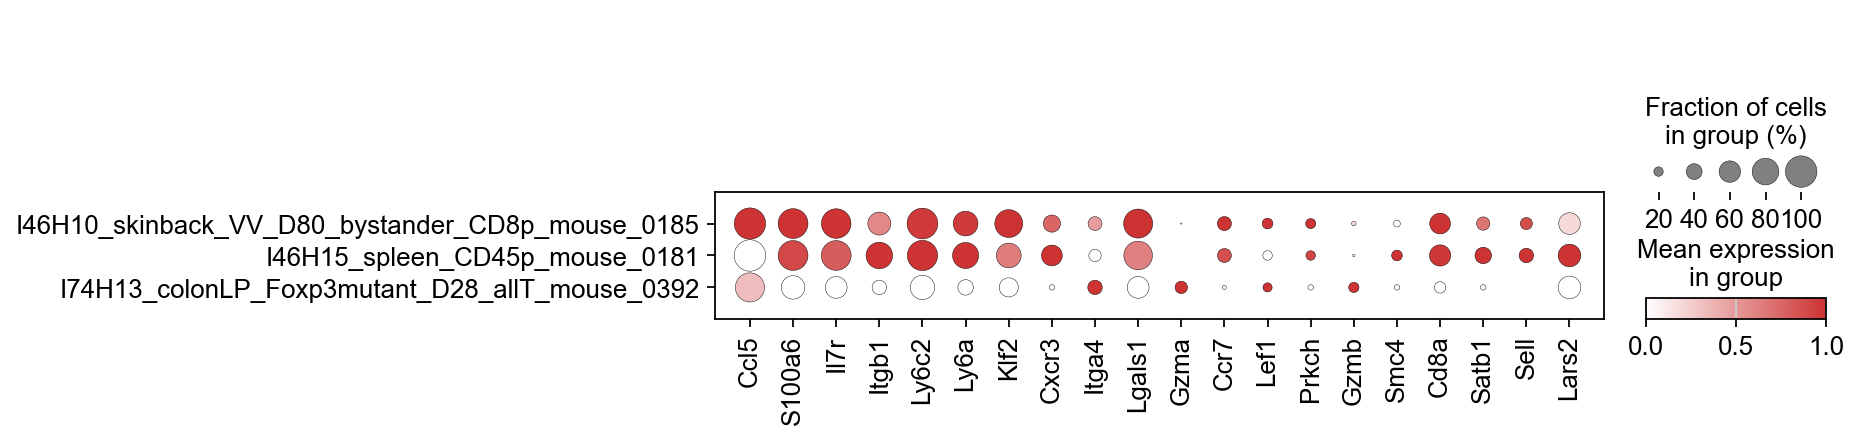

In [67]:
# Extended Data Fig. 3e-h - Volcano plots and balloon plots (memory cluster DEGs)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scanpy as sc
from matplotlib.colors import LinearSegmentedColormap

# Define custom colors for clusters
custom_colors = {
    'CD8.E': '#6B8E23',  # darkolivegreen2 (olive drab)
    'CD8.F': '#9400D3',  # darkorchid2
    'CD8.H': '#7AC5CD',  # cadetblue2
    'CD8.G': '#CD3333',  # brown2
}

def select_top_genes(signature_file, clusters, pval_threshold=0.05, log2fc_threshold=0.5, highlight_gene_column='SYMBOL'):
    """
    Select the top 10 up-regulated and top 10 down-regulated genes for each cluster from a signature file.
    Parameters:
    - signature_file (str): Path to the signature file with DE results.
    - clusters (list): List of cluster names (e.g., ['CD8.E', 'CD8.F', ...]).
    - pval_threshold (float): Adjusted p-value threshold for significance.
    - log2fc_threshold (float): |log2FC| threshold for significance.
    - highlight_gene_column (str): Column name for genes in signature_file.
    Returns:
    - dict: Dictionary with cluster names as keys and tuples of (top_10_up, top_10_down) gene lists as values.
    """
    signature_df = pd.read_csv(signature_file, sep='\t', encoding='utf-8')
    top_genes = {}
    for cluster in clusters:
        log2fc_col = f'log2FC_{cluster}_vs_All'
        pval_col = f'adj.P.Val_{cluster}_vs_All'
        plot_df = signature_df[[highlight_gene_column, log2fc_col, pval_col]].copy()
        plot_df['gene'] = plot_df[highlight_gene_column]
        plot_df['log2FC'] = plot_df[log2fc_col]
        significant = plot_df[
            (plot_df[pval_col] < pval_threshold) & 
            (abs(plot_df['log2FC']) > log2fc_threshold)
        ]
        top_10_up = significant[significant['log2FC'] > 0][['gene', 'log2FC']].sort_values(
            'log2FC', ascending=False
        ).head(10)['gene'].tolist()
        top_10_down = significant[significant['log2FC'] < 0][['gene', 'log2FC']].sort_values(
            'log2FC', ascending=True
        ).head(10)['gene'].tolist()
        top_genes[cluster] = (top_10_up, top_10_down)
    return top_genes

# Define file path and clusters
main_signature_file = 'data/ttlist_OneVsAll.txt'
clusters = ['CD8.E', 'CD8.F', 'CD8.H', 'CD8.G']

# Select top genes
top_genes_dict = select_top_genes(
    signature_file=main_signature_file,
    clusters=clusters,
    pval_threshold=0.05,
    log2fc_threshold=0.5,
    highlight_gene_column='SYMBOL'
)

# Load MuData
adata_all = mdata['RNA']  # Extract the RNA modality

conditions = ["healthy", "autoimmunity", "virus"]
os.makedirs('figures', exist_ok=True)  # Create figures directory for scanpy outputs

# Select best samples and generate balloon plots
for cluster in clusters:
    # Get significant genes (combine up and down)
    up_genes, down_genes = top_genes_dict[cluster]
    sig_genes = up_genes + down_genes
    if not sig_genes:
        print(f"No significant genes for {cluster}, skipping balloon plot.")
        continue
    
    # Select best sample per condition for this cluster
    selected_samples = []
    for condition in conditions:
        subset_mask = adata_all.obs['condition_broad'] == condition
        obs_subset = adata_all.obs[subset_mask][['sample_code', 'cluster_annotation']]
        cell_counts = obs_subset.groupby(['sample_code', 'cluster_annotation']).size().reset_index(name='cell_count')
        
        if cluster not in obs_subset['cluster_annotation'].values:
            continue
        
        cluster_counts = cell_counts[cell_counts['cluster_annotation'] == cluster]
        if cluster_counts.empty:
            continue
        
        best_sample = cluster_counts.sort_values('cell_count', ascending=False).iloc[0]['sample_code']
        selected_samples.append((condition, best_sample))
    
    if not selected_samples:
        print(f"No selected samples for {cluster} across conditions, skipping balloon plot.")
        continue
    
    # Prepare subset AnnData for the cluster cells in selected samples
    sample_list = [samp for cond, samp in selected_samples]
    sample_to_condition = {samp: cond for cond, samp in selected_samples}  # For reference, not used in plot
    
    cluster_mask = adata_all.obs['cluster_annotation'] == cluster
    sample_mask = adata_all.obs['sample_code'].isin(sample_list)
    adata_cluster = adata_all[sample_mask & cluster_mask]
    
    if adata_cluster.n_obs == 0:
        print(f"No cells in selected samples for {cluster}, skipping balloon plot.")
        continue
    
    # Use normalized scaled data if available
    if 'scaled' in adata_cluster.layers:
        adata_cluster.X = adata_cluster.layers['scaled']
    
    # Filter to present significant genes
    present_genes = [g for g in sig_genes if g in adata_cluster.var_names]
    if not present_genes:
        print(f"No present genes for {cluster} in data, skipping balloon plot.")
        continue
    
    # Create custom colormap: white to cluster-specific color
    cluster_color = custom_colors.get(cluster, '#FF0000')  # Fallback to red
    custom_cmap = LinearSegmentedColormap.from_list(
        f'white_to_{cluster}', ['#FFFFFF', cluster_color], N=256
    )
    
    # Generate balloon plot: genes on x, sample_code on y
    sc.pl.dotplot(
        adata_cluster,
        var_names=present_genes,
        groupby='sample_code',  # Use sample_code directly
        cmap=custom_cmap,  # White to cluster-specific color
        standard_scale='var',  # Normalize expression per gene
        save=f'Extended_Data_Fig_3e-h_{cluster}.pdf'
    )


# Extended Data Fig. 4

In [69]:
# Extended Data Fig. 4a - GSEA
import pandas as pd
import os
import gseapy as gp
import matplotlib.pyplot as plt
import glob
import numpy as np

# ------------------------------------------------------------------
# 1. Only things you change
# ------------------------------------------------------------------
desired_clusters = ["CD8.Q"]   # full names
source_file = "data/ttlist_OneVsAll.txt"

# ------------------------------------------------------------------
# 2. Load
# ------------------------------------------------------------------
df = pd.read_csv(source_file, sep=None, engine="python", index_col=0)

print("All columns in source file:")
print(list(df.columns))
print()

# ------------------------------------------------------------------
# 3. Pull log2FC + corresponding adj.P.Val and filter
# ------------------------------------------------------------------
selected = {}

for cl in desired_clusters:
    # Find log2FC column
    fc_matches = [
        col for col in df.columns
        if cl in col and ("log2fc" in col.lower() or "log2foldchange" in col.lower())
    ]
    
    # Find adjusted p-value column
    padj_matches = [
        col for col in df.columns
        if cl in col and (
            "adj.p.val" in col.lower() or 
            "adj.pval" in col.lower() or 
            "padj" in col.lower() or
            "fdr" in col.lower()
        )
    ]
    
    if not fc_matches:
        print(f"WARNING: No log2FC column found for {cl}")
        continue
    if not padj_matches:
        print(f"WARNING: No adj.P.Val column found for {cl} → keeping all values (no filter)")
        selected[cl] = df[fc_matches[0]]
        continue
    
    fc_col = fc_matches[0]
    padj_col = padj_matches[0]
    
    print(f"Found {cl}")
    print(f"  log2FC → {fc_col}")
    print(f"  padj   → {padj_col}")
    
    # Keep log2FC only when adj.P.Val < 0.05
    filtered = df[fc_col].where(df[padj_col] < 0.05)
    selected[cl] = filtered

# ------------------------------------------------------------------
# 4. Build final table
# ------------------------------------------------------------------
if not selected:
    raise ValueError("No matching columns were found.")

log_fold_changes = pd.DataFrame(selected)

# Optional: drop genes that are non-significant in ALL selected clusters
log_fold_changes = log_fold_changes.dropna(how="all")

print("\nFinal shape (after adj.P.Val < 0.05 filter):", log_fold_changes.shape)
print(log_fold_changes.head())

# Convert the index of log_fold_changes to all uppercase
log_fold_changes.index = log_fold_changes.index.str.upper()
log_fold_changes

columns = log_fold_changes.columns
try:
    os.mkdir('gsea_preranks')
except:
    print('Directory already exists')

for i in columns:
    lfc_current = log_fold_changes[[i]]
    #strip whitespace in the index of lfc_current
    lfc_current.index = lfc_current.index.str.strip()
    #split any values in the index on ; and keep the first gene in the resulting list
    lfc_current.index = lfc_current.index.str.split(';').str[0]
    #drop na rows
    lfc_current = lfc_current.dropna()
    #make index uppercase
    lfc_current.index = lfc_current.index.str.upper()
    #drop rows with duplicate index
    lfc_current = lfc_current[~lfc_current.index.duplicated(keep='first')]



    lfc_current.sort_values(i, inplace=True, ascending = False)
    lfc_current.to_csv('gsea_preranks/'+i+'.rnk', sep='\t', header=False)

# File paths
file_paths = {
    'MackayRES': 'data/TRM_Mackay.txt',  # From Mackay et al., Science 2016
    'CrowlRES': 'data/TRM_Crowl.txt',    # From Crowl et al., Nat Immunol 2022
    'MilnerRES': 'data/TRM_Milner.txt'   # From Milner et al., Nature 2017
}

# Function to read gene list from file
def read_gene_list(file_path, is_excel=True):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    try:
        if is_excel:
            # Read Excel, assuming genes are in the first column, no header
            df = pd.read_excel(file_path, header=None, index_col=0)
        else:
            # Read text file, assuming one gene per line
            df = pd.read_csv(file_path, header=None, index_col=0)
        # Extract genes, convert to list, remove NaN, and convert to uppercase
        genes = [str(gene).upper() for gene in df.index if pd.notna(gene)]
        if not genes:
            raise ValueError(f"No valid genes found in {file_path}")
        return genes
    except Exception as e:
        raise ValueError(f"Error reading {file_path}: {e}")

# Read gene lists and store in dictionary
signatures = {}
for name, path in file_paths.items():
    is_excel = path.endswith('.xlsx')
    signatures[name] = read_gene_list(path, is_excel=is_excel)

# Print the signatures dictionary to verify
print(signatures)


All columns in source file:
['log2FC_CD8.A_vs_All', 'log2FC_CD8.B_vs_All', 'log2FC_CD8.E_vs_All', 'log2FC_CD8.F_vs_All', 'log2FC_CD8.wY_vs_All', 'log2FC_CD8.R_vs_All', 'log2FC_CD8.Q_vs_All', 'log2FC_CD8.S_vs_All', 'log2FC_CD8.H_vs_All', 'log2FC_CD8.G_vs_All', 'log2FC_CD8.I_vs_All', 'log2FC_CD8.J_vs_All', 'log2FC_CD8.wU_vs_All', 'log2FC_CD8.wX_vs_All', 'log2FC_CD8.C_vs_All', 'log2FC_CD8.wV_vs_All', 'log2FC_CD8.T_vs_All', 'log2FC_CD8.D_vs_All', 'log2FC_CD8.K_vs_All', 'log2AveExpr_CD8.A_vs_All', 'log2AveExpr_CD8.B_vs_All', 'log2AveExpr_CD8.E_vs_All', 'log2AveExpr_CD8.F_vs_All', 'log2AveExpr_CD8.wY_vs_All', 'log2AveExpr_CD8.R_vs_All', 'log2AveExpr_CD8.Q_vs_All', 'log2AveExpr_CD8.S_vs_All', 'log2AveExpr_CD8.H_vs_All', 'log2AveExpr_CD8.G_vs_All', 'log2AveExpr_CD8.I_vs_All', 'log2AveExpr_CD8.J_vs_All', 'log2AveExpr_CD8.wU_vs_All', 'log2AveExpr_CD8.wX_vs_All', 'log2AveExpr_CD8.C_vs_All', 'log2AveExpr_CD8.wV_vs_All', 'log2AveExpr_CD8.T_vs_All', 'log2AveExpr_CD8.D_vs_All', 'log2AveExpr_CD8.K_vs_

2026-07-24 15:33:33,446 [INFO] Parsing data files for GSEA.............................
2026-07-24 15:33:33,450 [INFO] 0000 gene_sets have been filtered out when max_size=10000 and min_size=5
2026-07-24 15:33:33,450 [INFO] 0003 gene_sets used for further statistical testing.....
2026-07-24 15:33:33,451 [INFO] Start to run GSEA...Might take a while..................
2026-07-24 15:33:33,542 [INFO] Congratulations. GSEApy runs successfully................



Running GSEA for CD8.Q...
      Name       Term        ES       NES NOM p-val FDR q-val FWER p-val  \
0  prerank   CrowlRES  0.796511  3.980692       0.0       0.0        0.0   
1  prerank  MilnerRES  0.810597  3.583088       0.0       0.0        0.0   
2  prerank  MackayRES  0.765707  3.195422       0.0       0.0        0.0   

     Tag %  Gene %                                         Lead_genes Cluster  \
0  188/219  21.87%  RGS1;DENND4A;CCL4;JUNB;TNFAIP3;GZMK;FASL;BTG1;...   CD8.Q   
1    84/95  18.11%  RGS1;DENND4A;CCL4;JUNB;TNFAIP3;FASL;GZMB;LITAF...   CD8.Q   
2    55/68  16.67%  CXCR6;JUNB;TNFAIP3;ITGAE;LITAF;CISH;DUSP1;KLF6...   CD8.Q   

   order  
0      1  
1      2  
2      0  


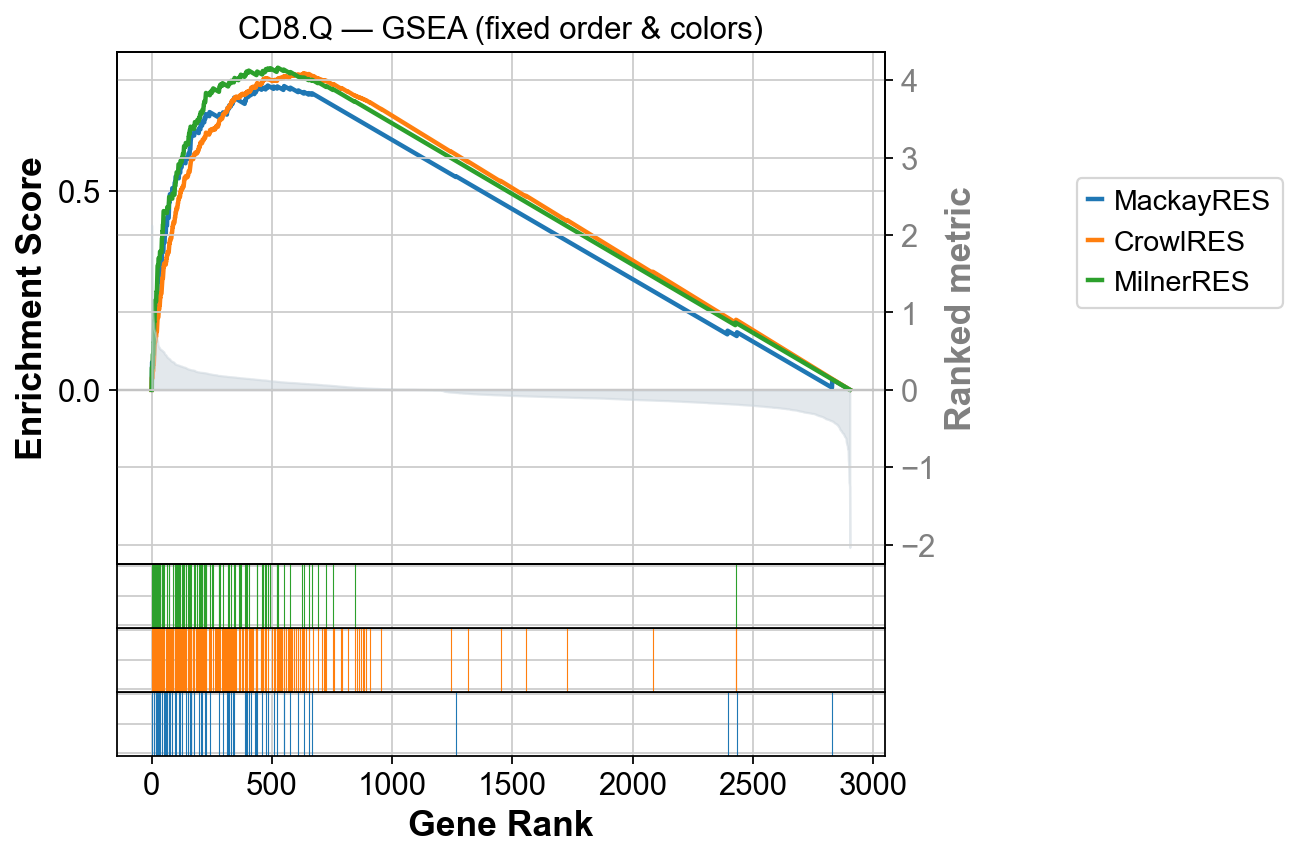

In [70]:
# Extended Data Fig. 4a - GSEA
all_results = []

# ====================== FIXED SETTINGS ======================
desired_order = ['MackayRES', 'CrowlRES', 'MilnerRES']

signature_colors = {
    'MackayRES': '#1f77b4',   # blue
    'CrowlRES':  '#ff7f0e',   # orange
    'MilnerRES': '#2ca02c',   # green
}
# ===========================================================

for cluster in ['CD8.Q']:
    print(f"Running GSEA for {cluster}...")   # helpful feedback
    
    pre_res = gp.prerank(
        rnk=f"gsea_preranks/{cluster}.rnk",
        gene_sets=signatures,
        threads=4,
        min_size=5,
        max_size=10000,
        permutation_num=1000,
        outdir=None,
        seed=6,
        verbose=True,
    )
    
    # === Get results for saving ===
    res_df = pre_res.res2d.copy()
    
    # Add cluster info and save all results (this was missing)
    res_df['Cluster'] = cluster
    all_results.append(res_df)          # <-- important
    
    # === Fixed order + colors for plotting ===
    res_df['order'] = res_df['Term'].apply(
        lambda x: next((i for i, sig in enumerate(desired_order) if sig in x), 999)
    )
    
    res_df = res_df.sort_values(by=['order', 'NES'], ascending=[True, False])
    
    plot_terms = res_df['Term'].head(len(desired_order)).tolist()
    
    plot_colors = []
    for t in plot_terms:
        assigned = False
        for sig, col in signature_colors.items():
            if sig in t:
                plot_colors.append(col)
                assigned = True
                break
        if not assigned:
            plot_colors.append('#7f7f7f')
    
    # Plot
    axs = pre_res.plot(
        terms=plot_terms,
        colors=plot_colors,
        legend_kws={'loc': (1.25, 0.5)},
        show_ranking=True,
        figsize=(4, 4.5),
    )
    
    plt.title(f'{cluster} — GSEA (fixed order & colors)')
    
    output_dir = os.path.join('gsea_figures', cluster)
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, f'Extended_Data_Fig_4a_{cluster}.pdf'),
                dpi=300, bbox_inches='tight')
    # plt.show()   # uncomment if you want to see it live

# ====================== SAVE ALL RESULTS ======================
if all_results:
    results_df = pd.concat(all_results, ignore_index=True)
    results_df.to_csv('Extended_Data_Fig_4a_results.csv', index=False)
    print(results_df)
else:
    print("No results were collected!")
    

In [71]:
# Extended Data Fig. 4f - Transcription factor expression
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your genes
genes = ["Hic1", "Zfp683", "Runx3"]

# Check which genes exist
available_genes = [g for g in genes if g in adata.var_names]
missing_genes = set(genes) - set(adata.var_names)

if missing_genes:
    print("Missing genes:", missing_genes)

if len(available_genes) == 0:
    raise ValueError("None of the requested genes were found!")

# Subset AnnData to available genes
adata_subset = adata[:, available_genes].copy()

# Extract normalized expression (handle sparse matrix)
X = adata_subset.layers["log_norm"]
if hasattr(X, "toarray"):          # convert sparse → dense if needed
    X = X.toarray()

expr_df = pd.DataFrame(
    X,
    columns=available_genes,
    index=adata_subset.obs_names
)

# Add grouping column
expr_df["cell_type"] = adata_subset.obs["cluster_annotation"].values

print("Expression shape:", expr_df.shape)
print("Unique cell types:", expr_df["cell_type"].nunique())
print(expr_df.head())

Expression shape: (206160, 4)
Unique cell types: 21
                       Hic1  Zfp683     Runx3 cell_type
index                                                  
IGT1.AAAGCAAAGGTACTCT   0.0     0.0  1.911568     CD8.A
IGT1.AAAGCAATCCAATGGT   0.0     0.0  0.000000     CD8.A
IGT1.AAATGCCAGAAGGCCT   0.0     0.0  0.000000    CD8.wV
IGT1.AAATGCCTCTCTTATG   0.0     0.0  2.285441    CD8.wV
IGT1.AACCATGCAACACCCG   0.0     0.0  1.328932     CD8.E


In [72]:
# Extended Data Fig. 4f - Transcription factor expression
# Compute mean expression per cell type
mean_expr = expr_df.groupby('cell_type')[genes].mean()

# Optional: Add standard error for error bars
std_expr = expr_df.groupby('cell_type')[genes].std()
n_cells = expr_df.groupby('cell_type')[genes].count()  # Number of cells per group
sem_expr = std_expr / np.sqrt(n_cells)  # Standard error of the mean

print(mean_expr.head())  # Preview


               Hic1    Zfp683     Runx3
cell_type                              
CD8.A      0.002889  0.013079  0.426945
CD8.B      0.002785  0.004899  0.334414
CD8.C      0.011492  0.008808  0.396798
CD8.D      0.026902  0.010416  0.350164
CD8.E      0.004286  0.019471  0.482273


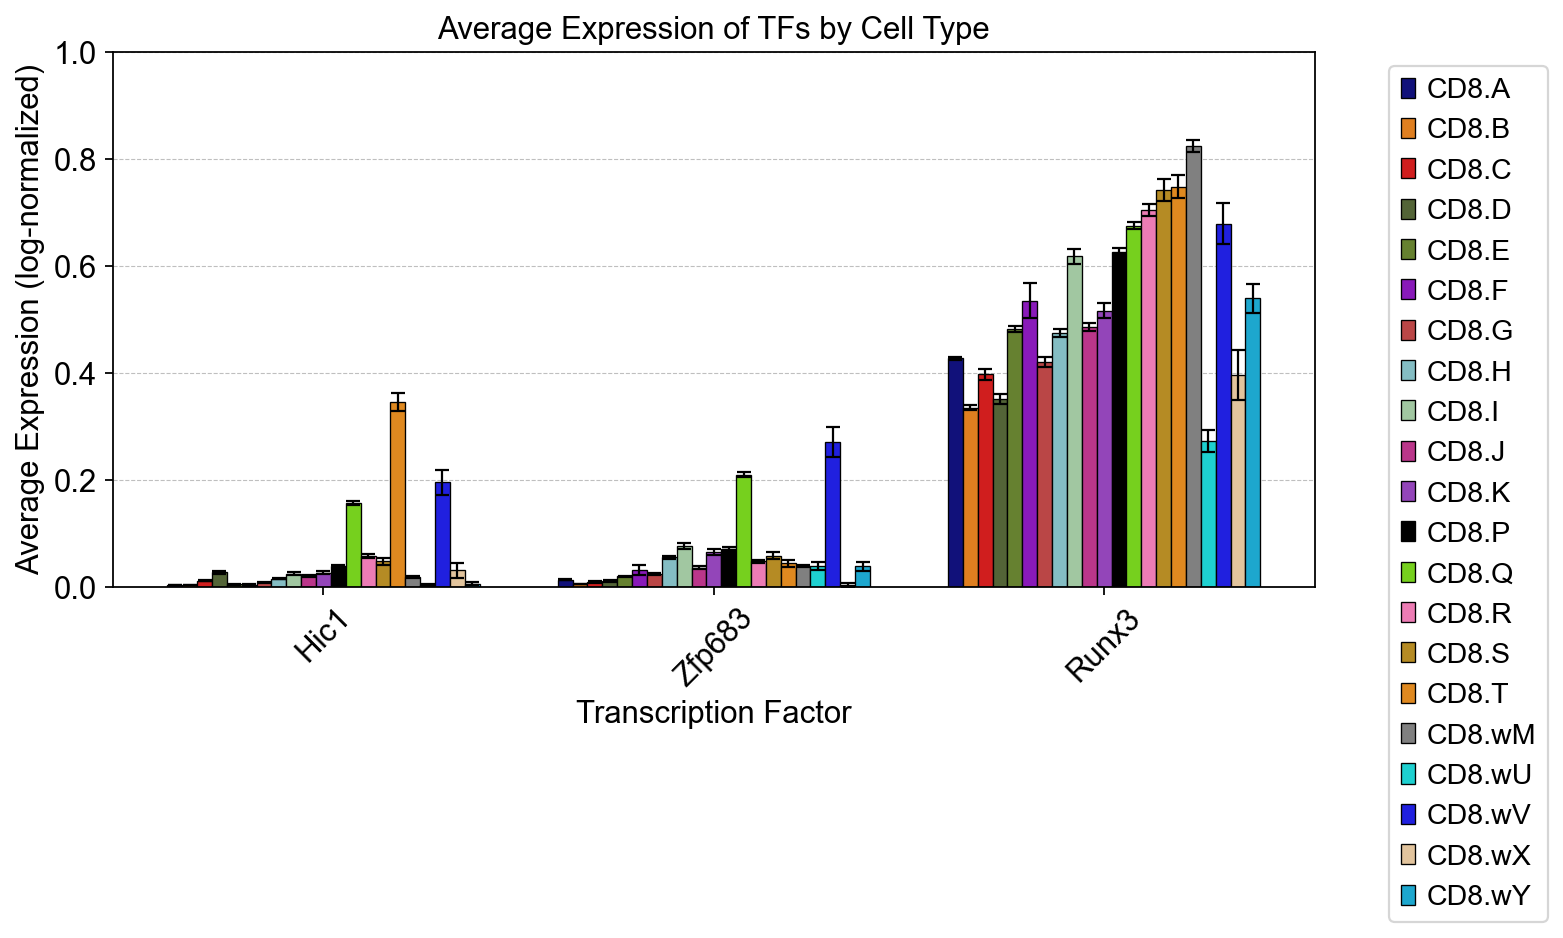

In [73]:
# Extended Data Fig. 4f - Transcription factor expression
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Melt mean and SEM
mean_long = mean_expr.reset_index().melt(
    id_vars='cell_type', var_name='Gene', value_name='Expression'
)

sem_long = sem_expr.reset_index().melt(
    id_vars='cell_type', var_name='Gene', value_name='SEM'
)

# 2. Merge them
plot_df = mean_long.merge(sem_long, on=['cell_type', 'Gene'])

# 3. Plot
plt.figure(figsize=(10, 5.5))
ax = sns.barplot(
    data=plot_df,
    x='Gene',
    y='Expression',
    hue='cell_type',
    palette=custom_colors,
    errorbar=None,          # we will add error bars ourselves
    edgecolor='black',
    linewidth=0.6
)

# 4. Add pre-computed SEM error bars
# Get the grouped bars
n_genes = len(genes)
n_celltypes = len(plot_df['cell_type'].unique())
bar_width = 0.8 / n_celltypes

for i, gene in enumerate(genes):
    gene_data = plot_df[plot_df['Gene'] == gene]
    
    for j, (_, row) in enumerate(gene_data.iterrows()):
        # Approximate x position of each bar
        x = i + (j - n_celltypes/2) * bar_width + bar_width/2
        ax.errorbar(
            x=x,
            y=row['Expression'],
            yerr=row['SEM'],
            fmt='none',
            c='black',
            capsize=3,
            elinewidth=1
        )

# Styling
plt.title('Average Expression of TFs by Cell Type')
plt.ylabel('Average Expression (log-normalized)')
plt.xlabel('Transcription Factor')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.savefig('Extended_Data_Fig_4f.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

Loaded Excel file with 688 rows and 94 columns.
After target_cells filters: 634 rows remain.
After excluding KbDb conditions: 622 rows remain.
After excluding baseline: 365 rows remain.
After aggregating replicates: 181 unique conditions.
After ≥ 10 cells (averaged) in at least one cluster: 87 conditions remain.
Selected top 50 unique conditions by average combined proportion.


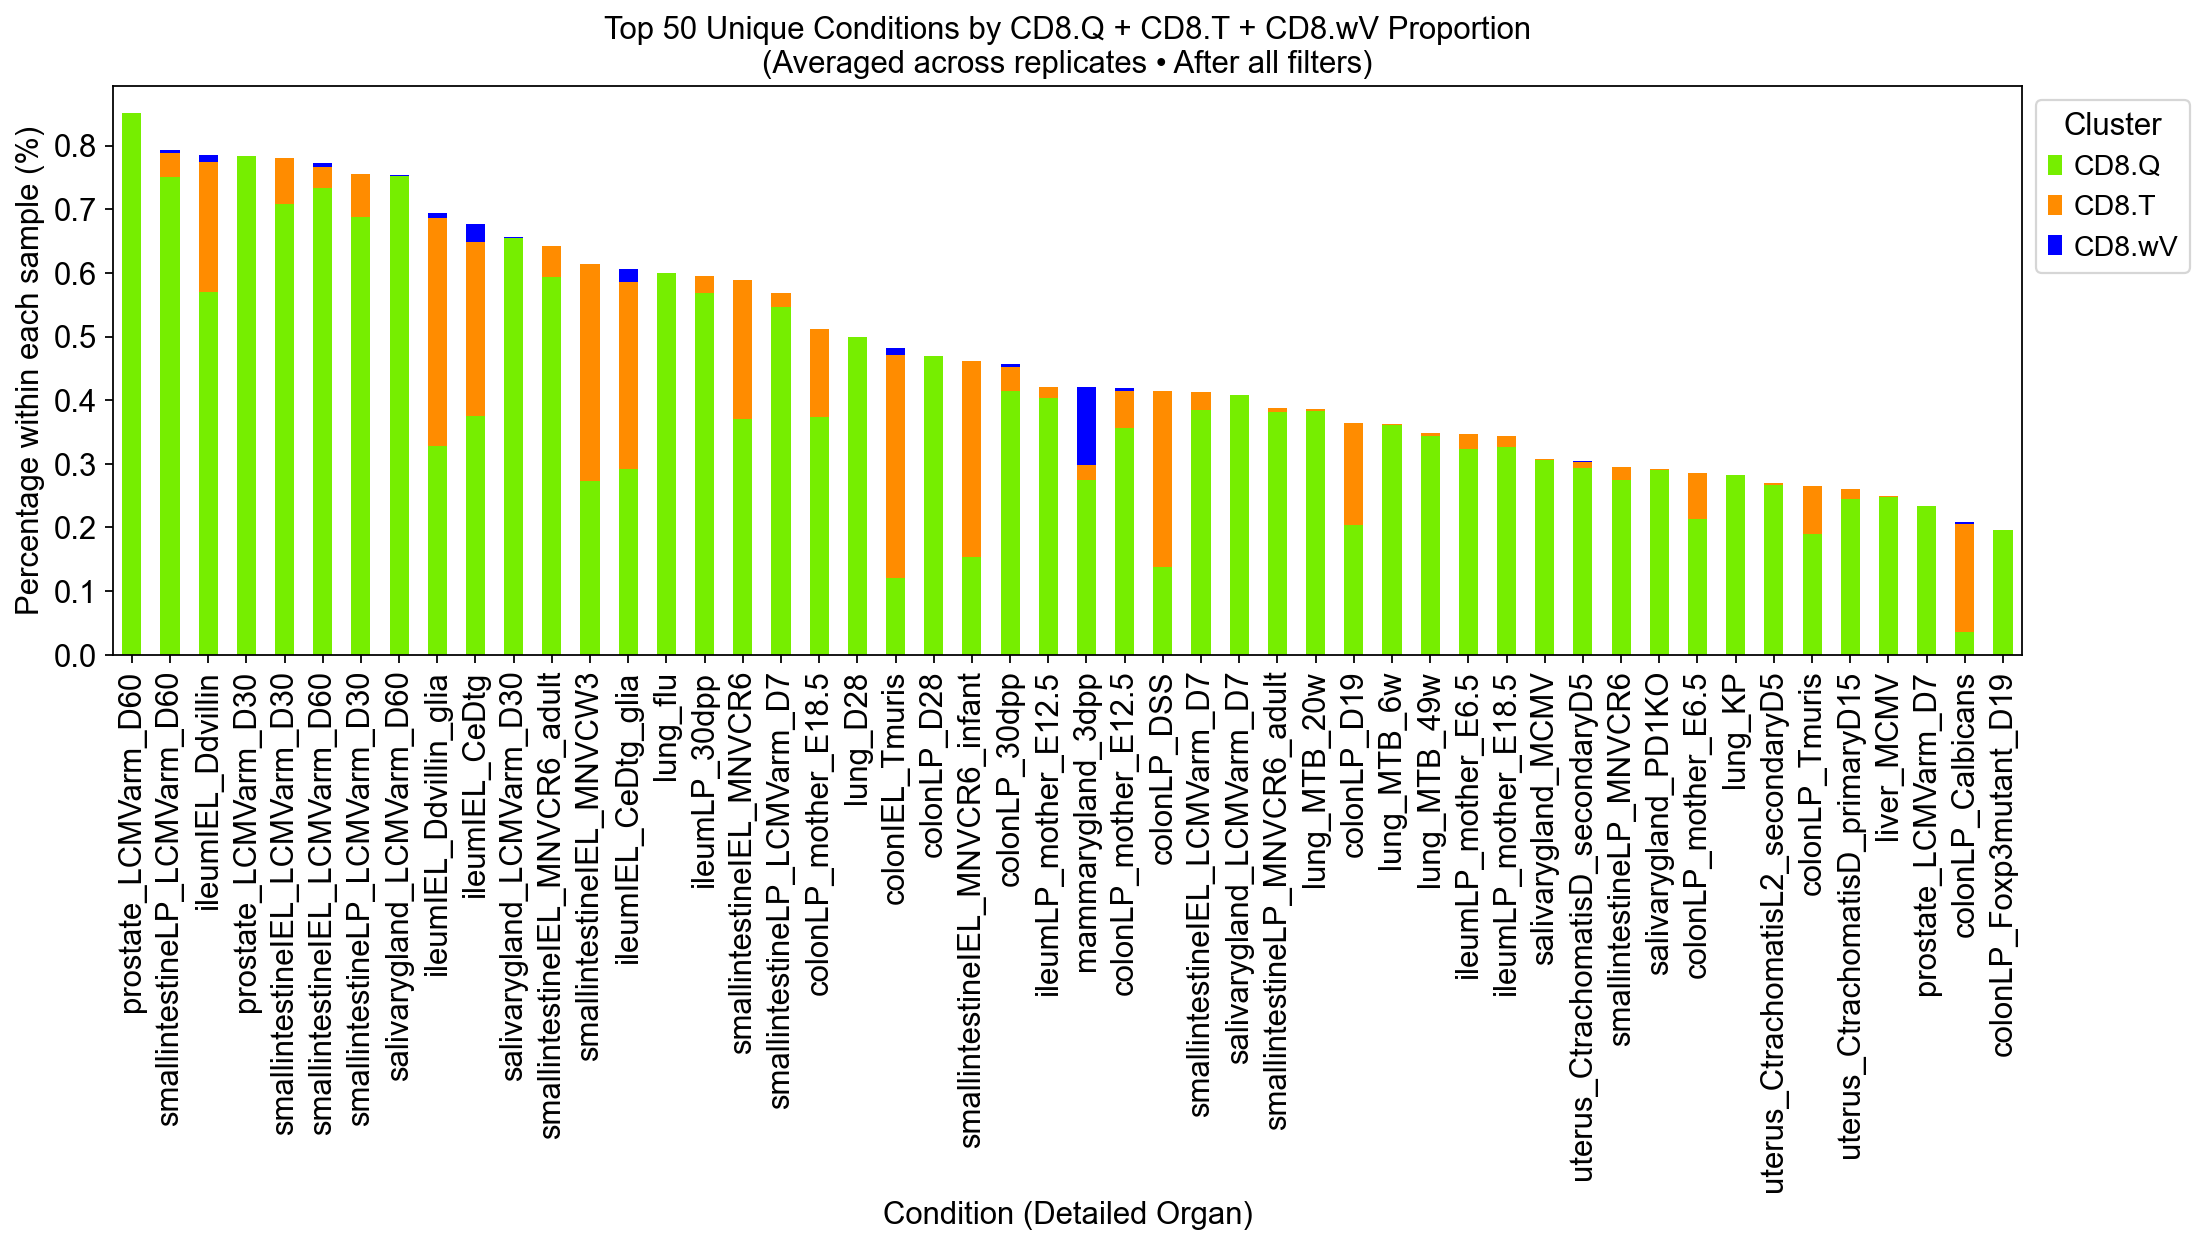

Stacked bar plot saved: Extended_Data_Fig_4g.pdf

Top 10 unique conditions:
          condition_detailed_organ  total_prop  CD8.Q.ncells  CD8.T.ncells  \
92            prostate_LCMVarm_D60    0.851419         510.0           0.0   
120   smallintestineLP_LCMVarm_D60    0.792531         181.0           9.0   
54               ileumIEL_Ddvillin    0.785536          97.5          35.0   
91            prostate_LCMVarm_D30    0.784071         443.0           0.0   
110  smallintestineIEL_LCMVarm_D30    0.780303         187.0          19.0   
111  smallintestineIEL_LCMVarm_D60    0.772222         132.0           6.0   
119   smallintestineLP_LCMVarm_D30    0.754839         213.0          21.0   
95       salivarygland_LCMVarm_D60    0.753747         702.0           0.0   
55          ileumIEL_Ddvillin_glia    0.694284          33.5          40.5   
52                  ileumIEL_CeDtg    0.676404          30.5          14.5   

     CD8.wV.ncells  CD8.Q.prop  CD8.T.prop  CD8.wV.prop  
92     

In [74]:
# Extended Data Fig. 4g - CD8.Q, T, wV frequency across samples
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = 'data/immgenT-CD8.xlsx'
df = pd.read_excel(file_path)

print(f"Loaded Excel file with {df.shape[0]} rows and {df.shape[1]} columns.")

# Define columns
prop_cols = ['CD8.Q.prop', 'CD8.T.prop', 'CD8.wV.prop']
ncells_cols = ['CD8.Q.ncells', 'CD8.T.ncells', 'CD8.wV.ncells']

# === FILTERS (applied on original rows before averaging) ===
if 'target_cells' in df.columns:
    df = df[~df['target_cells'].str.contains('CD4\+ CD44\+', case=False, na=False)].copy()
    unwanted = ['Treg', 'CD4+ T', 'DN', 'DO11.10 KJ1-26', 'OT2', 'TCRBV-TCRGD', 'TFH',
                'Vd6b F4.22', 'Vg4 49.2', 'Vg6 1C10', 'Vg7 F2.67', 'thymocytes']
    mask = df['target_cells'].isin(unwanted) | df['target_cells'].str.contains('|'.join(unwanted), case=False, na=False)
    df = df[~mask].copy()
    print(f"After target_cells filters: {df.shape[0]} rows remain.")

# Exclude KO conditions
exclude_conditions = ['KbDbKO', 'KbDbQa1KO', 'KbDbQa1KO_MCMV']
exclude_mask = df['condition_detailed_organ'].str.contains('|'.join(exclude_conditions), case=False, na=False)
df = df[~exclude_mask].copy()
print(f"After excluding KbDb conditions: {df.shape[0]} rows remain.")

# Exclude baseline
if 'condition_detailed_simplified' in df.columns:
    df = df[df['condition_detailed_simplified'] != 'baseline'].copy()
    print(f"After excluding baseline: {df.shape[0]} rows remain.")

# === AGGREGATE REPLICATES (Group by condition_detailed_organ) ===
group_cols = ['condition_detailed_organ']

agg_dict = {col: 'mean' for col in prop_cols + ncells_cols}
if 'target_cells' in df.columns:
    agg_dict['target_cells'] = 'first'   # keep one value for reference

df_agg = df.groupby(group_cols, as_index=False).agg(agg_dict)

print(f"After aggregating replicates: {df_agg.shape[0]} unique conditions.")

# === FILTER on averaged ncells: ≥10 in at least one cluster ===
min_cells = 10
valid_mask = (df_agg['CD8.Q.ncells'] >= min_cells) | \
             (df_agg['CD8.T.ncells'] >= min_cells) | \
             (df_agg['CD8.wV.ncells'] >= min_cells)

df_filtered = df_agg[valid_mask].copy()
print(f"After ≥ {min_cells} cells (averaged) in at least one cluster: {df_filtered.shape[0]} conditions remain.")

# Calculate total proportion for ranking
df_filtered['total_prop'] = df_filtered[prop_cols].sum(axis=1)
df_filtered = df_filtered[df_filtered['total_prop'] > 0].copy()

# Select top 50 unique conditions
df_top50 = df_filtered.nlargest(50, 'total_prop')

print(f"Selected top 50 unique conditions by average combined proportion.")

# Prepare for plotting
freq_table = df_top50[prop_cols].copy()
freq_table.index = df_top50['condition_detailed_organ']
freq_table.columns = ['CD8.Q', 'CD8.T', 'CD8.wV']

# Plot using your pre-existing custom_colors
fig, ax = plt.subplots(figsize=(14, 8))
freq_table.plot(kind='bar', stacked=True, ax=ax, 
                color=[custom_colors[col] for col in freq_table.columns])

ax.set_xlabel('Condition (Detailed Organ)')
ax.set_ylabel('Percentage within each sample (%)')
ax.set_title('Top 50 Unique Conditions by CD8.Q + CD8.T + CD8.wV Proportion\n(Averaged across replicates • After all filters)')
ax.grid(False)
ax.legend(title='Cluster', bbox_to_anchor=(1, 1), loc='upper left')

plt.xticks(rotation=90, ha='center')
plt.tight_layout()

# Save
plt.savefig('Extended_Data_Fig_4g.pdf', bbox_inches='tight')
plt.show()
plt.close()

print("Stacked bar plot saved: Extended_Data_Fig_4g.pdf")

# Preview
print("\nTop 10 unique conditions:")
print(df_top50[['condition_detailed_organ', 'total_prop'] + ncells_cols + prop_cols].head(10))


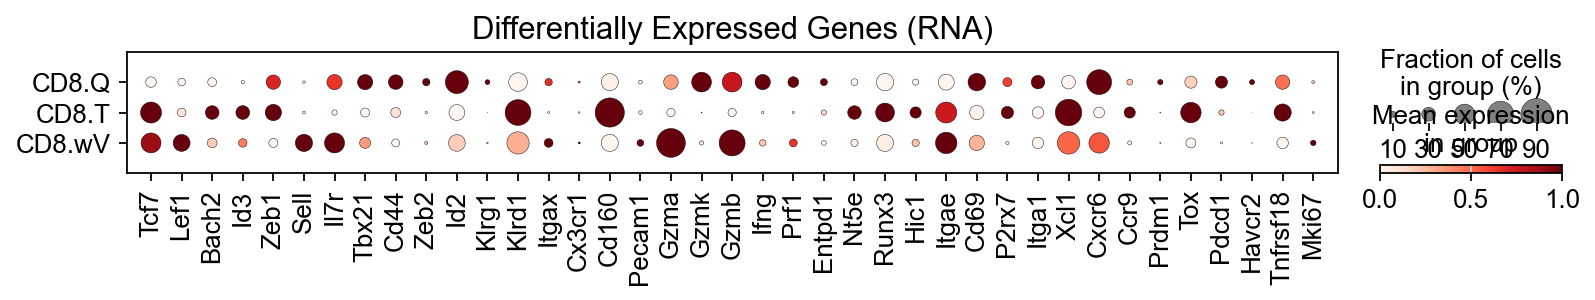

Plot saved: Extended_Data_Fig_4h.pdf


In [75]:
# Extended Data Fig. 4h - Dot plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc  # Explicitly import scanpy for clarity

# Define selected genes
selected_genes = ["Tcf7", "Lef1", "Bach2", "Id3", "Zeb1", "Sell", "Il7r", "Tbx21", "Cd44", "Zeb2",
                  "Id2", "Klrg1", "Klrd1", "Itgax", "Cx3cr1", "Cd160", "Pecam1", "Gzma", "Gzmk",
                  "Gzmb", "Ifng", "Prf1", "Entpd1", "Nt5e", "Runx3", "Hic1", "Itgae", "Cd69",
                  "P2rx7", "Itga1", "Xcl1", "Cxcr6", "Ccr9", "Prdm1", "Tox", "Pdcd1", "Havcr2",
                  "Tnfrsf18", "Mki67"]

# Subset mdata['RNA'] to include only clusters CD8.Q, CD8.T, and CD8.wV
subset_adata = mdata['RNA'][mdata['RNA'].obs['cluster_annotation'].isin(['CD8.Q', 'CD8.T', 'CD8.wV']), :]

# Create dot plot with the subsetted data
sc.pl.dotplot(subset_adata, var_names=list(selected_genes), groupby='cluster_annotation',
              use_raw=False,  # Set to True if .X is raw and you have .raw
              cmap='Reds',    # Color map for expression
              title='Differentially Expressed Genes (RNA)',
              standard_scale='var',  # Scale by variable (gene)
              figsize=(11.5, 1),      # Try passing figsize directly
              show=False)
plt.savefig('Extended_Data_Fig_4h.pdf', format='pdf', bbox_inches='tight')
plt.show()
plt.close()
print('Plot saved: Extended_Data_Fig_4h.pdf')


# Extended Data Fig. 5

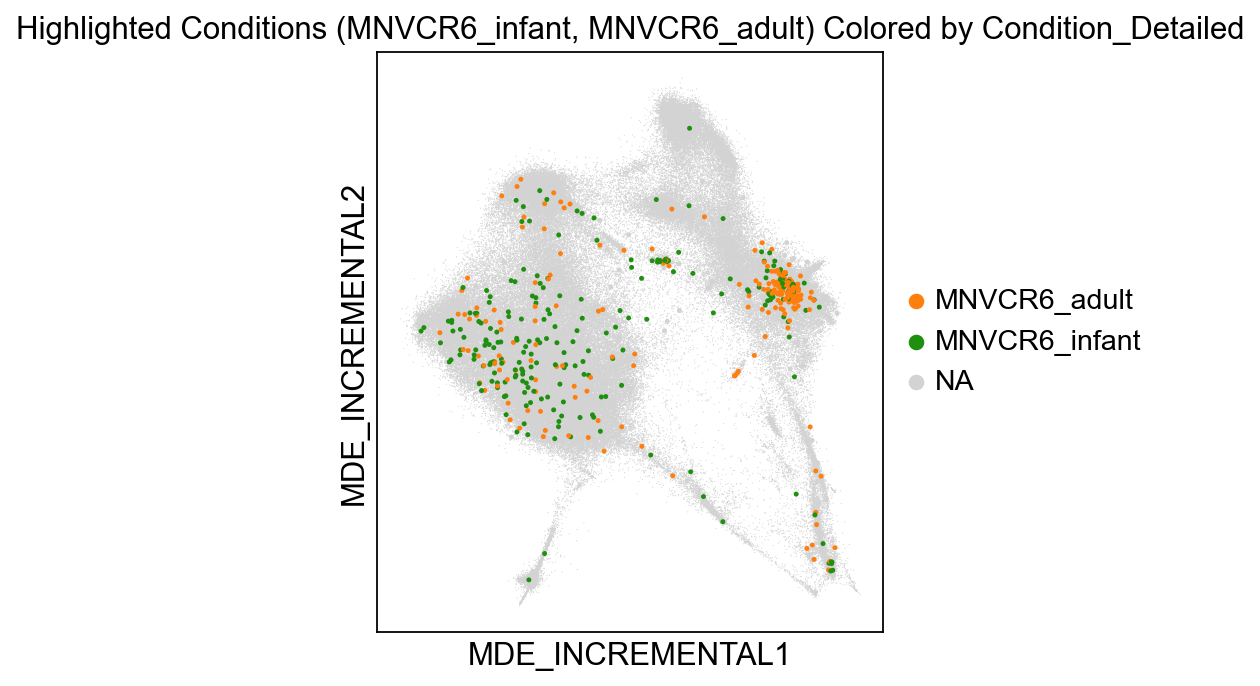

Plot saved: Extended_Data_Fig_5c.pdf


In [77]:
# Extended Data Fig. 5c — MNVCR6 MDE plots
color_palette = {
    'MNVCR6_infant': "#1e8f0f",  # Blue
    'MNVCR6_adult': '#ff7f0e',    # Orange
    'MNVCR6': '#d3d3d3'          # Gray for other categories (e.g., MNVCR6)
    # Add other categories in condition_detailed if necessary
}

# Filter for IGT == IGT26, IGT79, IGT80 and condition_broad == 'virus'
subset_conditions = rna[
    (rna.obs['IGT'].isin(['IGT26', 'IGT79', 'IGT80'])) & 
    (rna.obs['condition_broad'] == 'virus') &
    (rna.obs['condition_detailed_organ'].str.contains('MNVCR6', na=False))
].copy()

# Create figure and axis
fig, ax = plt.subplots(figsize=(5.5, 4.5))

# Plot all cells in gray as background
sc.pl.embedding(
    rna,
    basis='MDE_INCREMENTAL',
    color='condition_broad',
    palette=['#d3d3d3'],  # Gray color for all cells
    size=1,  # Smaller point size for background
    show=False,
    ax=ax,
    legend_loc=None  # Remove legend
)

# Overlay cells from specified conditions
sc.pl.embedding(
    subset_conditions,
    basis='MDE_INCREMENTAL',
    color='condition_detailed',  # Color by condition_detailed
    groups=['MNVCR6_adult', 'MNVCR6_infant'],  # Ensure only specified conditions are colored
    palette=color_palette,  # Use defined color palette
    title='Highlighted Conditions (MNVCR6_infant, MNVCR6_adult) Colored by Condition_Detailed',
    legend_loc='right margin',
    size=20,  # Larger point size for foreground
    show=False,
    ax=ax
)

# Save and show the plot
plt.tight_layout()
plt.savefig("Extended_Data_Fig_5c.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Plot saved: Extended_Data_Fig_5c.pdf")


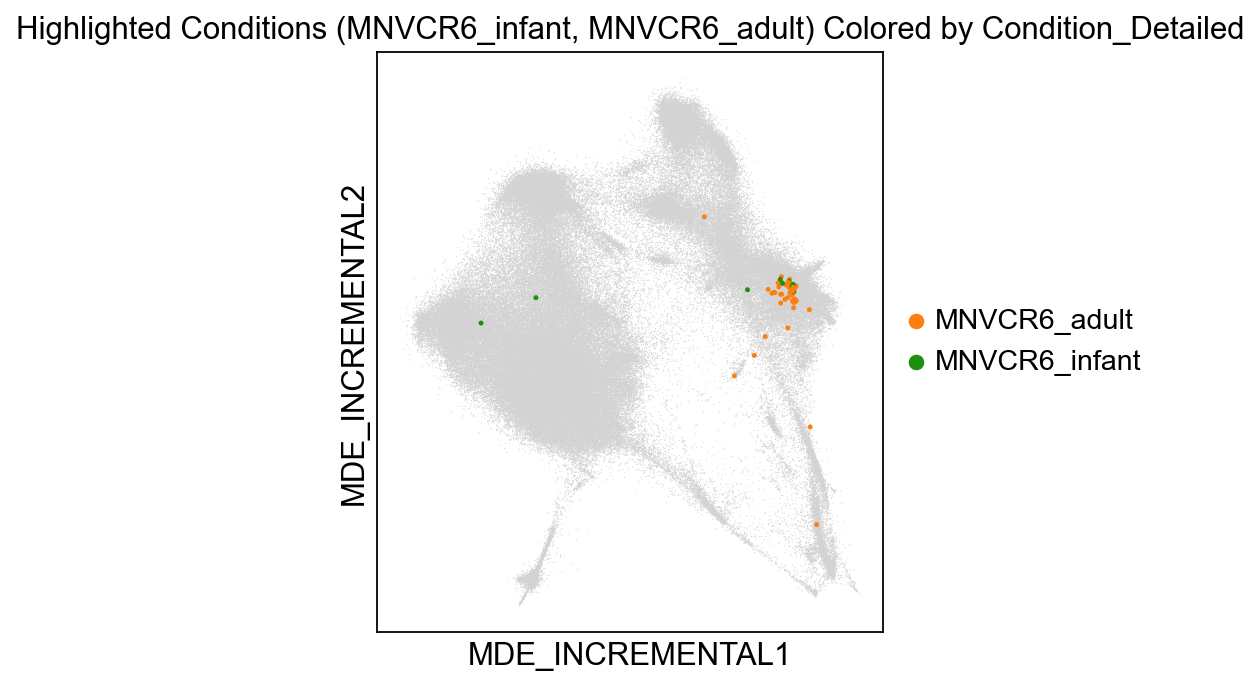

Plot saved: Extended_Data_Fig_5c_v2.pdf


In [78]:
# Extended Data Fig. 5c — MNVCR6 MDE plots
color_palette = {
    'MNVCR6_infant': "#1e8f0f",  # Green
    'MNVCR6_adult': '#ff7f0e',    # Orange
    'MNVCR6': '#d3d3d3'          # Gray for other categories (e.g., MNVCR6)
    # Add other categories in condition_detailed if necessary
}

# Filter for IGT == IGT26, IGT79, IGT80 and condition_broad == 'virus'
subset_conditions = rna[
    (rna.obs['IGT'].isin(['IGT26', 'IGT79', 'IGT80'])) & 
    (rna.obs['condition_broad'] == 'virus') &
    (rna.obs['condition_detailed_organ'].str.contains('MNVCR6', na=False)) &
    (rna.obs['Ag_spe_v1'] == 'VP1Tetp')
].copy()

# Create figure and axis
fig, ax = plt.subplots(figsize=(5.5, 4.5))

# Plot all cells in gray as background
sc.pl.embedding(
    rna,
    basis='MDE_INCREMENTAL',
    color='condition_broad',
    palette=['#d3d3d3'],  # Gray color for all cells
    size=1,  # Smaller point size for background
    show=False,
    ax=ax,
    legend_loc=None  # Remove legend
)

# Overlay cells from specified conditions
sc.pl.embedding(
    subset_conditions,
    basis='MDE_INCREMENTAL',
    color='condition_detailed',  # Color by condition_detailed
    groups=['MNVCR6_adult', 'MNVCR6_infant'],  # Ensure only specified conditions are colored
    palette=color_palette,  # Use defined color palette
    title='Highlighted Conditions (MNVCR6_infant, MNVCR6_adult) Colored by Condition_Detailed',
    legend_loc='right margin',
    size=20,  # Larger point size for foreground
    show=False,
    ax=ax
)

# Save and show the plot
plt.tight_layout()
plt.savefig("Extended_Data_Fig_5c_v2.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Plot saved: Extended_Data_Fig_5c_v2.pdf")


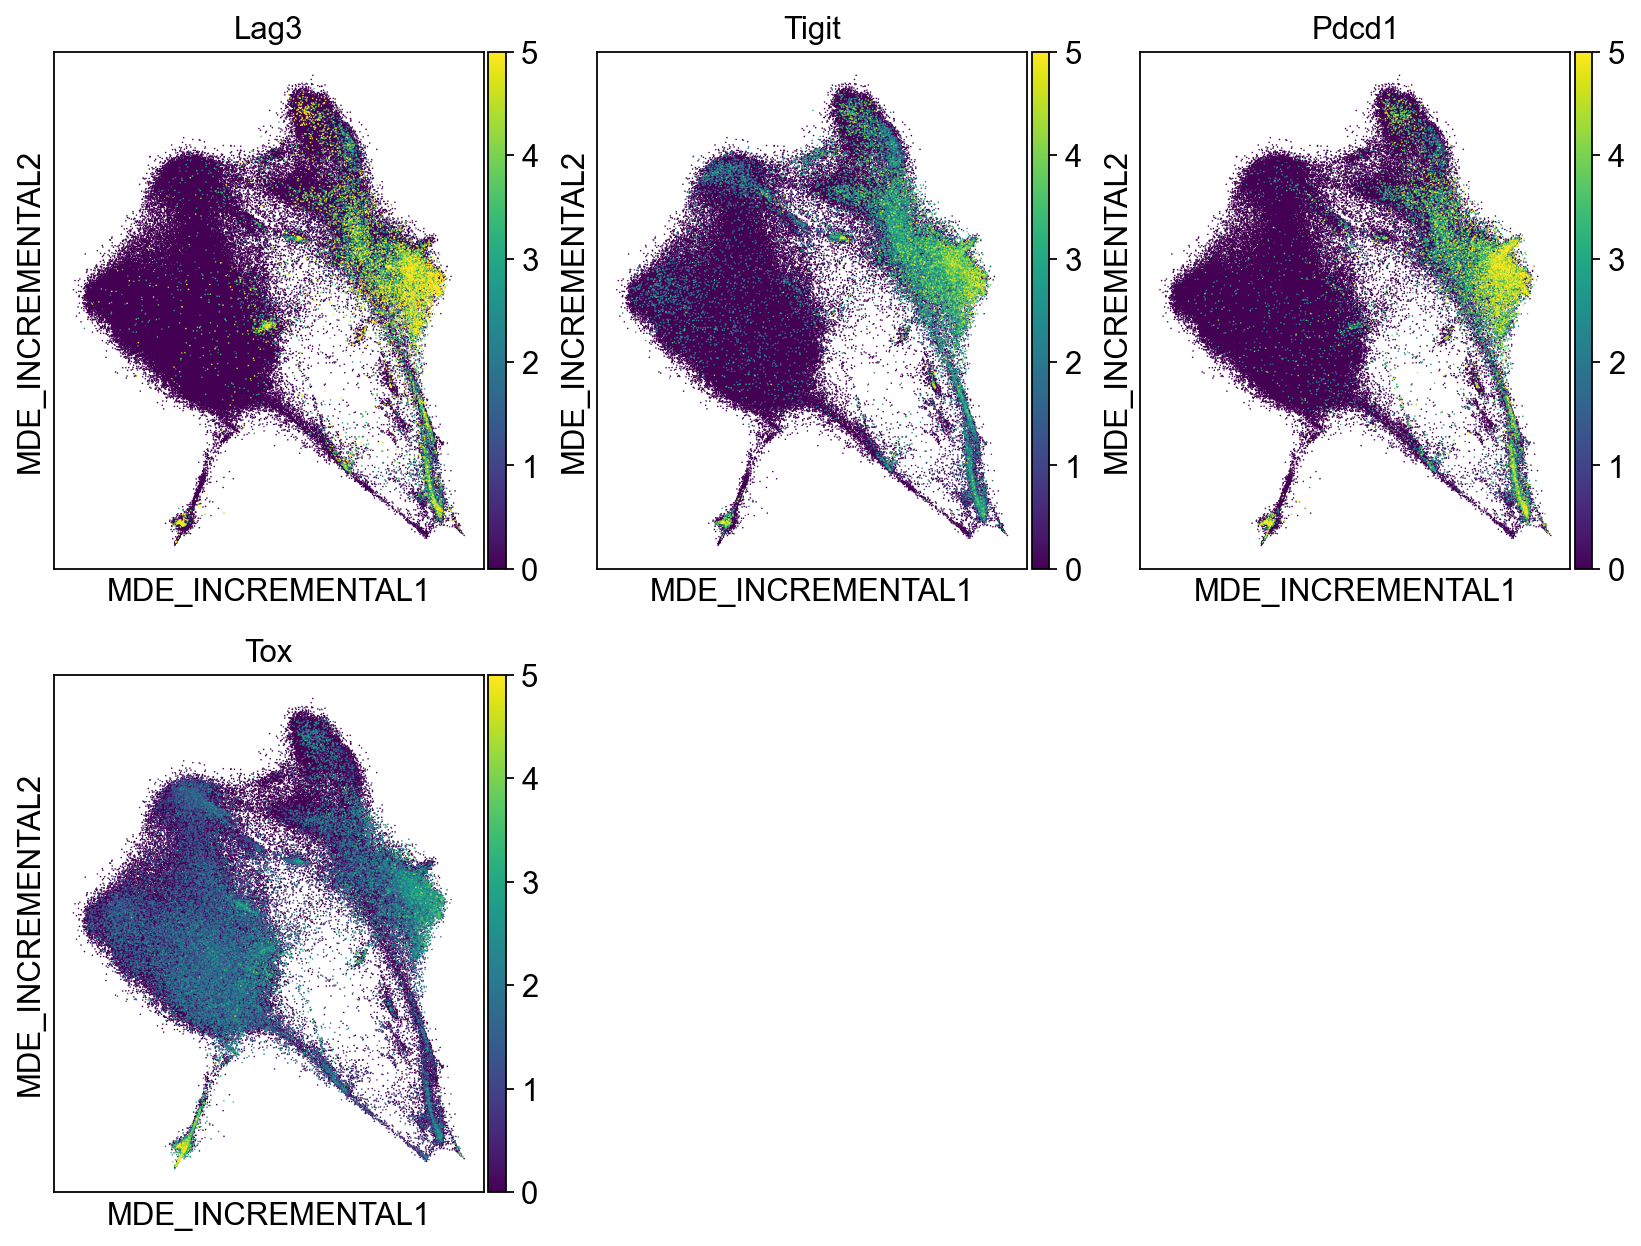

Plot saved: Extended_Data_Fig_5d.pdf


In [79]:
# Extended Data Fig. 5d - Feature plots
import matplotlib.pyplot as plt
import numpy as np
import muon as mu

# Set up embedding plot
with plt.rc_context():
    # ← ONLY THIS LINE CHANGED (your 6 genes)
    genes = ["Lag3", "Tigit", "Pdcd1", "Tox"]
    
    # ← Updated to match the 6 genes (one entry per gene)
    legend_locs = ["right margin"] * len(genes)   # all colorbars on the right
    
    # ← Your preferred fixed scale (same as original Cd44/Sell example)
    vmin_values = [0] * len(genes)    # all start at 0
    vmax_values = [5] * len(genes)    # all capped at 5 (you liked this before)

    # Editable figure size parameters
    base_width = 3.5   # Base width per column
    base_height = 4    # Base height per row

    # Calculate subplot grid size dynamically
    n_plots = len(genes)
    n_cols = 3         # ← Changed to 3 columns → perfect 2×3 grid for 6 genes
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_width * n_cols, base_height * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    # ← Only this loop was kept exactly as you wrote it
    for ax, gene, legend_loc, vmin, vmax in zip(axes, genes, legend_locs, vmin_values, vmax_values):
        mu.pl.embedding(
            mdata['RNA'],
            basis="MDE_INCREMENTAL",
            color=gene,
            cmap="viridis",         # kept your original cmap
            legend_loc=legend_loc,  # colorbar on right margin
            ax=ax,
            size=2,                 # kept your original small dot size
            vmin=vmin,
            vmax=vmax,
            show=False,
        )

    # Remove unused subplots (none in this case, but kept for safety)
    for ax in axes[n_plots:]:
        fig.delaxes(ax)

    plt.tight_layout(w_pad=0.55)
    plt.savefig("Extended_Data_Fig_5d.pdf", bbox_inches="tight")  # ← changed filename to match your figure
    plt.show()
    plt.close()
    print("Plot saved: Extended_Data_Fig_5d.pdf")


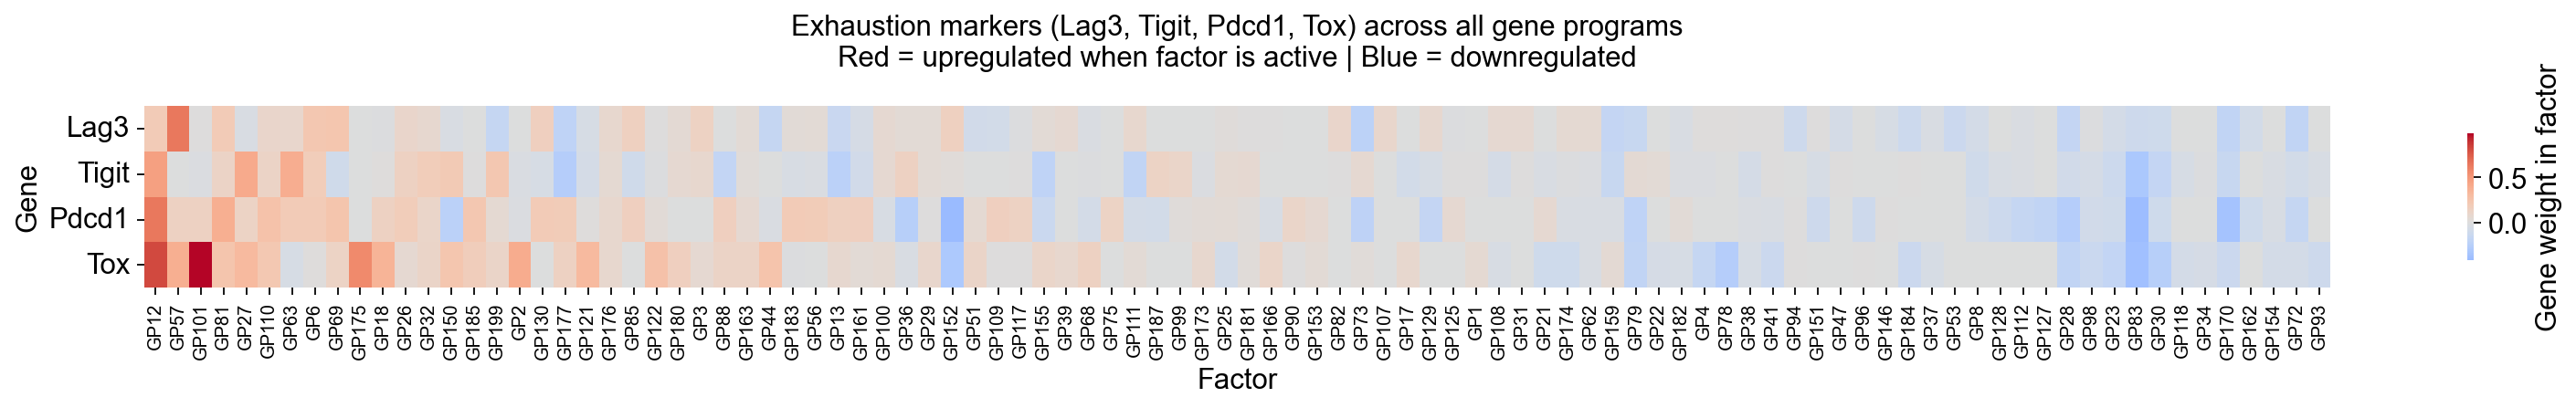

Saved heatmap with GP labels → Extended_Data_Fig_5e.pdf


In [80]:
# Extended Data Fig. 5e — exhaustion markers across gene programs
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Load the gene x factor matrix
# ------------------------------------------------------------------
F_df = pd.read_csv(
    "data/gene_factor_matrix.txt",
    sep="\t",
    index_col=0
)
F_df.index = F_df.index.astype(str).str.strip()

# ------------------------------------------------------------------
# Markers
# ------------------------------------------------------------------
marker_genes = ["Lag3", "Tigit", "Pdcd1", "Tox"]
available = [g for g in marker_genes if g in F_df.index]
data = F_df.loc[available]

# ------------------------------------------------------------------
# Optional: only keep factors with decent signal
# ------------------------------------------------------------------
min_abs_weight = 0.05
has_signal = (data.abs() > min_abs_weight).any(axis=0)
data = data.loc[:, has_signal]

# ------------------------------------------------------------------
# Sort by exhaustion strength
# ------------------------------------------------------------------
exhaustion_score = data.clip(lower=0).mean()
data = data[exhaustion_score.sort_values(ascending=False).index]

# THIS IS THE ONLY NEW LINE — replaces "V" with "GP" in column names
data.columns = data.columns.str.replace(r'^V', 'GP', regex=True)

# ------------------------------------------------------------------
# Plot!
# ------------------------------------------------------------------
plt.figure(figsize=(20, 3))
cmap = "coolwarm"

ax = sns.heatmap(
    data,
    cmap=cmap,
    center=0,
    annot=False,
    cbar_kws={"label": "Gene weight in factor", "shrink": 0.7},
    yticklabels=data.index,
    xticklabels=data.columns
)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=9)

plt.title("Exhaustion markers (Lag3, Tigit, Pdcd1, Tox) across all gene programs\n"
          "Red = upregulated when factor is active | Blue = downregulated",
          fontsize=14, pad=20)
plt.ylabel("Gene")
plt.xlabel("Factor")
ax.grid(False)

plt.tight_layout()
plt.savefig("Extended_Data_Fig_5e.pdf", bbox_inches='tight', dpi=300)
plt.show()

print("Saved heatmap with GP labels → Extended_Data_Fig_5e.pdf")


In [81]:
# Extended Data Fig. 5f — exhaustion markers across gene programs
import pandas as pd

# ============================= USER SETTINGS =============================
marker_genes = ["Lag3", "Tigit", "Pdcd1", "Tox"]   # change/add genes here if you want
min_positive_weight = 0.08                         # threshold for "positive"
min_markers = 4                                    # ←←← CHANGE ONLY THIS NUMBER (1 to 4)
# ======================================================================

# Load matrix
F_df = pd.read_csv(
    "data/gene_factor_matrix.txt",
    sep="\t",
    index_col=0
)
F_df.index = F_df.index.astype(str).str.strip()

# Check which markers exist
available = [g for g in marker_genes if g in F_df.index]
missing   = [g for g in marker_genes if g not in F_df.index]

print("Available markers :", available)
if missing:
    print("Missing markers   :", missing)

if len(available) == 0:
    raise ValueError("None of the marker genes were found!")

# Boolean mask: True if weight > threshold
mask = F_df.loc[available] > min_positive_weight

# Count how many markers are positive per factor
n_positive_per_factor = mask.sum(axis=0)   # <-- key line

# Apply the user-defined minimum
selected = n_positive_per_factor >= min_markers
selected_factors = selected[selected].index.tolist()

print(f"\n→ Found {len(selected_factors)} factor(s) with "
      f"at least {min_markers}/{len(available)} markers > {min_positive_weight}")
print("Factors:", ", ".join(sorted(selected_factors)) if selected_factors else "None")

# Show detailed table
if selected_factors:
    detail_df = F_df.loc[available, selected_factors].round(4)
    
    # Sort by total positive score (nice order)
    detail_df = detail_df.loc[:, detail_df.sum().sort_values(ascending=False).index]
    
    print(f"\nPrograms with ≥{min_markers} positive exhaustion markers:")
    print(detail_df)
    
    # Save
    filename = f"Extended_Data_Fig_5f_exhaustion_min_{min_markers}_of_{len(available)}_markers_positive.tsv"
    detail_df.to_csv(filename, sep="\t")
    print(f"\nSaved → {filename}")
else:
    print(f"\nNo factor found with ≥{min_markers} markers above {min_positive_weight}.")
    print("Try lowering min_positive_weight or min_markers.")


Available markers : ['Lag3', 'Tigit', 'Pdcd1', 'Tox']

→ Found 3 factor(s) with at least 4/4 markers > 0.08
Factors: V110, V12, V81

Programs with ≥4 positive exhaustion markers:
          V12     V81    V110
Lag3   0.1991  0.1980  0.0962
Tigit  0.4556  0.1255  0.1224
Pdcd1  0.6402  0.3804  0.2615
Tox    0.8181  0.2442  0.2184

Saved → Extended_Data_Fig_5f_exhaustion_min_4_of_4_markers_positive.tsv


Plotting stacked activity for: ['F12', 'F81', 'F110']


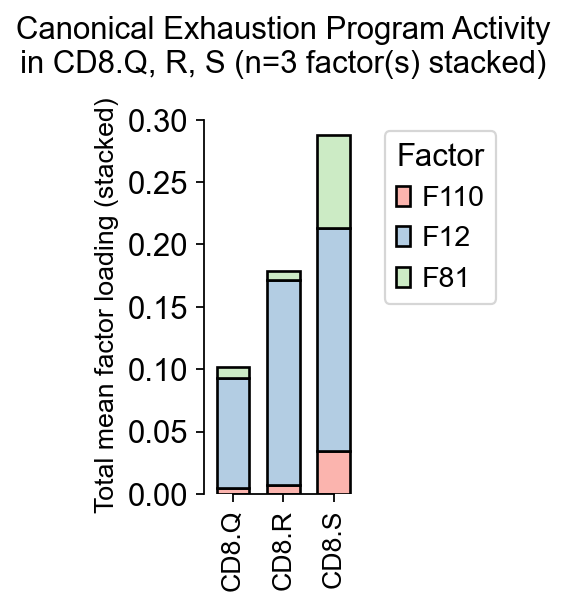

In [82]:
# Extended Data Fig. 5f — exhaustion GP across clusters
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

# -------------------------- USER SETTINGS --------------------------
cluster_column = "cluster_annotation"
cell_id_column = None  # auto-detect below
clusters_to_show = ["CD8.Q", "CD8.R", "CD8.S"]
# -----------------------------------------------------------------

# Load cell × factor matrix
L_df = pd.read_csv(
    "data/cell_factor_matrix.txt.gz",
    sep="\t",
    index_col=0,
    compression="gzip"
)

# Load annotations
obs = mdata['RNA'].obs

# Auto-detect cell ID column
if 'cellID' in obs.columns:
    cell_id_col = 'cellID'
elif 'IGT_cellID' in obs.columns:
    cell_id_col = 'IGT_cellID'
else:
    raise KeyError("No known cell ID column found!")

cell_to_cluster = obs.set_index(cell_id_col)[cluster_column]

# Align with L matrix
common_cells = L_df.index.intersection(cell_to_cluster.index)
L_df = L_df.loc[common_cells]
cell_to_cluster = cell_to_cluster.loc[common_cells]

# ------------------- Match selected factors robustly -------------------
def get_factor_number(name):
    match = re.search(r'\d+', str(name))
    return int(match.group()) if match else -1

selected_nums = [get_factor_number(f) for f in selected_factors]
L_cols_nums = [get_factor_number(c) for c in L_df.columns]

matched_factors = []
for num in selected_nums:
    cols = [c for c, n in zip(L_df.columns, L_cols_nums) if n == num]
    if cols:
        matched_factors.append(cols[0])
    else:
        print(f"Warning: Factor ~{num} not found in L matrix")

if not matched_factors:
    raise ValueError("No selected factors found in cell loading matrix!")

print(f"Plotting stacked activity for: {matched_factors}")

# ------------------- Compute mean loading per cluster -------------------
plot_data = []
for factor in matched_factors:
    for cluster in clusters_to_show:
        if cluster not in cell_to_cluster.values:
            continue
        cells_in_cluster = cell_to_cluster[cell_to_cluster == cluster].index
        mean_load = L_df.loc[cells_in_cluster, factor].mean()
        plot_data.append({
            "Cluster": cluster,
            "Factor": factor,
            "Mean Loading": mean_load
        })

df = pd.DataFrame(plot_data)

# Pivot for stacked plot
df_pivot = df.pivot(index="Cluster", columns="Factor", values="Mean Loading").fillna(0)
df_pivot = df_pivot.loc[clusters_to_show]  # enforce order

# ------------------- Stacked barplot -------------------
plt.figure(figsize=(3, 4))
colors = sns.color_palette("Pastel1", n_colors=len(matched_factors))  # try also: Pastel2, Set2, Set3, husl

df_pivot.plot(
    kind="bar",
    stacked=True,
    color=colors,
    edgecolor="black",
    linewidth=1.2,
    width=0.65,
    ax=plt.gca()
)

plt.title(f"Canonical Exhaustion Program Activity\n"
          f"in CD8.Q, R, S (n={len(matched_factors)} factor(s) stacked)",
          fontsize=14, pad=20)
plt.xlabel("")
plt.ylabel("Total mean factor loading (stacked)", fontsize=12)
plt.legend(title="Factor", bbox_to_anchor=(1.05, 1), loc="upper left")

# THIS LINE MAKES X LABELS VERTICAL
plt.xticks(rotation=90, fontsize=12)

plt.grid(False)
sns.despine(trim=True)

plt.tight_layout()
plt.savefig("Extended_Data_Fig_5f.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [83]:
# Extended Data Fig. 5g-i - Volcano plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from adjustText import adjust_text

# Define custom colors for clusters
custom_colors = {
    'CD8.R': '#FF69B4',   # pink2 (hotpink)
    'CD8.Q': '#76EE00',  # chartreuse2
    'CD8.S': '#CD950C',  # darkgoldenrod2
}

def plot_volcano(
    signature_file,
    cluster,
    pval_threshold=0.05,
    log2fc_threshold=0.5,
    non_highlight_size=1,
    highlight_size=5,
    label_top_n=10,
    figsize=(5, 5),
    save_path=None,
    highlight_gene_column='SYMBOL',
    xlim_min=-3,
    xlim_max=4,
    highlight_genes=None,
    highlight_label=None,
    extra_label_genes=None
):
    """
    Generate a volcano plot from a signature DataFrame for a specific cluster with staggered gene labels.
    Labels the top 10 up-regulated and top 10 down-regulated significant genes (based on pval and log2FC thresholds).
    Optionally highlights genes from an external list.
    Optionally labels user-specified genes in red (extra_label_genes).
    """
    if extra_label_genes is None:
        extra_label_genes = []

    # Load the signature DataFrame
    signature_df = pd.read_csv(signature_file, sep='\t', encoding='utf-8')

    # Prepare data for volcano plot
    log2fc_col = f'log2FC_{cluster}_vs_All'
    pval_col = f'adj.P.Val_{cluster}_vs_All'

    plot_df = signature_df[[highlight_gene_column, log2fc_col, pval_col]].copy()
    plot_df['gene'] = plot_df[highlight_gene_column]
    plot_df['log2FC'] = plot_df[log2fc_col]
    plot_df['minus_log10_padj'] = -np.log10(plot_df[pval_col].clip(lower=1e-300))

    # Highlight based on significance thresholds or external gene list
    if highlight_genes is None:
        plot_df['highlight'] = (plot_df[pval_col] < pval_threshold) & (abs(plot_df['log2FC']) > log2fc_threshold)
    else:
        plot_df['highlight'] = plot_df['gene'].isin(highlight_genes)

    # Create the volcano plot
    fig, ax = plt.subplots(figsize=figsize)

    # Plot non-significant genes
    non_highlight = plot_df[~plot_df['highlight']]
    ax.scatter(
        non_highlight['log2FC'],
        non_highlight['minus_log10_padj'],
        color='grey',
        alpha=0.5,
        s=non_highlight_size,
        rasterized=True
    )

    # Plot highlighted genes with cluster-specific color
    highlight = plot_df[plot_df['highlight']]
    ax.scatter(
        highlight['log2FC'],
        highlight['minus_log10_padj'],
        color=custom_colors.get(cluster, '#FF0000'),
        alpha=1,
        s=highlight_size,
        rasterized=True
    )

    # Determine significant genes for top labeling
    significant = plot_df[(plot_df[pval_col] < pval_threshold) & (abs(plot_df['log2FC']) > log2fc_threshold)]
    if highlight_genes is not None:
        significant = significant[significant['gene'].isin(highlight_genes)]

    # Top up/down genes
    top_up = significant[significant['log2FC'] > 0][['gene', 'log2FC', 'minus_log10_padj']].sort_values(
        'log2FC', ascending=False
    ).head(label_top_n)

    top_down = significant[significant['log2FC'] < 0][['gene', 'log2FC', 'minus_log10_padj']].sort_values(
        'log2FC', ascending=True
    ).head(label_top_n)

    top_highlight = pd.concat([top_up, top_down])

    # Add user-specified genes to label (in red)
    extra_df = plot_df[plot_df['gene'].isin(extra_label_genes)]
    extra_to_label = extra_df[~extra_df['gene'].isin(top_highlight['gene'])]

    texts = []

    # Label top genes (cluster color)
    for _, row in top_highlight.iterrows():
        text = ax.text(
            row['log2FC'],
            row['minus_log10_padj'],
            row['gene'],
            fontsize=6,
            color='black',
            ha='right' if row['log2FC'] < 0 else 'left'
        )
        texts.append(text)

    # Label extra user genes (in RED)
    for _, row in extra_to_label.iterrows():
        text = ax.text(
            row['log2FC'],
            row['minus_log10_padj'],
            row['gene'],
            fontsize=6,
            color='red',
            ha='right' if row['log2FC'] < 0 else 'left',
            weight='bold'
        )
        texts.append(text)

    # Adjust text to avoid overlap
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
        expand_points=(1.2, 1.2),
        force_points=0.5,
        force_text=0.5
    )

    # Axes and title
    ax.set_xlabel(f'Log2 Fold Change ({cluster} vs Others)')
    ax.set_ylabel('-Log10 (Adjusted P-value)')
    title = f'Volcano Plot: {cluster} vs All Others'
    if highlight_label:
        title += f' ({highlight_label} Genes)'
    else:
        title += ' (Signature Genes)'
    ax.set_title(title)

    # Set x-axis limits
    ax.set_xlim(xlim_min, xlim_max)

    # Add significance lines
    ax.axvline(x=log2fc_threshold, color='black', linestyle='--', linewidth=0.5)
    ax.axvline(x=-log2fc_threshold, color='black', linestyle='--', linewidth=0.5)
    ax.axhline(y=-np.log10(pval_threshold), color='black', linestyle='--', linewidth=0.5)

    # Adjust layout
    plt.tight_layout()

    # Save or display
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

# ================================================================== #
# Usage
# ================================================================== #
main_signature_file = 'data/ttlist_OneVsAll.txt'
clusters = ['CD8.R', 'CD8.Q', 'CD8.S']

for cluster in clusters:
    plot_volcano(
        signature_file=main_signature_file,
        cluster=cluster,
        pval_threshold=0.05,
        log2fc_threshold=0.5,
        non_highlight_size=1,
        highlight_size=5,
        label_top_n=10,
        figsize=(5, 5),
        save_path=f'Extended_Data_Fig_5g-i_{cluster}.pdf',
        highlight_gene_column='SYMBOL',
        xlim_min=-3,
        xlim_max=4
    )

In [84]:
# Extended Data Fig. 5h,i - GSEA
import pandas as pd
import os
import gseapy as gp
import matplotlib.pyplot as plt
import glob
import numpy as np

# ------------------------------------------------------------------
# 1. Only things you change
# ------------------------------------------------------------------
desired_clusters = ["CD8.R", "CD8.S"]   # full names
source_file = "data/ttlist_OneVsAll.txt"

# ------------------------------------------------------------------
# 2. Load
# ------------------------------------------------------------------
df = pd.read_csv(source_file, sep=None, engine="python", index_col=0)

print("All columns in source file:")
print(list(df.columns))
print()

# ------------------------------------------------------------------
# 3. Pull log2FC + corresponding adj.P.Val and filter
# ------------------------------------------------------------------
selected = {}

for cl in desired_clusters:
    # Find log2FC column
    fc_matches = [
        col for col in df.columns
        if cl in col and ("log2fc" in col.lower() or "log2foldchange" in col.lower())
    ]
    
    # Find adjusted p-value column
    padj_matches = [
        col for col in df.columns
        if cl in col and (
            "adj.p.val" in col.lower() or 
            "adj.pval" in col.lower() or 
            "padj" in col.lower() or
            "fdr" in col.lower()
        )
    ]
    
    if not fc_matches:
        print(f"WARNING: No log2FC column found for {cl}")
        continue
    if not padj_matches:
        print(f"WARNING: No adj.P.Val column found for {cl} → keeping all values (no filter)")
        selected[cl] = df[fc_matches[0]]
        continue
    
    fc_col = fc_matches[0]
    padj_col = padj_matches[0]
    
    print(f"Found {cl}")
    print(f"  log2FC → {fc_col}")
    print(f"  padj   → {padj_col}")
    
    # Keep log2FC only when adj.P.Val < 0.05
    filtered = df[fc_col].where(df[padj_col] < 0.05)
    selected[cl] = filtered

# ------------------------------------------------------------------
# 4. Build final table
# ------------------------------------------------------------------
if not selected:
    raise ValueError("No matching columns were found.")

log_fold_changes = pd.DataFrame(selected)

# Optional: drop genes that are non-significant in ALL selected clusters
log_fold_changes = log_fold_changes.dropna(how="all")

print("\nFinal shape (after adj.P.Val < 0.05 filter):", log_fold_changes.shape)
print(log_fold_changes.head())

# Convert the index of log_fold_changes to all uppercase
log_fold_changes.index = log_fold_changes.index.str.upper()
log_fold_changes

columns = log_fold_changes.columns
try:
    os.mkdir('gsea_preranks')
except:
    print('Directory already exists')

for i in columns:
    lfc_current = log_fold_changes[[i]]
    #strip whitespace in the index of lfc_current
    lfc_current.index = lfc_current.index.str.strip()
    #split any values in the index on ; and keep the first gene in the resulting list
    lfc_current.index = lfc_current.index.str.split(';').str[0]
    #drop na rows
    lfc_current = lfc_current.dropna()
    #make index uppercase
    lfc_current.index = lfc_current.index.str.upper()
    #drop rows with duplicate index
    lfc_current = lfc_current[~lfc_current.index.duplicated(keep='first')]



    lfc_current.sort_values(i, inplace=True, ascending = False)
    lfc_current.to_csv('gsea_preranks/'+i+'.rnk', sep='\t', header=False)

# File paths
file_paths = {
    'MackayRES': 'data/TRM_Mackay.txt',  # From Mackay et al., Science 2016
    'CrowlRES': 'data/TRM_Crowl.txt',    # From Crowl et al., Nat Immunol 2022
    'MilnerRES': 'data/TRM_Milner.txt'   # From Milner et al., Nature 2017
}

# Function to read gene list from file
def read_gene_list(file_path, is_excel=True):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    try:
        if is_excel:
            # Read Excel, assuming genes are in the first column, no header
            df = pd.read_excel(file_path, header=None, index_col=0)
        else:
            # Read text file, assuming one gene per line
            df = pd.read_csv(file_path, header=None, index_col=0)
        # Extract genes, convert to list, remove NaN, and convert to uppercase
        genes = [str(gene).upper() for gene in df.index if pd.notna(gene)]
        if not genes:
            raise ValueError(f"No valid genes found in {file_path}")
        return genes
    except Exception as e:
        raise ValueError(f"Error reading {file_path}: {e}")

# Read gene lists and store in dictionary
signatures = {}
for name, path in file_paths.items():
    is_excel = path.endswith('.xlsx')
    signatures[name] = read_gene_list(path, is_excel=is_excel)

# Print the signatures dictionary to verify
print(signatures)


All columns in source file:
['log2FC_CD8.A_vs_All', 'log2FC_CD8.B_vs_All', 'log2FC_CD8.E_vs_All', 'log2FC_CD8.F_vs_All', 'log2FC_CD8.wY_vs_All', 'log2FC_CD8.R_vs_All', 'log2FC_CD8.Q_vs_All', 'log2FC_CD8.S_vs_All', 'log2FC_CD8.H_vs_All', 'log2FC_CD8.G_vs_All', 'log2FC_CD8.I_vs_All', 'log2FC_CD8.J_vs_All', 'log2FC_CD8.wU_vs_All', 'log2FC_CD8.wX_vs_All', 'log2FC_CD8.C_vs_All', 'log2FC_CD8.wV_vs_All', 'log2FC_CD8.T_vs_All', 'log2FC_CD8.D_vs_All', 'log2FC_CD8.K_vs_All', 'log2AveExpr_CD8.A_vs_All', 'log2AveExpr_CD8.B_vs_All', 'log2AveExpr_CD8.E_vs_All', 'log2AveExpr_CD8.F_vs_All', 'log2AveExpr_CD8.wY_vs_All', 'log2AveExpr_CD8.R_vs_All', 'log2AveExpr_CD8.Q_vs_All', 'log2AveExpr_CD8.S_vs_All', 'log2AveExpr_CD8.H_vs_All', 'log2AveExpr_CD8.G_vs_All', 'log2AveExpr_CD8.I_vs_All', 'log2AveExpr_CD8.J_vs_All', 'log2AveExpr_CD8.wU_vs_All', 'log2AveExpr_CD8.wX_vs_All', 'log2AveExpr_CD8.C_vs_All', 'log2AveExpr_CD8.wV_vs_All', 'log2AveExpr_CD8.T_vs_All', 'log2AveExpr_CD8.D_vs_All', 'log2AveExpr_CD8.K_vs_

2026-07-24 15:34:37,758 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-07-24 15:34:37,759 [INFO] Parsing data files for GSEA.............................
2026-07-24 15:34:37,763 [INFO] 0000 gene_sets have been filtered out when max_size=10000 and min_size=5
2026-07-24 15:34:37,764 [INFO] 0003 gene_sets used for further statistical testing.....
2026-07-24 15:34:37,764 [INFO] Start to run GSEA...Might take a while..................
2026-07-24 15:34:37,873 [INFO] Congratulations. GSEApy runs successfully................



Running GSEA for CD8.R...


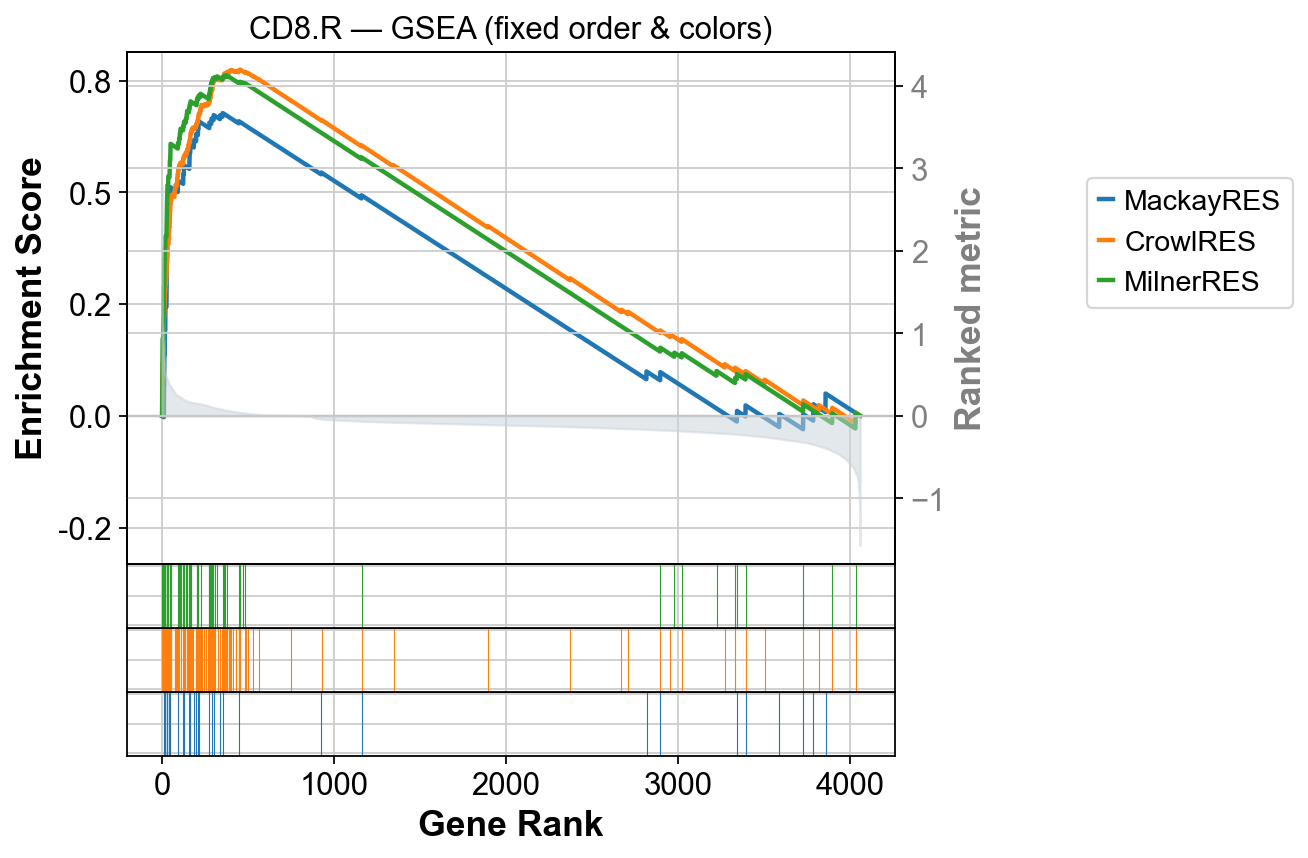

2026-07-24 15:34:38,482 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-07-24 15:34:38,483 [INFO] Parsing data files for GSEA.............................
2026-07-24 15:34:38,487 [INFO] 0000 gene_sets have been filtered out when max_size=10000 and min_size=5
2026-07-24 15:34:38,488 [INFO] 0003 gene_sets used for further statistical testing.....
2026-07-24 15:34:38,488 [INFO] Start to run GSEA...Might take a while..................
2026-07-24 15:34:38,617 [INFO] Congratulations. GSEApy runs successfully................



Running GSEA for CD8.S...


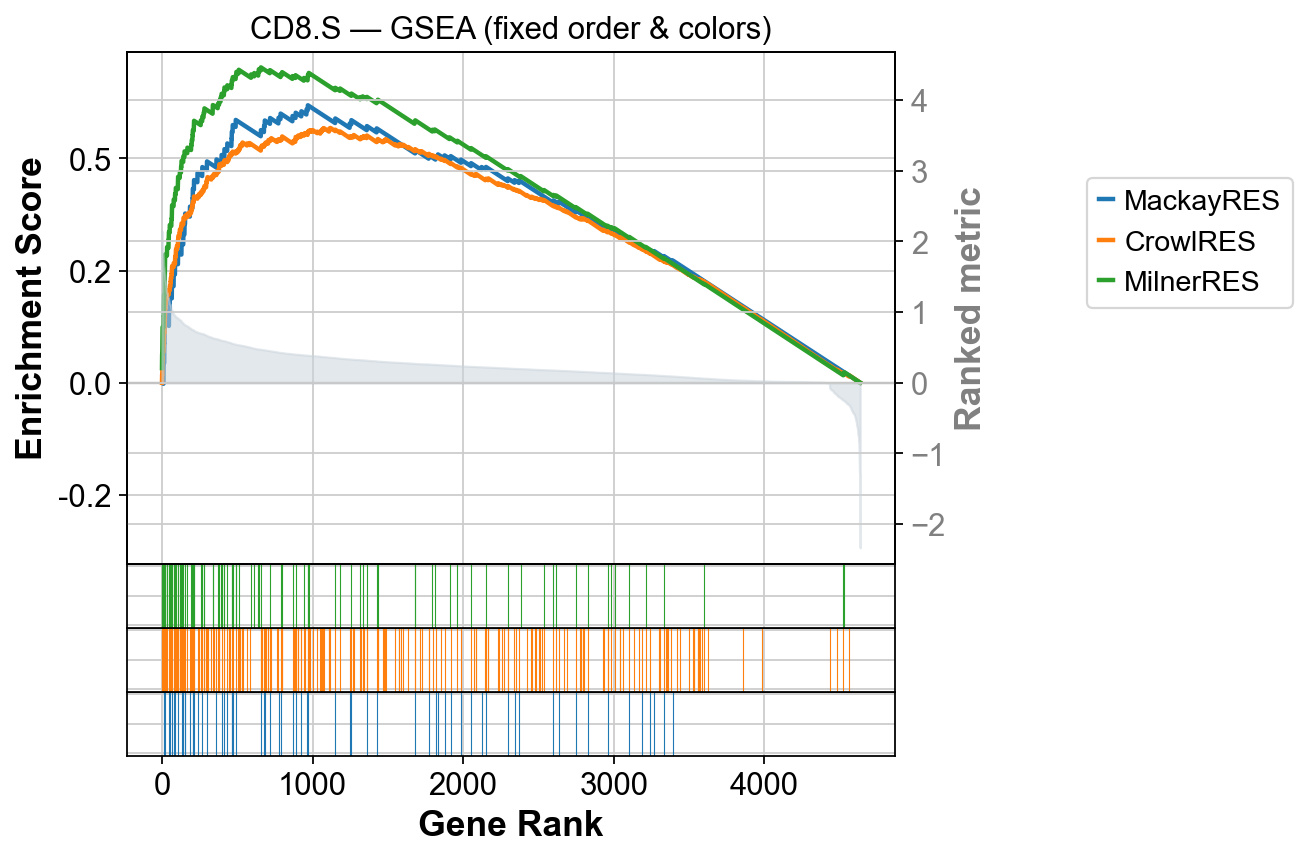

      Name       Term        ES       NES NOM p-val FDR q-val FWER p-val  \
0  prerank   CrowlRES  0.774911  4.334101       0.0       0.0        0.0   
1  prerank  MilnerRES  0.762098  3.563551       0.0       0.0        0.0   
2  prerank  MackayRES  0.677587  2.738274       0.0       0.0        0.0   
3  prerank  MilnerRES  0.702732  2.102918       0.0       0.0        0.0   
4  prerank  MackayRES  0.618301  1.791512       0.0       0.0        0.0   
5  prerank   CrowlRES  0.567716  1.759858       0.0       0.0        0.0   

     Tag %  Gene %                                         Lead_genes Cluster  \
0  108/132  11.21%  GZMK;RGS1;CCL4;ISG15;TIGIT;FASL;PDCD1;NR4A2;BH...   CD8.R   
1    51/66   9.29%  RGS1;GZMB;CCL4;TIGIT;FASL;PDCD1;NR4A2;BHLHE40;...   CD8.R   
2    25/36   8.72%  CXCR6;NR4A2;ISG20;TNFAIP3;DUSP1;LITAF;GLRX;JUN...   CD8.R   
3   59/100  14.19%  GZMB;TNFRSF9;TIGIT;RGS1;NR4A2;BHLHE40;CCL4;LIT...   CD8.S   
4    39/68  20.91%  NR4A2;CXCR6;LITAF;ITGAE;XCL1;JUNB;TNFAIP3;

In [85]:
# Extended Data Fig. 5h,i - GSEA
all_results = []

# ====================== FIXED SETTINGS ======================
desired_order = ['MackayRES', 'CrowlRES', 'MilnerRES']

signature_colors = {
    'MackayRES': '#1f77b4',   # blue
    'CrowlRES':  '#ff7f0e',   # orange
    'MilnerRES': '#2ca02c',   # green
}
# ===========================================================

for cluster in ['CD8.R', 'CD8.S']:
    print(f"Running GSEA for {cluster}...")   # helpful feedback
    
    pre_res = gp.prerank(
        rnk=f"gsea_preranks/{cluster}.rnk",
        gene_sets=signatures,
        threads=4,
        min_size=5,
        max_size=10000,
        permutation_num=1000,
        outdir=None,
        seed=6,
        verbose=True,
    )
    
    # === Get results for saving ===
    res_df = pre_res.res2d.copy()
    
    # Add cluster info and save all results (this was missing)
    res_df['Cluster'] = cluster
    all_results.append(res_df)          # <-- important
    
    # === Fixed order + colors for plotting ===
    res_df['order'] = res_df['Term'].apply(
        lambda x: next((i for i, sig in enumerate(desired_order) if sig in x), 999)
    )
    
    res_df = res_df.sort_values(by=['order', 'NES'], ascending=[True, False])
    
    plot_terms = res_df['Term'].head(len(desired_order)).tolist()
    
    plot_colors = []
    for t in plot_terms:
        assigned = False
        for sig, col in signature_colors.items():
            if sig in t:
                plot_colors.append(col)
                assigned = True
                break
        if not assigned:
            plot_colors.append('#7f7f7f')
    
    # Plot
    axs = pre_res.plot(
        terms=plot_terms,
        colors=plot_colors,
        legend_kws={'loc': (1.25, 0.5)},
        show_ranking=True,
        figsize=(4, 4.5),
    )
    
    plt.title(f'{cluster} — GSEA (fixed order & colors)')
    
    output_dir = os.path.join('gsea_figures', cluster)
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, f'Extended_Data_Fig_5h-i_{cluster}.pdf'),
                dpi=300, bbox_inches='tight')
    plt.show()   # uncomment if you want to see it live

# ====================== SAVE ALL RESULTS ======================
if all_results:
    results_df = pd.concat(all_results, ignore_index=True)
    results_df.to_csv('Extended_Data_Fig_5h-i_results.csv', index=False)
    print(results_df)
else:
    print("No results were collected!")

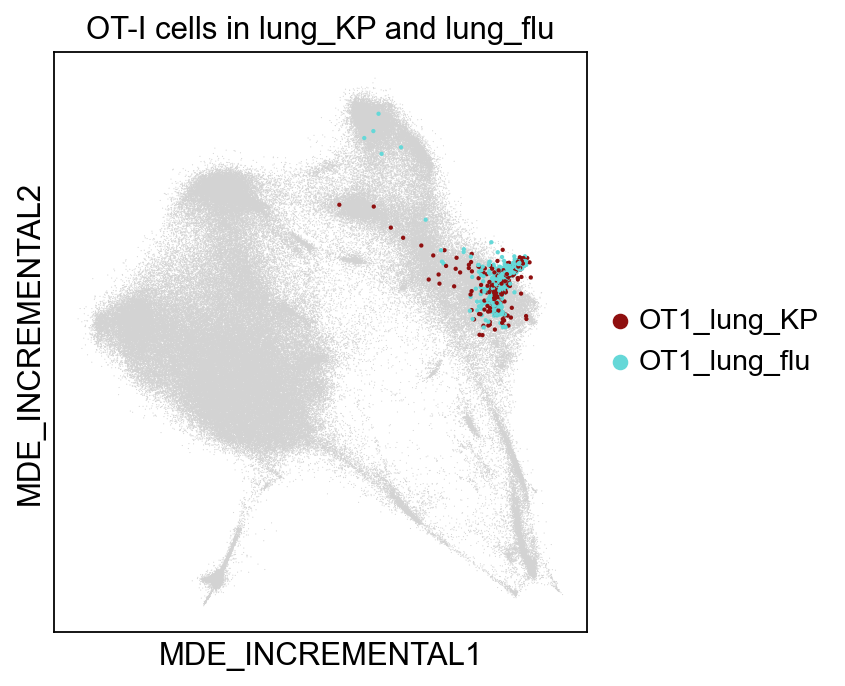

Plot saved: Extended_Data_Fig_5j.pdf


In [86]:
# Extended Data Fig. 5j - MDE plot
import scanpy as sc
import matplotlib.pyplot as plt

# Colors for OT-I groups (lung KP vs lung flu comparison)
color_palette = {
    'OT1_lung_KP':   "#8f0f0f",  # Deep red
    'OT1_lung_flu':  "#65d8d8",  # Cyan
}

# Create a temporary column in the subset for plotting purposes
subset = rna[
    (rna.obs['Ag_spe_v1'] == 'OT1') & (rna.obs['cluster_annotation'] == 'CD8.Q') &
    (
        (rna.obs['condition_detailed_organ'] == 'lung_KP') |
        (rna.obs['condition_detailed_organ'] == 'lung_flu')
    )
].copy()

# Add a new column that distinguishes the two conditions
subset.obs['OT1_group'] = subset.obs['condition_detailed_organ'].map({
    'lung_KP':  'OT1_lung_KP',
    'lung_flu': 'OT1_lung_flu'
}).astype('category')

# Create figure
fig, ax = plt.subplots(figsize=(5.5, 4.5))

# 1. Plot all cells in gray as background
sc.pl.embedding(
    rna,
    basis='MDE_INCREMENTAL',
    color='condition_broad',
    palette=['#d3d3d3'],   # light gray
    size=1,
    show=False,
    ax=ax,
    legend_loc=None
)

# 2. Overlay the two OT-I populations with different colors
sc.pl.embedding(
    subset,
    basis='MDE_INCREMENTAL',
    color='OT1_group',
    palette=color_palette,
    groups=['OT1_lung_KP', 'OT1_lung_flu'],  # ensures order and legend
    size=15,                                 # make highlighted cells stand out
    title='OT-I cells in lung_KP and lung_flu',
    legend_loc='right margin',
    show=False,
    ax=ax
)

# Finalize and save
plt.tight_layout()
plt.savefig("Extended_Data_Fig_5j.pdf", bbox_inches="tight")
plt.show()
plt.close()

print("Plot saved: Extended_Data_Fig_5j.pdf")


In [87]:
# Extended Data Fig. 5k - Volcano plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text
import scanpy as sc

# === CONFIGURATION ===
color_kp_higher   = "#8f0f0f"   # Deep red
color_flu_higher  = "#65d8d8"   # Cyan
save_path = 'Extended_Data_Fig_5k.pdf'

# Thresholds
pval_threshold = 0.05
log2fc_threshold = 0.5
label_top_n = 5  # ← now fully respected

# Genes you always want labeled
extra_label_genes = []

# =====================
# Differential expression
subset_for_de = rna[
    (rna.obs['Ag_spe_v1'] == 'OT1') &
    (rna.obs['cluster_annotation'] == 'CD8.Q') &
    (rna.obs['condition_detailed_organ'].isin(['lung_KP', 'lung_flu']))
].copy()

subset_for_de.obs['de_group'] = subset_for_de.obs['condition_detailed_organ'].map({
    'lung_KP': 'KP',
    'lung_flu': 'Flu'
}).astype('category')

sc.tl.rank_genes_groups(
    subset_for_de,
    groupby='de_group',
    method='wilcoxon',
    key_added='de_KP_vs_Flu'
)

de_results = sc.get.rank_genes_groups_df(subset_for_de, group='KP', key='de_KP_vs_Flu')
de_results = de_results[['names', 'logfoldchanges', 'pvals_adj']].copy()
de_results = de_results.rename(columns={
    'names': 'gene',
    'logfoldchanges': 'log2FC',
    'pvals_adj': 'padj'
})

# Prepare plotting df
plot_df = de_results.copy()
plot_df['minus_log10_padj'] = -np.log10(plot_df['padj'].clip(lower=1e-300))
plot_df['significant'] = (plot_df['padj'] < pval_threshold) & (abs(plot_df['log2FC']) > log2fc_threshold)

# Top significant genes (strictly label_top_n per side)
sig = plot_df[plot_df['significant']]
kp_higher  = sig[sig['log2FC'] > 0].sort_values('log2FC', ascending=False).head(label_top_n)
flu_higher = sig[sig['log2FC'] < 0].sort_values('log2FC', ascending=True).head(label_top_n)
top_genes  = pd.concat([kp_higher, flu_higher])

# Extra genes (only if not already in top_genes)
extra_df = plot_df[plot_df['gene'].isin(extra_label_genes)]
extra_to_label = extra_df[~extra_df['gene'].isin(top_genes['gene'])]

# Genes that will actually get labeled
genes_to_label = pd.concat([top_genes, extra_to_label]).drop_duplicates('gene')

# === Plot ===
fig, ax = plt.subplots(figsize=(5, 5))

# Non-significant
ax.scatter(plot_df[~plot_df['significant']]['log2FC'],
           plot_df[~plot_df['significant']]['minus_log10_padj'],
           color='grey', s=1, alpha=0.6, rasterized=True)

# Significant points
ax.scatter(plot_df[(plot_df['significant']) & (plot_df['log2FC'] > 0)]['log2FC'],
           plot_df[(plot_df['significant']) & (plot_df['log2FC'] > 0)]['minus_log10_padj'],
           color=color_kp_higher, s=6, alpha=1, label='Higher in KP', rasterized=True)

ax.scatter(plot_df[(plot_df['significant']) & (plot_df['log2FC'] < 0)]['log2FC'],
           plot_df[(plot_df['significant']) & (plot_df['log2FC'] < 0)]['minus_log10_padj'],
           color=color_flu_higher, s=6, alpha=1, label='Higher in Flu', rasterized=True)

# === Formatting ===
ax.set_xlabel('Log2 Fold Change (OT-I KP vs OT-I Flu)')
ax.set_ylabel('-Log10 (Adjusted P-value)')
ax.set_title('OT-I CD8.Q: lung_KP vs lung_flu', pad=15)
ax.set_xlim(-10, 10)
ax.axvline(log2fc_threshold, color='black', linestyle='--', lw=0.5, alpha=0.7)
ax.axvline(-log2fc_threshold, color='black', linestyle='--', lw=0.5, alpha=0.7)
ax.axhline(-np.log10(pval_threshold), color='black', linestyle='--', lw=0.5, alpha=0.7)
ax.grid(False)
ax.legend(loc='upper left', fontsize=7, frameon=False)

plt.tight_layout()
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.close()

print(f"Volcano plot saved: {save_path}")


Volcano plot saved: Extended_Data_Fig_5k.pdf


# Extended Data Fig. 7

In [88]:
# Extended Data Fig. 7c - RNA/ADT correlation analysis
# Keep only cells where cite_seq is True
keep = mdata['RNA'].obs['cite_seq'] == True

mdata = mdata[keep].copy()   # recommended to add .copy()

print(f"Remaining cells after filtering: {mdata.n_obs} (was 206160)")

rna = mdata['RNA']
adt = mdata['ADT']

print(f"RNA: {rna.n_obs} cells | ADT: {adt.n_obs} cells")

Remaining cells after filtering: 160812 (was 206160)
RNA: 160812 cells | ADT: 160812 cells


In [89]:
# Extended Data Fig. 7c - RNA/ADT correlation analysis
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from adjustText import adjust_text
from matplotlib.lines import Line2D

marker_pairs = {
    'Sell': 'CD62L', 'Cd44': 'CD44', 'Il7r': 'IL7RA.CD127', 'Klrg1': 'KLRG1',
    'Itgax': 'ITAX.CD11C', 'Cd69': 'CD69', 'Itgae': 'CD103', 'Itga1': 'CD49A',
    'Entpd1': 'CD39', 'Slamf6': 'LY108', 'Pdcd1': 'PDCD1.PD1.CD279', 'Tnfrsf18': 'GITR.CD357',
}
group_key = 'cluster_annotation'

# ====================== MOVE LOG_NORM LAYERS TO .X ======================
rna.X = rna.layers['log_norm']
adt.X = adt.layers['log_norm']

# ====================== CLUSTER-LEVEL ANALYSIS ======================
results = []
plot_data = []
plots_dir = Path("cluster_level_correlations")
plots_dir.mkdir(exist_ok=True)

for rna_gene, adt_prot in marker_pairs.items():
    if rna_gene not in rna.var_names or adt_prot not in adt.var_names:
        continue

    rna_expr = rna[:, rna_gene].X
    if hasattr(rna_expr, 'toarray'):
        rna_expr = rna_expr.toarray().flatten()
    else:
        rna_expr = np.asarray(rna_expr).flatten()

    adt_expr = adt[:, adt_prot].X
    if hasattr(adt_expr, 'toarray'):
        adt_expr = adt_expr.toarray().flatten()
    else:
        adt_expr = np.asarray(adt_expr).flatten()

    cluster_rna = pd.DataFrame({
        'expr': rna_expr,
        'cluster': rna.obs[group_key].values
    }).groupby('cluster')['expr'].mean()

    cluster_adt = pd.DataFrame({
        'expr': adt_expr,
        'cluster': adt.obs[group_key].values
    }).groupby('cluster')['expr'].mean()

    df_cluster = pd.DataFrame({
        'rna_mean': cluster_rna,
        'adt_mean': cluster_adt
    }).dropna()

    if len(df_cluster) < 3:
        continue

    corr, pval = spearmanr(df_cluster['rna_mean'], df_cluster['adt_mean'])
    df_cluster['residual'] = df_cluster['rna_mean'] - df_cluster['adt_mean']
    df_cluster['abs_residual'] = df_cluster['residual'].abs()

    n_top = min(5, len(df_cluster))
    top_divergent = df_cluster.nlargest(n_top, 'abs_residual')

    results.append({
        'rna': rna_gene,
        'protein': adt_prot,
        'spearman': corr,
        'pval': pval,
        'n_clusters': len(df_cluster),
        'max_abs_residual': df_cluster['abs_residual'].max(),
        'mean_abs_residual': df_cluster['abs_residual'].mean(),
        'top_divergent_clusters': '; '.join(top_divergent.index.tolist()),
        'top_divergent_details': ' | '.join(
            [f"{clus}: RNA={row['rna_mean']:.3f}, ADT={row['adt_mean']:.3f}, res={row['residual']:.3f}"
             for clus, row in top_divergent.iterrows()]
        )
    })

    # Min-max scaling for plotting
    df_plot = df_cluster.copy()
    df_plot['rna_mean'] = (df_plot['rna_mean'] - df_plot['rna_mean'].min()) / (df_plot['rna_mean'].max() - df_plot['rna_mean'].min())
    df_plot['adt_mean'] = (df_plot['adt_mean'] - df_plot['adt_mean'].min()) / (df_plot['adt_mean'].max() - df_plot['adt_mean'].min())

    plot_data.append({
        'df_plot': df_plot,
        'df_cluster': df_cluster,
        'rna_gene': rna_gene,
        'adt_prot': adt_prot,
        'corr': corr,
        'pval': pval,
        'top_divergent': top_divergent,
        'notable_threshold': df_cluster['abs_residual'].quantile(0.8)
    })

    print(f"{rna_gene} vs {adt_prot} | Spearman r={corr:.3f} | Max |res|={df_cluster['abs_residual'].max():.3f}")

# ====================== COMBINED DETAILS CSV ======================
if plot_data:
    combined_details = []
    for pdata in plot_data:
        df = pdata['df_cluster'].copy().reset_index().rename(columns={'index': 'cluster'})
        df['rna'] = pdata['rna_gene']
        df['protein'] = pdata['adt_prot']
        cols = ['rna', 'protein', 'cluster', 'rna_mean', 'adt_mean', 'residual', 'abs_residual']
        combined_details.append(df[cols])
    all_details = pd.concat(combined_details, ignore_index=True)
    all_details_path = plots_dir / "Extended_Data_Fig_7c_all_cluster_details.csv"
    all_details.to_csv(all_details_path, index=False)
    print(f"\nSaved combined details CSV: {all_details_path}")

# ====================== COMBINED GRID PDF ======================
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # Cleaner PDF output

n_plots = len(plot_data)
if n_plots > 0:
    ncols = 4
    nrows = int(np.ceil(n_plots / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.51 * ncols, 5 * nrows), squeeze=False)
    axes = axes.flatten()
    fig.patch.set_facecolor('white')

    for i, pdata in enumerate(plot_data):
        ax = axes[i]
        ax.set_facecolor('white')

        # Grid FIRST + behind points
        ax.grid(True, alpha=0.25, color='gray', linestyle='-', linewidth=0.5)
        ax.set_axisbelow(True)

        df_plot = pdata['df_plot']
        df_cluster = pdata['df_cluster']

        # Use raw scatter instead of seaborn for cleaner PDF
        colors = [custom_colors.get(name, 'C0') for name in df_plot.index]
        scatter = ax.scatter(
            df_plot['rna_mean'], df_plot['adt_mean'],
            s=75, c=colors, edgecolors='black', linewidths=0.25,
            clip_on=False   # prevents extra clipping masks
        )

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.5, alpha=1)

        # === Label top 3 highest + bottom 3 lowest ===
        if len(df_plot) >= 3:
            combined = df_plot['rna_mean'] + df_plot['adt_mean']
            top3 = combined.nlargest(3).index.tolist()
            bottom3 = combined.nsmallest(3).index.tolist()
            to_label = list(set(top3 + bottom3))

            texts = []
            for clus in to_label:
                row = df_plot.loc[clus]
                texts.append(ax.text(
                    row['rna_mean'] * 1.015, row['adt_mean'], str(clus),
                    fontsize=8, alpha=1
                ))
            if texts:
                adjust_text(
                    texts, ax=ax,
                    arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
                )

        title = (f"{pdata['rna_gene']} vs {pdata['adt_prot']}\n"
                 f"r = {pdata['corr']:.3f} (p={pdata['pval']:.1e})")
        ax.set_title(title, fontsize=12, pad=4)
        ax.set_xlabel(f"Mean {pdata['rna_gene']} (min-max scaled)", fontsize=10)
        ax.set_ylabel(f"Mean {pdata['adt_prot']} (min-max scaled)", fontsize=10)
        ax.tick_params(axis='both', labelsize=8)

    # Hide unused axes + legend (unchanged)
    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)

    all_clusters = set()
    for pdata in plot_data:
        all_clusters.update(pdata['df_plot'].index.tolist())
    cluster_order = [c for c in custom_colors if c in all_clusters]
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=c,
               markerfacecolor=custom_colors[c], markersize=7,
               markeredgecolor='black', markeredgewidth=0.4)
        for c in cluster_order
    ]
    fig.legend(
        handles=legend_elements, title='Cluster',
        bbox_to_anchor=(0.9, 0.5), loc='center left',
        fontsize=8, title_fontsize=12, frameon=True
    )

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    grid_pdf_path = plots_dir / "Extended_Data_Fig_7c.pdf"
    fig.savefig(grid_pdf_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Saved combined grid PDF: {grid_pdf_path}")

# ====================== SUMMARY ======================
df = pd.DataFrame(results)
df = df.sort_values('spearman', ascending=False)
df.to_csv("cluster_level_correlations/Extended_Data_Fig_7c_cluster_level_correlations.csv", index=False)

print("\n=== CLUSTER-LEVEL RESULTS (sorted by Spearman r) ===")
print(df[['rna', 'protein', 'spearman', 'pval', 'n_clusters',
          'max_abs_residual', 'mean_abs_residual']].round(4).to_string())

print("\nOutputs ready:")
print(" • cluster_level_correlations/Extended_Data_Fig_7c_cluster_level_correlations.csv")
print(" • cluster_level_correlations/Extended_Data_Fig_7c_all_cluster_details.csv")
print(" • cluster_level_correlations/Extended_Data_Fig_7c_all_cluster_level_correlations_grid.pdf")


Sell vs CD62L | Spearman r=0.965 | Max |res|=4.172
Cd44 vs CD44 | Spearman r=0.603 | Max |res|=5.015
Il7r vs IL7RA.CD127 | Spearman r=0.879 | Max |res|=3.158
Klrg1 vs KLRG1 | Spearman r=0.839 | Max |res|=3.132
Itgax vs ITAX.CD11C | Spearman r=0.917 | Max |res|=3.343
Cd69 vs CD69 | Spearman r=0.561 | Max |res|=4.411
Itgae vs CD103 | Spearman r=0.948 | Max |res|=4.372
Itga1 vs CD49A | Spearman r=0.918 | Max |res|=3.186
Entpd1 vs CD39 | Spearman r=0.871 | Max |res|=3.780
Slamf6 vs LY108 | Spearman r=0.729 | Max |res|=2.563
Pdcd1 vs PDCD1.PD1.CD279 | Spearman r=0.877 | Max |res|=2.837
Tnfrsf18 vs GITR.CD357 | Spearman r=0.825 | Max |res|=3.012

Saved combined details CSV: cluster_level_correlations/Extended_Data_Fig_7c_all_cluster_details.csv
Saved combined grid PDF: cluster_level_correlations/Extended_Data_Fig_7c.pdf

=== CLUSTER-LEVEL RESULTS (sorted by Spearman r) ===
         rna          protein  spearman    pval  n_clusters  max_abs_residual  mean_abs_residual
0       Sell           

# Extended Data Table 2

In [91]:
# Extended Data Table 2 - CD8+ T cell counts by sample
import pandas as pd
import numpy as np
from mudata import MuData

# Load your MuData
obs = mdata["RNA"].obs.copy()

print("Available columns:", sorted(obs.columns.tolist()))

# === FIXED ANTIGEN-SPECIFIC FLAG ===
obs['is_antigen_specific'] = obs['Ag_spe_v2'] != "Endogenous"

# === FILTER TO SELECTED SAMPLES FROM CSV ===
selected_samples_path = './Fig_1e_selected_samples.csv'
selected_df = pd.read_csv(selected_samples_path)
selected_sample_codes = selected_df['sample_code'].astype(str).unique()

n_before = len(obs)
obs = obs[obs['sample_code'].isin(selected_sample_codes)].copy()
print(f"Filtered to selected samples: kept {len(obs):,} / {n_before:,} cells "
      f"({len(selected_sample_codes)} samples)")

# === CONDITION FILLING ===
if 'condition_detailed' in obs.columns:
    if pd.api.types.is_categorical_dtype(obs['condition_detailed']):
        obs['condition_detailed'] = obs['condition_detailed'].cat.add_categories('baseline')
    obs['condition_detailed'] = obs['condition_detailed'].replace('', 'baseline').fillna('baseline')

print(f"\nAntigen-specific cells (post-filter): {obs['is_antigen_specific'].sum():,}")
print(f"Percentage antigen-specific: {obs['is_antigen_specific'].mean()*100:.2f}%")

# === GROUP BY AND CREATE TABLE ===
table = (obs.groupby(['IGTHT', 'condition_detailed', 'condition_broad', 'organ'], observed=True)
         .agg(
             total_CD8=('IGT_cellID', 'count'),
             antigen_specific=('is_antigen_specific', 'sum'),
             endogenous=('is_antigen_specific', lambda x: (~x).sum())
         )
         .reset_index())

# Add percentages
table['pct_antigen_specific'] = (table['antigen_specific'] / table['total_CD8'] * 100).round(2)
table['pct_endogenous'] = (table['endogenous'] / table['total_CD8'] * 100).round(2)

# Sort
table = table.sort_values(['IGTHT', 'condition_detailed', 'condition_broad', 'organ'])

# Reorder columns
table = table[['IGTHT', 'condition_detailed', 'condition_broad', 'organ',
               'total_CD8', 'antigen_specific', 'pct_antigen_specific',
               'endogenous', 'pct_endogenous']]

# Save
table.to_csv('Extended Data Table 2.csv', index=False)
print("\nTable successfully saved as CSV!")
print(f"Total samples (IGTHT): {table['IGTHT'].nunique()}")
print(f"Total tissues: {table['organ'].nunique()}")
print(f"Total unique condition_detailed: {table['condition_detailed'].nunique()}")

print("\nPreview:")
print(table.head(15))

Available columns: ['Ag_spe_v1', 'Ag_spe_v2', 'CD44_status', 'CD5hi', 'CD5lo', 'G2M.Score', 'HT', 'IGT', 'IGTHT', 'IGT_cellID', 'MAIT', 'S.Score', 'age_weeks', 'cite_seq', 'cluster_annotation', 'comments', 'condition_broad', 'condition_detailed', 'condition_detailed_organ', 'condition_detailed_simplified', 'exp_id', 'exp_name', 'exp_number', 'gating_strategy', 'genetics', 'highlight_color', 'ht_number', 'iNKT', 'ident', 'igt_number', 'infection_agent', 'infection_dose', 'infection_mode', 'jax', 'lab', 'nCount_ADT', 'nCount_RNA', 'nFeature_ADT', 'nFeature_RNA', 'organ', 'organ_simplified', 'organ_uberon_id', 'organism_name', 'pool_of_mice', 'prep_description', 'sample_code', 'sample_name', 'sample_type', 'sex', 'strain', 'target_cells', 'target_cells_simplified', 'timepoint', 'transgenic_byTCR', 'transgenic_tet_byCITEseq', 'transgenic_tet_bySorting', 'treat_agent', 'treat_dose', 'tumor']
Filtered to selected samples: kept 157,188 / 160,812 cells (558 samples)

Antigen-specific cells (po